In [1]:
# ============================================================
# 07 / Cell 1
# New-city intake setup: folders + manifest template
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# locate project root
# ------------------------------------------------------------
project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
output_dir.mkdir(parents=True, exist_ok=True)

intake_root = project_root / "city_intake"
intake_root.mkdir(parents=True, exist_ok=True)

target_cities = [
    {"city": "Miami", "slug": "miami"},
    {"city": "Las Vegas", "slug": "las_vegas"},
]

# ------------------------------------------------------------
# create standard folders
# ------------------------------------------------------------
for cfg in target_cities:
    slug = cfg["slug"]
    for sub in ["raw", "working", "final"]:
        (intake_root / slug / sub).mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# build manifest template
# ------------------------------------------------------------
rows = []
for cfg in target_cities:
    city = cfg["city"]
    slug = cfg["slug"]

    rows.append({
        "city": city,
        "slug": slug,
        "is_active": False,

        # preferred fast path:
        # a merged tract-level gpkg already containing geometry + GEOID + LST + HI + population
        "merged_candidate_gpkg": "",

        # fallback component path:
        "boundary_file": "",
        "tract_geometry_file": "",
        "lst_table_file": "",
        "hi_table_file": "",
        "population_file": "",

        # source columns (fill when known)
        "geoid_col": "GEOID",
        "lst_col_source": "",
        "hi_col_source": "",
        "pop_col_source": "",

        # standard targets
        "target_output_gpkg": str(project_root / "data_processed" / slug / f"{slug}_master_with_lst_hi_fixed.gpkg"),
        "target_boundary_file": str(project_root / "outputs" / "pilot" / "heat_ready" / slug / f"{slug}_boundary_heat_ready.geojson"),

        "notes": "Fill paths first. Preferred: provide merged_candidate_gpkg. Otherwise provide boundary + tract geometry + LST table + HI table (+ population if needed)."
    })

manifest_df = pd.DataFrame(rows)

display(manifest_df)

manifest_out = output_dir / "rq1_new_city_manifest_template.csv"
manifest_df.to_csv(manifest_out, index=False)

readme_text = """# New-city intake workflow

This folder is used to onboard new cities into the RQ1 LST vs Heat Index pipeline.

Recommended fast path:
1. Prepare one merged tract-level GPKG for each new city.
2. The file should contain:
   - geometry
   - GEOID
   - tract-level LST column
   - tract-level HI column
   - population column (preferred)

Fallback path:
- boundary_file
- tract_geometry_file
- lst_table_file
- hi_table_file
- population_file

Current target cities:
- Miami
- Las Vegas
"""

readme_out = intake_root / "README_new_city_intake.md"
readme_out.write_text(readme_text, encoding="utf-8")

print("\nSaved:")
print(manifest_out, "->", manifest_out.exists())
print(readme_out, "->", readme_out.exists())

print("\nCreated folders:")
for cfg in target_cities:
    slug = cfg["slug"]
    print(intake_root / slug / "raw")
    print(intake_root / slug / "working")
    print(intake_root / slug / "final")

,city,slug,is_active,merged_candidate_gpkg,boundary_file,tract_geometry_file,lst_table_file,hi_table_file,population_file,geoid_col,lst_col_source,hi_col_source,pop_col_source,target_output_gpkg,target_boundary_file,notes
0,Miami,miami,False,,,,,,,GEOID,,,,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,Fill paths first. Preferred: provide merged_ca...
1,Las Vegas,las_vegas,False,,,,,,,GEOID,,,,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,Fill paths first. Preferred: provide merged_ca...



Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_new_city_manifest_template.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/README_new_city_intake.md -> True

Created folders:
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/miami/raw
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/miami/working
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/miami/final
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/raw
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final


In [2]:
# ============================================================
# 07 / Cell 2
# Validate new-city manifest and file readiness
# ============================================================

from pathlib import Path
import pandas as pd

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"
manifest_path = output_dir / "rq1_new_city_manifest_template.csv"

manifest_df = pd.read_csv(manifest_path, keep_default_na=False)

path_cols = [
    "merged_candidate_gpkg",
    "boundary_file",
    "tract_geometry_file",
    "lst_table_file",
    "hi_table_file",
    "population_file",
]

qc_rows = []

for _, row in manifest_df.iterrows():
    city = row["city"]

    exists_map = {}
    for c in path_cols:
        v = str(row[c]).strip()
        exists_map[c + "_exists"] = (v != "" and Path(v).exists())

    merged_ready = exists_map["merged_candidate_gpkg_exists"]

    component_ready = (
        exists_map["boundary_file_exists"] and
        exists_map["tract_geometry_file_exists"] and
        exists_map["lst_table_file_exists"] and
        exists_map["hi_table_file_exists"]
    )

    if merged_ready:
        readiness = "ready_via_merged_gpkg"
        next_step = "Activate city and standardize columns"
    elif component_ready:
        readiness = "ready_via_components"
        next_step = "Merge components into standard city gpkg"
    else:
        readiness = "missing_inputs"
        missing_list = []
        for c in path_cols:
            v = str(row[c]).strip()
            if c == "population_file":
                # optional in some cases
                continue
            if v == "":
                missing_list.append(c)
            elif not Path(v).exists():
                missing_list.append(c + " (path invalid)")
        next_step = "Missing: " + ", ".join(missing_list) if missing_list else "Need more inputs"

    qc_rows.append({
        "city": city,
        "slug": row["slug"],
        "is_active": row["is_active"],
        "readiness": readiness,
        "next_step": next_step,
        **exists_map
    })

qc_df = pd.DataFrame(qc_rows)

display(qc_df)

qc_out = output_dir / "rq1_new_city_manifest_qc.csv"
qc_df.to_csv(qc_out, index=False)

print("\nSaved:", qc_out)
print(qc_out.exists())

,city,slug,is_active,readiness,next_step,merged_candidate_gpkg_exists,boundary_file_exists,tract_geometry_file_exists,lst_table_file_exists,hi_table_file_exists,population_file_exists
0,Miami,miami,False,missing_inputs,"Missing: merged_candidate_gpkg, boundary_file,...",False,False,False,False,False,False
1,Las Vegas,las_vegas,False,missing_inputs,"Missing: merged_candidate_gpkg, boundary_file,...",False,False,False,False,False,False



Saved: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_new_city_manifest_qc.csv
True


In [3]:
# ============================================================
# 07 / Cell 3
# Export target schema reference from ready cities
# ============================================================

from pathlib import Path
import pandas as pd
import geopandas as gpd

project_root = Path.cwd()
if not (project_root / "data_processed").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs" / "pilot"

registry_template = pd.read_csv(output_dir / "rq1_city_registry_template.csv")
ready_df = registry_template.loc[registry_template["status"] == "ready"].copy()

schema_rows = []

for _, row in ready_df.iterrows():
    city = row["city"]
    gpkg_path = Path(row["main_gpkg"])

    gdf = gpd.read_file(gpkg_path)

    for col in gdf.columns:
        dtype_str = str(gdf[col].dtype) if col != "geometry" else "geometry"
        schema_rows.append({
            "city": city,
            "column_name": col,
            "dtype": dtype_str,
            "is_required_core": col in ["GEOID", "lst_c", "hi_c", "total_population", "geometry"]
        })

schema_df = pd.DataFrame(schema_rows)

display(schema_df.head(30))

schema_out = output_dir / "rq1_target_schema_reference_long.csv"
schema_df.to_csv(schema_out, index=False)

# core schema summary
core_cols = ["GEOID", "lst_c", "hi_c", "total_population", "geometry"]
core_summary = []

for col in core_cols:
    sub = schema_df.loc[schema_df["column_name"] == col].copy()
    core_summary.append({
        "column_name": col,
        "present_in_ready_cities_n": len(sub),
        "cities": ", ".join(sorted(sub["city"].unique())) if len(sub) > 0 else "",
        "target_role": {
            "GEOID": "tract join key",
            "lst_c": "tract-level summer LST in Celsius",
            "hi_c": "tract-level summer Heat Index in Celsius",
            "total_population": "tract population for weighted summaries",
            "geometry": "tract polygon geometry"
        }[col]
    })

core_summary_df = pd.DataFrame(core_summary)

display(core_summary_df)

core_summary_out = output_dir / "rq1_target_schema_core.csv"
core_summary_df.to_csv(core_summary_out, index=False)

note_text = """# RQ1 new-city onboarding note

Current batch-ready cities:
- Houston
- Phoenix

Core target schema for any new city:
- GEOID
- lst_c
- hi_c
- total_population
- geometry

Recommended onboarding rule:
Prepare one merged tract-level GPKG per city that already contains the core target schema above. This is the most stable and scalable path for the multicity workflow.
"""

note_out = output_dir / "rq1_new_city_onboarding_note.md"
note_out.write_text(note_text, encoding="utf-8")

print("\nSaved:")
print(schema_out, "->", schema_out.exists())
print(core_summary_out, "->", core_summary_out.exists())
print(note_out, "->", note_out.exists())

,city,column_name,dtype,is_required_core
0,Houston,STATEFP,object,False
1,Houston,COUNTYFP,object,False
2,Houston,TRACTCE,object,False
3,Houston,GEOID,object,True
4,Houston,NAME,object,False
5,Houston,NAMELSAD,object,False
6,Houston,ALAND,int64,False
7,Houston,AWATER,int64,False
8,Houston,area_km2,float64,False
9,Houston,city,object,False


,column_name,present_in_ready_cities_n,cities,target_role
0,GEOID,2,"Houston, Phoenix",tract join key
1,lst_c,2,"Houston, Phoenix",tract-level summer LST in Celsius
2,hi_c,2,"Houston, Phoenix",tract-level summer Heat Index in Celsius
3,total_population,2,"Houston, Phoenix",tract population for weighted summaries
4,geometry,2,"Houston, Phoenix",tract polygon geometry



Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_target_schema_reference_long.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_target_schema_core.csv -> True
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/rq1_new_city_onboarding_note.md -> True


In [1]:
from pathlib import Path
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

REPO = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

CITY = "las_vegas"
STATE_ABBR = "NV"
STATE_FIPS = "32"
COUNTY_HINT = "Clark"

RAW_DIR = REPO / "city_intake" / CITY / "raw"
WORK_DIR = REPO / "city_intake" / CITY / "working"
FINAL_DIR = REPO / "city_intake" / CITY / "final"

PROC_DIR = REPO / "data_processed" / CITY
OUT_DIR = REPO / "outputs" / "pilot" / "alphaearth"

TRACT_SHP = RAW_DIR / "tract_2025" / "tl_2025_32_tract.shp"

WORK_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo:", REPO)
print("City:", CITY)
print("TRACT_SHP exists:", TRACT_SHP.exists())
print("TRACT_SHP:", TRACT_SHP)

Repo: /Users/yufeizhou/Desktop/heat-exposure-compare
City: las_vegas
TRACT_SHP exists: True
TRACT_SHP: /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/raw/tract_2025/tl_2025_32_tract.shp


In [2]:
assert TRACT_SHP.exists(), f"Missing shapefile: {TRACT_SHP}"

gdf = gpd.read_file(TRACT_SHP).copy()

print("Rows:", len(gdf))
print("CRS:", gdf.crs)
print("Columns:")
print(list(gdf.columns))

preview_cols = [c for c in ["STATEFP", "COUNTYFP", "TRACTCE", "GEOID", "NAME", "NAMELSAD"] if c in gdf.columns]
display(gdf[preview_cols].head())

Rows: 779
CRS: EPSG:4269
Columns:
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD
0,32,003,002954,32003002954,29.54,Census Tract 29.54
1,32,003,004709,32003004709,47.09,Census Tract 47.09
2,32,003,002915,32003002915,29.15,Census Tract 29.15
3,32,003,002916,32003002916,29.16,Census Tract 29.16
4,32,003,002919,32003002919,29.19,Census Tract 29.19


In [3]:
def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

gdf = gdf.copy()

state_col = first_existing(gdf, ["STATEFP"])
county_col = first_existing(gdf, ["COUNTYFP"])
tract_col = first_existing(gdf, ["TRACTCE"])
geoid_col = first_existing(gdf, ["GEOID", "geoid"])

if geoid_col is not None:
    gdf["GEOID"] = gdf[geoid_col].astype(str).str.strip()
elif state_col and county_col and tract_col:
    gdf["GEOID"] = (
        gdf[state_col].astype(str).str.zfill(2)
        + gdf[county_col].astype(str).str.zfill(3)
        + gdf[tract_col].astype(str).str.zfill(6)
    )
else:
    raise ValueError("Cannot create GEOID. Need GEOID or STATEFP+COUNTYFP+TRACTCE.")

gdf["GEOID"] = gdf["GEOID"].astype(str).str.replace(".0", "", regex=False).str.strip()

if gdf["GEOID"].duplicated().any():
    dup_n = int(gdf["GEOID"].duplicated().sum())
    print(f"Warning: duplicated GEOID count = {dup_n}")
else:
    print("No duplicated GEOID.")

if gdf.crs is None:
    raise ValueError("Input shapefile has no CRS. Need CRS before continuing.")

# 经纬度版本 (geographic version)
gdf_ll = gdf.to_crs(4326).copy()

# 自动估计本地 UTM，用于面积和后续空间分析
utm_crs = gdf_ll.estimate_utm_crs()
print("Estimated UTM CRS:", utm_crs)

gdf_proj = gdf_ll.to_crs(utm_crs).copy()
gdf_proj["area_km2"] = gdf_proj.geometry.area / 1_000_000

# 常用字段整理
keep_priority = [
    "GEOID", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD",
    "area_km2", "geometry"
]
existing_keep = [c for c in keep_priority if c in gdf_proj.columns]
other_cols = [c for c in gdf_proj.columns if c not in existing_keep]
gdf_proj = gdf_proj[existing_keep + other_cols]

# 输出路径
gpkg_path = PROC_DIR / f"{CITY}_tracts_projected.gpkg"
geojson_path = PROC_DIR / f"{CITY}_tracts_clean.geojson"
csv_path = FINAL_DIR / f"{CITY}_tract_inventory.csv"

# 保存
gdf_proj.to_file(gpkg_path, driver="GPKG")
gdf_ll.to_file(geojson_path, driver="GeoJSON")

inventory_df = pd.DataFrame({
    "column_name": gdf_proj.columns,
    "dtype": [str(gdf_proj[c].dtype) if c != "geometry" else "geometry" for c in gdf_proj.columns],
    "non_null_n": [int(gdf_proj[c].notna().sum()) for c in gdf_proj.columns],
    "missing_n": [int(gdf_proj[c].isna().sum()) for c in gdf_proj.columns],
})
inventory_df.to_csv(csv_path, index=False)

print("Saved:")
print(gpkg_path)
print(geojson_path)
print(csv_path)

display(gdf_proj[["GEOID", "area_km2"]].head())

No duplicated GEOID.
Estimated UTM CRS: EPSG:32611
Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_clean.geojson
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_tract_inventory.csv


,GEOID,area_km2
0,32003002954,0.959868
1,32003004709,1.301052
2,32003002915,2.740170
3,32003002916,2.775261
4,32003002919,2.645347


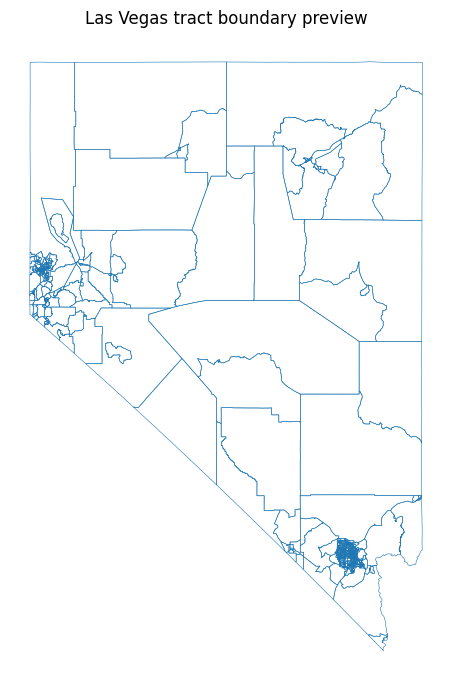

Saved:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_summary.csv
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_boundary_preview.png
/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/README_intake_status.md


,city,state_abbr,state_fips,county_hint,n_tracts,crs_input,crs_projected,geoid_unique_n,area_km2_total,area_km2_mean,ready_boundary_input,has_heat_master_table,has_alphaearth_embedding,has_pc_scores,next_step
0,las_vegas,NV,32,Clark,779,EPSG:4269,EPSG:32611,779,286296.259034,367.517662,True,False,False,False,Need tract-level heat table and tract-level Al...



README preview:

# Las Vegas intake status

## Current status
- City: las_vegas
- State: NV (32)
- County hint: Clark
- Tract shapefile loaded successfully
- Number of tracts: 779
- GEOID unique count: 779
- Projected CRS: EPSG:32611

## Files created
- Projected tract file: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
- Clean GeoJSON: /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_clean.geojson
- Column inventory: /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_tract_inventory.csv
- Tract summary: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_summary.csv
- Boundary preview: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_boundary_preview.png

## Interpretation
This step confirms that Las Vegas tract boundary input is ready.
The city is NOT yet ready for the full Alpha

In [4]:
png_path = OUT_DIR / f"{CITY}_tract_boundary_preview.png"
summary_csv = OUT_DIR / f"{CITY}_tract_summary.csv"
readme_md = FINAL_DIR / "README_intake_status.md"

# summary table
summary_df = pd.DataFrame([{
    "city": CITY,
    "state_abbr": STATE_ABBR,
    "state_fips": STATE_FIPS,
    "county_hint": COUNTY_HINT,
    "n_tracts": int(len(gdf_proj)),
    "crs_input": str(gdf.crs),
    "crs_projected": str(utm_crs),
    "geoid_unique_n": int(gdf_proj["GEOID"].nunique()),
    "area_km2_total": float(gdf_proj["area_km2"].sum()),
    "area_km2_mean": float(gdf_proj["area_km2"].mean()),
    "ready_boundary_input": True,
    "has_heat_master_table": False,
    "has_alphaearth_embedding": False,
    "has_pc_scores": False,
    "next_step": "Need tract-level heat table and tract-level AlphaEarth embedding for full workflow."
}])
summary_df.to_csv(summary_csv, index=False)

# preview map
fig, ax = plt.subplots(figsize=(7, 7))
gdf_ll.boundary.plot(ax=ax, linewidth=0.4)
ax.set_title("Las Vegas tract boundary preview")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(png_path, dpi=200, bbox_inches="tight")
plt.show()

# readme
readme_text = f"""# Las Vegas intake status

## Current status
- City: {CITY}
- State: {STATE_ABBR} ({STATE_FIPS})
- County hint: {COUNTY_HINT}
- Tract shapefile loaded successfully
- Number of tracts: {len(gdf_proj)}
- GEOID unique count: {gdf_proj["GEOID"].nunique()}
- Projected CRS: {utm_crs}

## Files created
- Projected tract file: {gpkg_path}
- Clean GeoJSON: {geojson_path}
- Column inventory: {csv_path}
- Tract summary: {summary_csv}
- Boundary preview: {png_path}

## Interpretation
This step confirms that Las Vegas tract boundary input is ready.
The city is NOT yet ready for the full AlphaEarth workflow because the following are still missing:
1. tract-level heat master table
2. tract-level AlphaEarth embedding
3. PC scores (can be recomputed later after the first two are available)

## Next step
Collect or create:
- heat master table with GEOID
- AlphaEarth embedding table with GEOID
Then merge and continue the same workflow used for Houston and Phoenix.
"""
readme_md.write_text(readme_text, encoding="utf-8")

print("Saved:")
print(summary_csv)
print(png_path)
print(readme_md)

display(summary_df)
print("\nREADME preview:\n")
print(readme_text)

REPO_ROOT = /Users/yufeizhou/Desktop/heat-exposure-compare

All gpkg files in city folder:
  score=16 | las_vegas_tracts_projected.gpkg

Using TRACT_GPKG:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
Exists: True

Rows: 779
CRS: EPSG:32611
Normalized GEOID unique: 779
Duplicated GEOID count: 0


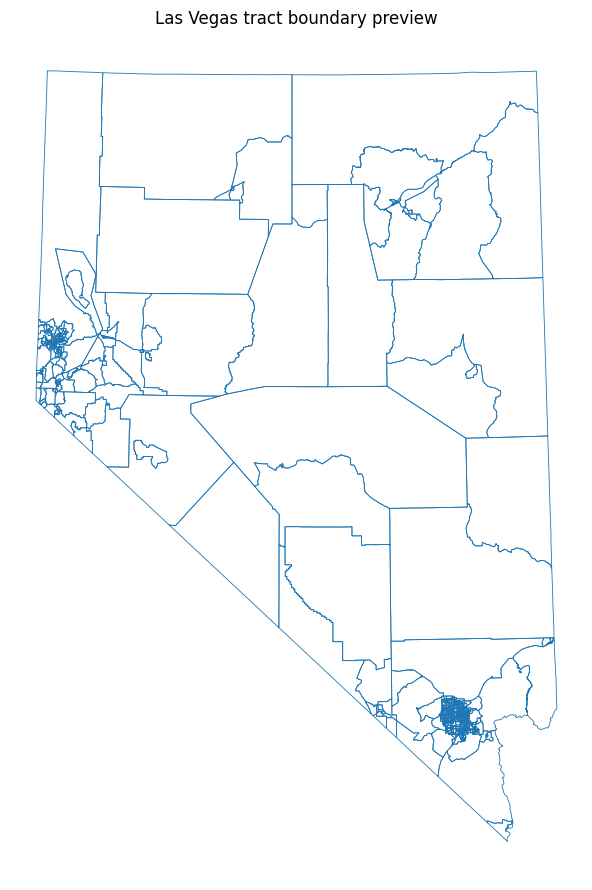


Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_tract_inventory.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_tract_boundary_preview.png
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/README_intake_status.md

Quick preview:


,GEOID,area_km2
0,32003002954,0.959868
1,32003004709,1.301052
2,32003002915,2.740170
3,32003002916,2.775261
4,32003002919,2.645347


,city,rows,crs,utm_crs,geoid_unique_n,geoid_duplicated_n,area_km2_min,area_km2_median,area_km2_max,tract_file_used
0,las_vegas,779,EPSG:32611,EPSG:32611,779,0,0.154689,2.005483,22500.782653,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [10]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# =========================
# FIXED ROOT (do not auto-detect)
# =========================
REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare").resolve()
CITY = "las_vegas"
CITY_LABEL = "Las Vegas"

print("REPO_ROOT =", REPO_ROOT)

CITY_PROC_DIR = REPO_ROOT / "data_processed" / CITY
CITY_FINAL_DIR = REPO_ROOT / "city_intake" / CITY / "final"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"

CITY_PROC_DIR.mkdir(parents=True, exist_ok=True)
CITY_FINAL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# FIND LAS VEGAS TRACT FILE
# =========================
all_gpkgs = sorted(CITY_PROC_DIR.glob("*.gpkg"))

def score_gpkg(p: Path):
    s = p.stem.lower()
    score = 0
    if "tract" in s:
        score += 10
    if "project" in s or "proj" in s:
        score += 6
    if "clean" in s:
        score += 1
    if "master" in s:
        score -= 8
    if "hotspot" in s or "hotcompare" in s or "gistar" in s or "demo" in s:
        score -= 8
    return score

ranked = sorted(all_gpkgs, key=lambda p: (score_gpkg(p), p.name), reverse=True)

print("\nAll gpkg files in city folder:")
for p in ranked:
    print(f"  score={score_gpkg(p):>2} | {p.name}")

if not ranked:
    raise FileNotFoundError(f"No .gpkg files found in {CITY_PROC_DIR}")

TRACT_GPKG = ranked[0]
print("\nUsing TRACT_GPKG:")
print(TRACT_GPKG)
print("Exists:", TRACT_GPKG.exists())

# =========================
# OUTPUT PATHS
# =========================
TRACT_INVENTORY_CSV = CITY_FINAL_DIR / f"{CITY}_tract_inventory.csv"
TRACT_SUMMARY_CSV = OUT_DIR / f"{CITY}_tract_summary.csv"
TRACT_PREVIEW_PNG = OUT_DIR / f"{CITY}_tract_boundary_preview.png"
TRACT_README_MD = CITY_FINAL_DIR / "README_intake_status.md"

# =========================
# LOAD TRACT GEOMETRY
# =========================
tracts_proj = gpd.read_file(TRACT_GPKG).copy()

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

geoid_col = first_existing(tracts_proj, ["GEOID", "geoid", "GEOIDFQ"])
if geoid_col is None:
    raise KeyError(f"No GEOID-like column found. Columns: {list(tracts_proj.columns)}")

tracts_proj["GEOID"] = (
    tracts_proj[geoid_col]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.zfill(11)
)

dup_n = int(tracts_proj["GEOID"].duplicated().sum())

print("\nRows:", len(tracts_proj))
print("CRS:", tracts_proj.crs)
print("Normalized GEOID unique:", tracts_proj["GEOID"].nunique())
print("Duplicated GEOID count:", dup_n)

# area_km2
utm_crs = tracts_proj.estimate_utm_crs()
tracts_metric = tracts_proj.to_crs(utm_crs)
tracts_proj["area_km2"] = tracts_metric.geometry.area / 1_000_000

# inventory
inventory_df = pd.DataFrame({
    "column_name": tracts_proj.columns,
    "dtype": [str(tracts_proj[c].dtype) if c != "geometry" else "geometry" for c in tracts_proj.columns],
    "non_null_n": [int(tracts_proj[c].notna().sum()) for c in tracts_proj.columns],
    "missing_n": [int(tracts_proj[c].isna().sum()) for c in tracts_proj.columns],
})
inventory_df.to_csv(TRACT_INVENTORY_CSV, index=False)

# summary
summary_df = pd.DataFrame([{
    "city": CITY,
    "rows": int(len(tracts_proj)),
    "crs": str(tracts_proj.crs),
    "utm_crs": str(utm_crs),
    "geoid_unique_n": int(tracts_proj["GEOID"].nunique()),
    "geoid_duplicated_n": dup_n,
    "area_km2_min": float(tracts_proj["area_km2"].min()),
    "area_km2_median": float(tracts_proj["area_km2"].median()),
    "area_km2_max": float(tracts_proj["area_km2"].max()),
    "tract_file_used": str(TRACT_GPKG),
}])
summary_df.to_csv(TRACT_SUMMARY_CSV, index=False)

# preview plot
fig, ax = plt.subplots(figsize=(7, 9))
tracts_proj.boundary.plot(ax=ax, linewidth=0.6)
ax.set_title(f"{CITY_LABEL} tract boundary preview")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(TRACT_PREVIEW_PNG, dpi=200, bbox_inches="tight")
plt.show()

# readme
readme_text = f"""# {CITY_LABEL} intake status

## Current status
- City: {CITY}
- Tract geometry loaded successfully
- Rows: {len(tracts_proj)}
- GEOID unique count: {tracts_proj["GEOID"].nunique()}
- GEOID duplicated count: {dup_n}
- CRS: {tracts_proj.crs}
- UTM CRS: {utm_crs}

## Files created
- tract file used: {TRACT_GPKG}
- tract inventory: {TRACT_INVENTORY_CSV}
- tract summary: {TRACT_SUMMARY_CSV}
- tract preview: {TRACT_PREVIEW_PNG}

## Interpretation
This step confirms that the Las Vegas tract boundary input is readable and standardized.
This does NOT yet mean the full AlphaEarth workflow is ready.
Next, we still need:
1. tract-level heat master table
2. AlphaEarth embedding / tract-mean embedding table
3. PC scores (can be recomputed later if needed)
"""
TRACT_README_MD.write_text(readme_text, encoding="utf-8")

print("\nSaved:")
print(" -", TRACT_INVENTORY_CSV)
print(" -", TRACT_SUMMARY_CSV)
print(" -", TRACT_PREVIEW_PNG)
print(" -", TRACT_README_MD)

print("\nQuick preview:")
display(tracts_proj[["GEOID", "area_km2"]].head())
display(summary_df)

In [11]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# =========================
# Fixed paths
# =========================
REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare").resolve()
CITY = "las_vegas"
CITY_LABEL = "Las Vegas"

TRACT_GPKG = REPO_ROOT / "data_processed" / CITY / f"{CITY}_tracts_projected.gpkg"
WORK_DIR = REPO_ROOT / "city_intake" / CITY / "working"
FINAL_DIR = REPO_ROOT / "city_intake" / CITY / "final"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"

WORK_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

HEAT_TEMPLATE_CSV = WORK_DIR / f"{CITY}_heat_master_template.csv"
HEAT_TEMPLATE_PREVIEW_CSV = OUT_DIR / f"{CITY}_heat_master_template_preview.csv"
HEAT_SCHEMA_SUMMARY_CSV = OUT_DIR / f"{CITY}_heat_master_template_summary.csv"
HEAT_TEMPLATE_README_MD = FINAL_DIR / f"{CITY}_heat_master_template_readme.md"

print("Using tract file:")
print(TRACT_GPKG)
print("Exists:", TRACT_GPKG.exists())

if not TRACT_GPKG.exists():
    raise FileNotFoundError(f"Missing tract gpkg: {TRACT_GPKG}")

# =========================
# Load tract geometry
# =========================
tracts = gpd.read_file(TRACT_GPKG).copy()

def first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# GEOID normalize
geoid_col = first_existing(tracts, ["GEOID", "geoid", "GEOIDFQ"])
if geoid_col is None:
    raise KeyError(f"No GEOID-like column found. Columns: {list(tracts.columns)}")

tracts["GEOID"] = (
    tracts[geoid_col]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .str.zfill(11)
)

# Optional columns from tract file
state_col = first_existing(tracts, ["STATEFP"])
county_col = first_existing(tracts, ["COUNTYFP"])
tractce_col = first_existing(tracts, ["TRACTCE"])
name_col = first_existing(tracts, ["NAME"])
namelsad_col = first_existing(tracts, ["NAMELSAD"])
aland_col = first_existing(tracts, ["ALAND"])
awater_col = first_existing(tracts, ["AWATER"])
area_col = first_existing(tracts, ["area_km2"])

def pull_or_na(df, colname, out_name=None):
    if out_name is None:
        out_name = colname
    if colname is None:
        return pd.Series([pd.NA] * len(df), index=df.index, name=out_name)
    return df[colname].copy()

# =========================
# Build heat master template
# =========================
template_df = pd.DataFrame({
    "GEOID": tracts["GEOID"].astype(str).str.zfill(11),
    "city": CITY,
    "STATEFP": pull_or_na(tracts, state_col, "STATEFP"),
    "COUNTYFP": pull_or_na(tracts, county_col, "COUNTYFP"),
    "TRACTCE": pull_or_na(tracts, tractce_col, "TRACTCE"),
    "NAME": pull_or_na(tracts, name_col, "NAME"),
    "NAMELSAD": pull_or_na(tracts, namelsad_col, "NAMELSAD"),
    "ALAND": pull_or_na(tracts, aland_col, "ALAND"),
    "AWATER": pull_or_na(tracts, awater_col, "AWATER"),
    "area_km2": pull_or_na(tracts, area_col, "area_km2"),

    # demographic / baseline fields
    "total_population": pd.NA,
    "total_population_clean": pd.NA,
    "median_household_income_clean": pd.NA,
    "poverty_rate": pd.NA,

    # heat-related fields
    "lst_c": pd.NA,
    "air_temp_c": pd.NA,
    "rh_pct": pd.NA,
    "hi_c": pd.NA,
    "hi_minus_lst": pd.NA,
})

# sort + deduplicate safeguard
template_df = (
    template_df
    .drop_duplicates(subset=["GEOID"])
    .sort_values("GEOID")
    .reset_index(drop=True)
)

template_df.to_csv(HEAT_TEMPLATE_CSV, index=False)
template_df.head(20).to_csv(HEAT_TEMPLATE_PREVIEW_CSV, index=False)

# =========================
# Summary table
# =========================
summary_df = pd.DataFrame([{
    "city": CITY,
    "rows": int(len(template_df)),
    "unique_geoid_n": int(template_df["GEOID"].nunique()),
    "missing_total_population_n": int(template_df["total_population"].isna().sum()),
    "missing_income_n": int(template_df["median_household_income_clean"].isna().sum()),
    "missing_poverty_rate_n": int(template_df["poverty_rate"].isna().sum()),
    "missing_lst_c_n": int(template_df["lst_c"].isna().sum()),
    "missing_hi_c_n": int(template_df["hi_c"].isna().sum()),
    "missing_hi_minus_lst_n": int(template_df["hi_minus_lst"].isna().sum()),
    "tract_file_used": str(TRACT_GPKG),
    "ready_for_modeling": False,
    "note": "Template only. Need real tract-level heat + demographic values before modeling."
}])
summary_df.to_csv(HEAT_SCHEMA_SUMMARY_CSV, index=False)

# =========================
# README
# =========================
readme_text = f"""# {CITY_LABEL} heat master template status

## What this file is
This is a template for the tract-level heat master table used in the AlphaEarth workflow.

## Current status
- City: {CITY}
- Rows: {len(template_df)}
- GEOID unique count: {template_df["GEOID"].nunique()}
- This is only a schema/template file.
- Real values for heat and demographics have NOT been filled yet.

## Required fields still needing real data
- total_population
- total_population_clean
- median_household_income_clean
- poverty_rate
- lst_c
- air_temp_c
- rh_pct
- hi_c
- hi_minus_lst

## Files created
- Heat master template: {HEAT_TEMPLATE_CSV}
- Preview: {HEAT_TEMPLATE_PREVIEW_CSV}
- Summary: {HEAT_SCHEMA_SUMMARY_CSV}

## Next step
Fill this template with real tract-level heat and demographic values, then continue to AlphaEarth embedding merge and PC generation.
"""
HEAT_TEMPLATE_README_MD.write_text(readme_text, encoding="utf-8")

# =========================
# Print preview
# =========================
print("\nSaved:")
print(" -", HEAT_TEMPLATE_CSV)
print(" -", HEAT_TEMPLATE_PREVIEW_CSV)
print(" -", HEAT_SCHEMA_SUMMARY_CSV)
print(" -", HEAT_TEMPLATE_README_MD)

print("\nTemplate shape:", template_df.shape)
print("\nColumns:")
print(list(template_df.columns))

print("\nTop 5 rows:")
display(template_df.head())

print("\nSummary:")
display(summary_df)

Using tract file:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
Exists: True

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_master_template_preview.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_master_template_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_heat_master_template_readme.md

Template shape: (779, 19)

Columns:
['GEOID', 'city', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'NAME', 'NAMELSAD', 'ALAND', 'AWATER', 'area_km2', 'total_population', 'total_population_clean', 'median_household_income_clean', 'poverty_rate', 'lst_c', 'air_temp_c', 'rh_pct', 'hi_c', 'hi_minus_lst']

Top 5 rows:


,GEOID,city,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,ALAND,AWATER,area_km2,total_population,total_population_clean,median_household_income_clean,poverty_rate,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst
0,32001950100,las_vegas,32,001,950100,9501,Census Tract 9501,9579192495,144611540,9718.544253,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,32001950301,las_vegas,32,001,950301,9503.01,Census Tract 9503.01,4483313,0,4.482280,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,32001950302,las_vegas,32,001,950302,9503.02,Census Tract 9503.02,5825693,0,5.824440,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,32001950400,las_vegas,32,001,950400,9504,Census Tract 9504,33945200,85200,34.021213,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,32001950500,las_vegas,32,001,950500,9505,Census Tract 9505,381112780,6227866,387.229677,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>



Summary:


,city,rows,unique_geoid_n,missing_total_population_n,missing_income_n,missing_poverty_rate_n,missing_lst_c_n,missing_hi_c_n,missing_hi_minus_lst_n,tract_file_used,ready_for_modeling,note
0,las_vegas,779,779,779,779,779,779,779,779,/Users/yufeizhou/Desktop/heat-exposure-compare...,False,Template only. Need real tract-level heat + de...


In [12]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# =========================
# fixed paths
# =========================
REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare").resolve()
CITY = "las_vegas"

PROC_DIR = REPO_ROOT / "data_processed" / CITY
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
FINAL_DIR = REPO_ROOT / "city_intake" / CITY / "final"

PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

TRACT_GPKG = PROC_DIR / f"{CITY}_tracts_projected.gpkg"
TRACT_GEOJSON = PROC_DIR / f"{CITY}_tracts_clean.geojson"

BACKUP_GPKG = PROC_DIR / f"{CITY}_tracts_projected_statewide_backup.gpkg"
BACKUP_GEOJSON = PROC_DIR / f"{CITY}_tracts_clean_statewide_backup.geojson"

SUMMARY_CSV = OUT_DIR / f"{CITY}_county_filter_summary.csv"
README_MD = FINAL_DIR / "README_county_filter_fix.md"

print("Input projected tract file:")
print(TRACT_GPKG)
print("Exists:", TRACT_GPKG.exists())

if not TRACT_GPKG.exists():
    raise FileNotFoundError(f"Missing tract file: {TRACT_GPKG}")

# =========================
# read current statewide file
# =========================
gdf = gpd.read_file(TRACT_GPKG).copy()

print("\nCurrent rows:", len(gdf))
print("Current CRS:", gdf.crs)
print("Columns:", list(gdf.columns))

if "COUNTYFP" not in gdf.columns:
    raise KeyError("COUNTYFP not found. Cannot subset Las Vegas / Clark County correctly.")

# normalize county
gdf["COUNTYFP"] = gdf["COUNTYFP"].astype(str).str.zfill(3)

print("\nCountyFP counts (top 10):")
print(gdf["COUNTYFP"].value_counts().head(10))

# =========================
# Clark County only
# Las Vegas first-pass = Clark County (003)
# =========================
clark = gdf[gdf["COUNTYFP"] == "003"].copy()

if len(clark) == 0:
    raise ValueError("Filtering COUNTYFP == '003' returned 0 rows. Something is wrong.")

# normalize GEOID
if "GEOID" in clark.columns:
    clark["GEOID"] = clark["GEOID"].astype(str).str.extract(r"(\d+)", expand=False).str.zfill(11)
elif "GEOIDFQ" in clark.columns:
    clark["GEOID"] = clark["GEOIDFQ"].astype(str).str.extract(r"(\d+)", expand=False).str[-11:].str.zfill(11)
else:
    raise KeyError("No GEOID-like column found.")

# recompute area if projected CRS
if clark.crs is not None and not clark.crs.is_geographic:
    clark["area_km2"] = clark.geometry.area / 1_000_000.0
else:
    print("Warning: CRS is geographic; area_km2 not recomputed.")

# =========================
# backup original statewide version once
# =========================
if not BACKUP_GPKG.exists():
    gdf.to_file(BACKUP_GPKG, driver="GPKG")
    print("\nSaved backup gpkg:")
    print(BACKUP_GPKG)
else:
    print("\nBackup gpkg already exists:")
    print(BACKUP_GPKG)

if TRACT_GEOJSON.exists() and (not BACKUP_GEOJSON.exists()):
    gdf.to_file(BACKUP_GEOJSON, driver="GeoJSON")
    print("Saved backup geojson:")
    print(BACKUP_GEOJSON)

# =========================
# overwrite canonical Las Vegas files
# =========================
clark.to_file(TRACT_GPKG, driver="GPKG")
clark.to_file(TRACT_GEOJSON, driver="GeoJSON")

# =========================
# summary + readme
# =========================
summary_df = pd.DataFrame([{
    "city": CITY,
    "filter_rule": "COUNTYFP == 003 (Clark County)",
    "rows_before": int(len(gdf)),
    "rows_after": int(len(clark)),
    "unique_geoid_after": int(clark["GEOID"].nunique()),
    "duplicate_geoid_after": int(clark["GEOID"].duplicated().sum()),
    "projected_gpkg": str(TRACT_GPKG),
    "clean_geojson": str(TRACT_GEOJSON),
    "backup_gpkg": str(BACKUP_GPKG),
}])
summary_df.to_csv(SUMMARY_CSV, index=False)

readme_text = f"""# Las Vegas county filter fix

## What happened
The original Las Vegas tract file was actually statewide Nevada tracts.

## Fix applied
Filtered tract boundary to Clark County only:
- COUNTYFP == 003

## Result
- rows before: {len(gdf)}
- rows after: {len(clark)}
- unique GEOID after: {clark["GEOID"].nunique()}
- duplicate GEOID after: {clark["GEOID"].duplicated().sum()}

## Files
- current projected tract file: {TRACT_GPKG}
- current clean geojson: {TRACT_GEOJSON}
- backup statewide gpkg: {BACKUP_GPKG}

## Note
This is a first-pass Las Vegas spatial definition using Clark County tracts.
If later we want a stricter Las Vegas urban footprint, we can clip further.
"""
README_MD.write_text(readme_text, encoding="utf-8")

# =========================
# print preview
# =========================
print("\n===== after Clark County filter =====")
print("Rows after:", len(clark))
print("Unique GEOID:", clark["GEOID"].nunique())
print("Duplicated GEOID:", clark["GEOID"].duplicated().sum())

preview_cols = [c for c in ["GEOID", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD", "area_km2"] if c in clark.columns]
display(clark[preview_cols].head())
display(summary_df)

Input projected tract file:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
Exists: True

Current rows: 779
Current CRS: EPSG:32611
Columns: ['GEOID', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'NAME', 'NAMELSAD', 'area_km2', 'GEOIDFQ', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']

CountyFP counts (top 10):
COUNTYFP
003    535
031    139
019     18
005     17
510     15
007     15
023     15
001      7
013      5
033      3
Name: count, dtype: int64

Saved backup gpkg:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected_statewide_backup.gpkg
Saved backup geojson:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_clean_statewide_backup.geojson

===== after Clark County filter =====
Rows after: 535
Unique GEOID: 535
Duplicated GEOID: 0


,GEOID,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,area_km2
0,32003002954,32,003,002954,29.54,Census Tract 29.54,0.959868
1,32003004709,32,003,004709,47.09,Census Tract 47.09,1.301052
2,32003002915,32,003,002915,29.15,Census Tract 29.15,2.740170
3,32003002916,32,003,002916,29.16,Census Tract 29.16,2.775261
4,32003002919,32,003,002919,29.19,Census Tract 29.19,2.645347


,city,filter_rule,rows_before,rows_after,unique_geoid_after,duplicate_geoid_after,projected_gpkg,clean_geojson,backup_gpkg
0,las_vegas,COUNTYFP == 003 (Clark County),779,535,535,0,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [20]:
from pathlib import Path
import requests
import pandas as pd
from getpass import getpass

# ========= 0) paths / city =========
REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"
YEAR = 2023

TRACT_GPKG = REPO_ROOT / "data_processed" / CITY / f"{CITY}_tracts_projected.gpkg"
OUT_DIR = REPO_ROOT / "city_intake" / CITY / "working"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ACS_CSV = OUT_DIR / f"{CITY}_acs_baseline.csv"
ACS_SUMMARY_CSV = OUT_DIR / f"{CITY}_acs_baseline_summary.csv"

# ========= 1) load tract file =========
import geopandas as gpd
tracts = gpd.read_file(TRACT_GPKG).copy()
tracts["GEOID"] = tracts["GEOID"].astype(str).str.zfill(11)

# Las Vegas -> Clark County only
if "COUNTYFP" in tracts.columns:
    tracts["COUNTYFP"] = tracts["COUNTYFP"].astype(str).str.zfill(3)
    tracts = tracts[tracts["COUNTYFP"] == "003"].copy()

print("Using tract gpkg:")
print(TRACT_GPKG)
print(f"Rows: {len(tracts)}")
print(f"Unique GEOID: {tracts['GEOID'].nunique()}")

# ========= 2) input API key =========
API_KEY = getpass("Paste your Census API key here, then press Enter: ").strip()

if not API_KEY:
    raise ValueError("Empty API key. Please rerun and paste your Census API key.")

# ========= 3) request ACS =========
ACS_URL = f"https://api.census.gov/data/{YEAR}/acs/acs5"
variables = [
    "NAME",
    "B01003_001E",  # total population
    "B19013_001E",  # median household income
    "B17001_002E",  # below poverty count
    "B17001_001E",  # poverty universe
]

params = {
    "get": ",".join(variables),
    "for": "tract:*",
    "in": "state:32 county:003",
    "key": API_KEY,
}

print("\nRequesting ACS baseline table...")
resp = requests.get(ACS_URL, params=params, timeout=60)

print("Status code:", resp.status_code)
print("Final URL:", resp.url)
print("\nResponse text preview:")
print(resp.text[:500])

text_lower = resp.text.lower()

if "invalid key" in text_lower:
    raise ValueError(
        "Census returned 'Invalid Key'. "
        "Your key is activated, so this usually means the pasted value in this run was not the exact key string, "
        "or the activation has not propagated yet. Wait 5–10 minutes and rerun this cell once."
    )

if resp.status_code != 200:
    raise ValueError(f"Request failed with status {resp.status_code}. See preview above.")

# ========= 4) parse response =========
data = resp.json()
header = data[0]
rows = data[1:]
acs = pd.DataFrame(rows, columns=header)

# ========= 5) clean / rename =========
acs["state"] = acs["state"].astype(str).str.zfill(2)
acs["county"] = acs["county"].astype(str).str.zfill(3)
acs["tract"] = acs["tract"].astype(str).str.zfill(6)
acs["GEOID"] = acs["state"] + acs["county"] + acs["tract"]

rename_map = {
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income",
    "B17001_002E": "below_poverty_count",
    "B17001_001E": "poverty_universe",
}
acs = acs.rename(columns=rename_map)

def to_num(s):
    return pd.to_numeric(s.replace({"-666666666": pd.NA, "-222222222": pd.NA, "-333333333": pd.NA}), errors="coerce")

for c in ["total_population", "median_household_income", "below_poverty_count", "poverty_universe"]:
    acs[c] = to_num(acs[c])

acs["poverty_rate"] = acs["below_poverty_count"] / acs["poverty_universe"]
acs["poverty_rate"] = acs["poverty_rate"].where(acs["poverty_universe"] > 0, pd.NA)

acs = acs[[
    "GEOID", "NAME",
    "total_population",
    "median_household_income",
    "below_poverty_count",
    "poverty_universe",
    "poverty_rate"
]].copy()

# ========= 6) save =========
acs.to_csv(ACS_CSV, index=False)

summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(acs),
    "unique_geoid_n": acs["GEOID"].nunique(),
    "missing_total_population_n": int(acs["total_population"].isna().sum()),
    "missing_income_n": int(acs["median_household_income"].isna().sum()),
    "missing_poverty_rate_n": int(acs["poverty_rate"].isna().sum()),
    "output_csv": str(ACS_CSV),
}])
summary.to_csv(ACS_SUMMARY_CSV, index=False)

print("\nSaved:")
print(" -", ACS_CSV)
print(" -", ACS_SUMMARY_CSV)

print("\nPreview:")
display(acs.head())
display(summary)

Using tract gpkg:
/Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
Rows: 535
Unique GEOID: 535

Requesting ACS baseline table...
Status code: 200
Final URL: https://api.census.gov/data/2023/acs/acs5?get=NAME%2CB01003_001E%2CB19013_001E%2CB17001_002E%2CB17001_001E&for=tract%3A%2A&in=state%3A32+county%3A003&key=aa1c31c0d936988bc863404d97cac6e457e3a4f3

Response text preview:
[["NAME","B01003_001E","B19013_001E","B17001_002E","B17001_001E","state","county","tract"],
["Census Tract 1.01; Clark County; Nevada","6888","75327","887","6860","32","003","000101"],
["Census Tract 1.03; Clark County; Nevada","6700","70966","647","6599","32","003","000103"],
["Census Tract 1.05; Clark County; Nevada","3672","85481","462","3672","32","003","000105"],
["Census Tract 1.06; Clark County; Nevada","4362","42947","791","4359","32","003","000106"],
["Census Tract 1.07; Clark County; N

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intak

,GEOID,NAME,total_population,median_household_income,below_poverty_count,poverty_universe,poverty_rate
0,32003000101,Census Tract 1.01; Clark County; Nevada,6888,75327.0,887,6860,0.129300
1,32003000103,Census Tract 1.03; Clark County; Nevada,6700,70966.0,647,6599,0.098045
2,32003000105,Census Tract 1.05; Clark County; Nevada,3672,85481.0,462,3672,0.125817
3,32003000106,Census Tract 1.06; Clark County; Nevada,4362,42947.0,791,4359,0.181464
4,32003000107,Census Tract 1.07; Clark County; Nevada,3965,49583.0,1040,3965,0.262295


,city,rows,unique_geoid_n,missing_total_population_n,missing_income_n,missing_poverty_rate_n,output_csv
0,las_vegas,535,535,0,1,0,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [21]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# =========================
# 0) basic paths
# =========================
REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

TRACT_GPKG = REPO_ROOT / "data_processed" / CITY / f"{CITY}_tracts_projected.gpkg"
ACS_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_acs_baseline.csv"

OUT_DIR = REPO_ROOT / "city_intake" / CITY / "working"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_SCAFFOLD_CSV = OUT_DIR / f"{CITY}_master_scaffold.csv"
MASTER_SCAFFOLD_SUMMARY_CSV = OUT_DIR / f"{CITY}_master_scaffold_summary.csv"

print("Using files:")
print(" -", TRACT_GPKG)
print(" -", ACS_CSV)

# =========================
# 1) read tracts
# =========================
tracts = gpd.read_file(TRACT_GPKG).copy()
tracts["GEOID"] = tracts["GEOID"].astype(str).str.zfill(11)

# keep Clark County only for consistency
if "COUNTYFP" in tracts.columns:
    tracts["COUNTYFP"] = tracts["COUNTYFP"].astype(str).str.zfill(3)
    tracts = tracts[tracts["COUNTYFP"] == "003"].copy()

print(f"\nTracts rows after filter: {len(tracts)}")
print(f"Unique tract GEOID: {tracts['GEOID'].nunique()}")

# choose useful tract columns if present
tract_keep = [
    "GEOID", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD",
    "ALAND", "AWATER", "area_km2", "geometry"
]
tract_keep = [c for c in tract_keep if c in tracts.columns]
tracts = tracts[tract_keep].copy()

# =========================
# 2) read ACS baseline
# =========================
acs = pd.read_csv(ACS_CSV).copy()
acs["GEOID"] = acs["GEOID"].astype(str).str.zfill(11)

print(f"\nACS rows: {len(acs)}")
print(f"Unique ACS GEOID: {acs['GEOID'].nunique()}")

# rename to match your existing city convention
rename_map = {
    "total_population": "total_population_clean",
    "median_household_income": "median_household_income_clean",
}
acs = acs.rename(columns=rename_map)

# keep useful ACS columns
acs_keep = [
    "GEOID",
    "NAME",
    "total_population_clean",
    "median_household_income_clean",
    "below_poverty_count",
    "poverty_universe",
    "poverty_rate",
]
acs_keep = [c for c in acs_keep if c in acs.columns]
acs = acs[acs_keep].copy()

# if there is a duplicate NAME from ACS, rename it
if "NAME" in acs.columns and "NAME" in tracts.columns:
    acs = acs.rename(columns={"NAME": "acs_name"})

# =========================
# 3) merge
# =========================
master = tracts.merge(acs, on="GEOID", how="left", validate="1:1").copy()
master["city"] = CITY

# add placeholder heat columns if not present yet
placeholder_cols = [
    "lst_c",
    "air_temp_c",
    "rh_pct",
    "hi_c",
    "hi_minus_lst",
]
for c in placeholder_cols:
    if c not in master.columns:
        master[c] = pd.NA

# add placeholder readiness flags
master["has_heat_data"] = master["lst_c"].notna()
master["has_alphaearth_embedding"] = False
master["has_pc_scores"] = False

# reorder important columns first
front_cols = [
    "GEOID", "city", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD",
    "ALAND", "AWATER", "area_km2",
    "total_population_clean", "median_household_income_clean",
    "below_poverty_count", "poverty_universe", "poverty_rate",
    "lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst",
    "has_heat_data", "has_alphaearth_embedding", "has_pc_scores",
]
front_cols = [c for c in front_cols if c in master.columns]
other_cols = [c for c in master.columns if c not in front_cols]
master = master[front_cols + other_cols]

# =========================
# 4) save
# =========================
master.to_csv(MASTER_SCAFFOLD_CSV, index=False)

summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(master),
    "unique_geoid_n": master["GEOID"].nunique(),
    "missing_total_population_n": int(master["total_population_clean"].isna().sum()) if "total_population_clean" in master.columns else None,
    "missing_income_n": int(master["median_household_income_clean"].isna().sum()) if "median_household_income_clean" in master.columns else None,
    "missing_poverty_rate_n": int(master["poverty_rate"].isna().sum()) if "poverty_rate" in master.columns else None,
    "missing_lst_c_n": int(master["lst_c"].isna().sum()),
    "missing_hi_c_n": int(master["hi_c"].isna().sum()),
    "output_csv": str(MASTER_SCAFFOLD_CSV),
}])
summary.to_csv(MASTER_SCAFFOLD_SUMMARY_CSV, index=False)

print("\nSaved:")
print(" -", MASTER_SCAFFOLD_CSV)
print(" -", MASTER_SCAFFOLD_SUMMARY_CSV)

print("\nPreview:")
display(master.head())
display(summary)

Using files:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_acs_baseline.csv

Tracts rows after filter: 535
Unique tract GEOID: 535

ACS rows: 535
Unique ACS GEOID: 535

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_master_scaffold.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_master_scaffold_summary.csv

Preview:


,GEOID,city,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,ALAND,AWATER,area_km2,...,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst,has_heat_data,has_alphaearth_embedding,has_pc_scores,geometry,acs_name
0,32003002954,las_vegas,32,003,002954,29.54,Census Tract 29.54,960016,0,0.959868,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,"POLYGON ((661250.187 3999123.852, 661249.744 3...",Census Tract 29.54; Clark County; Nevada
1,32003004709,las_vegas,32,003,004709,47.09,Census Tract 47.09,1301127,0,1.301052,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,"POLYGON ((672615.985 4007350.396, 672628.664 4...",Census Tract 47.09; Clark County; Nevada
2,32003002915,las_vegas,32,003,002915,29.15,Census Tract 29.15,2740731,0,2.740170,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,"POLYGON ((654690.431 4002966.869, 654749.688 4...",Census Tract 29.15; Clark County; Nevada
3,32003002916,las_vegas,32,003,002916,29.16,Census Tract 29.16,2775794,0,2.775261,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,"POLYGON ((656305.177 4003001.394, 656332.979 4...",Census Tract 29.16; Clark County; Nevada
4,32003002919,las_vegas,32,003,002919,29.19,Census Tract 29.19,2645848,0,2.645347,...,<NA>,<NA>,<NA>,<NA>,<NA>,False,False,False,"POLYGON ((656510.098 3998115.018, 656509.906 3...",Census Tract 29.19; Clark County; Nevada


,city,rows,unique_geoid_n,missing_total_population_n,missing_income_n,missing_poverty_rate_n,missing_lst_c_n,missing_hi_c_n,output_csv
0,las_vegas,535,535,0,1,0,535,535,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [22]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

MASTER_SCAFFOLD_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_master_scaffold.csv"
OUT_DIR = REPO_ROOT / "city_intake" / CITY / "working"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HEAT_TEMPLATE_CSV = OUT_DIR / f"{CITY}_heat_master_template.csv"
HEAT_TEMPLATE_SUMMARY_CSV = OUT_DIR / f"{CITY}_heat_master_template_summary.csv"
HEAT_TEMPLATE_README_MD = REPO_ROOT / "city_intake" / CITY / "final" / f"{CITY}_heat_master_template_readme.md"

df = pd.read_csv(MASTER_SCAFFOLD_CSV)

# keep the stable join/baseline structure
keep_cols = [
    "GEOID",
    "city",
    "STATEFP",
    "COUNTYFP",
    "TRACTCE",
    "NAME",
    "NAMELSAD",
    "ALAND",
    "AWATER",
    "area_km2",
    "total_population_clean",
    "median_household_income_clean",
    "below_poverty_count",
    "poverty_universe",
    "poverty_rate",
]

keep_cols = [c for c in keep_cols if c in df.columns]
heat_template = df[keep_cols].copy()

# add real heat slots to be filled later
for col in ["lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst"]:
    heat_template[col] = pd.NA

# add status columns for workflow tracking
heat_template["heat_source_file"] = pd.NA
heat_template["heat_merge_status"] = "pending"
heat_template["notes"] = pd.NA

heat_template.to_csv(HEAT_TEMPLATE_CSV, index=False)

summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(heat_template),
    "unique_geoid_n": heat_template["GEOID"].astype(str).nunique(),
    "missing_total_population_n": int(heat_template["total_population_clean"].isna().sum()) if "total_population_clean" in heat_template.columns else None,
    "missing_income_n": int(heat_template["median_household_income_clean"].isna().sum()) if "median_household_income_clean" in heat_template.columns else None,
    "missing_poverty_rate_n": int(heat_template["poverty_rate"].isna().sum()) if "poverty_rate" in heat_template.columns else None,
    "missing_lst_c_n": int(heat_template["lst_c"].isna().sum()),
    "missing_air_temp_c_n": int(heat_template["air_temp_c"].isna().sum()),
    "missing_rh_pct_n": int(heat_template["rh_pct"].isna().sum()),
    "missing_hi_c_n": int(heat_template["hi_c"].isna().sum()),
    "missing_hi_minus_lst_n": int(heat_template["hi_minus_lst"].isna().sum()),
    "output_csv": str(HEAT_TEMPLATE_CSV),
}])

summary.to_csv(HEAT_TEMPLATE_SUMMARY_CSV, index=False)

readme_text = f"""# {CITY} heat master template

## Current status
This file is a heat-ready master template for {CITY}.

It already includes:
- tract join key (GEOID)
- tract identifiers and geometry-related summary fields
- ACS baseline variables:
  - total_population_clean
  - median_household_income_clean
  - below_poverty_count
  - poverty_universe
  - poverty_rate

It does NOT yet include real heat variables.

## Heat columns reserved for next step
- lst_c
- air_temp_c
- rh_pct
- hi_c
- hi_minus_lst

## Interpretation
This means Las Vegas is now ready for the real heat-data integration step.
Once a tract-level heat table is prepared, it should merge into this template by GEOID.

## Files created
- {HEAT_TEMPLATE_CSV}
- {HEAT_TEMPLATE_SUMMARY_CSV}
"""

HEAT_TEMPLATE_README_MD.write_text(readme_text, encoding="utf-8")

print("Saved:")
print(" -", HEAT_TEMPLATE_CSV)
print(" -", HEAT_TEMPLATE_SUMMARY_CSV)
print(" -", HEAT_TEMPLATE_README_MD)

print("\nPreview:")
display(heat_template.head())
display(summary)

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_heat_master_template_readme.md

Preview:


,GEOID,city,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,ALAND,AWATER,area_km2,...,poverty_universe,poverty_rate,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst,heat_source_file,heat_merge_status,notes
0,32003002954,las_vegas,32,3,2954,29.54,Census Tract 29.54,960016,0,0.959868,...,4274,0.330370,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending,<NA>
1,32003004709,las_vegas,32,3,4709,47.09,Census Tract 47.09,1301127,0,1.301052,...,5491,0.205063,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending,<NA>
2,32003002915,las_vegas,32,3,2915,29.15,Census Tract 29.15,2740731,0,2.740170,...,4216,0.175759,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending,<NA>
3,32003002916,las_vegas,32,3,2916,29.16,Census Tract 29.16,2775794,0,2.775261,...,2802,0.178087,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending,<NA>
4,32003002919,las_vegas,32,3,2919,29.19,Census Tract 29.19,2645848,0,2.645347,...,4454,0.076785,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,pending,<NA>


,city,rows,unique_geoid_n,missing_total_population_n,missing_income_n,missing_poverty_rate_n,missing_lst_c_n,missing_air_temp_c_n,missing_rh_pct_n,missing_hi_c_n,missing_hi_minus_lst_n,output_csv
0,las_vegas,535,535,0,1,0,535,535,535,535,535,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [23]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# ============================================================
# Las Vegas heat extraction input package
# tract geometry + ACS baseline + empty heat slots
# ============================================================

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

TRACT_GPKG = REPO_ROOT / "data_processed" / CITY / f"{CITY}_tracts_projected.gpkg"
ACS_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_acs_baseline.csv"

WORK_DIR = REPO_ROOT / "city_intake" / CITY / "working"
FINAL_DIR = REPO_ROOT / "city_intake" / CITY / "final"
WORK_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

HEAT_INPUT_GPKG = WORK_DIR / f"{CITY}_heat_extraction_input.gpkg"
HEAT_INPUT_GEOJSON = WORK_DIR / f"{CITY}_heat_extraction_input.geojson"
HEAT_INPUT_CSV = WORK_DIR / f"{CITY}_heat_extraction_input.csv"
HEAT_INPUT_SUMMARY_CSV = WORK_DIR / f"{CITY}_heat_extraction_input_summary.csv"
HEAT_INPUT_README_MD = FINAL_DIR / f"{CITY}_heat_extraction_input_readme.md"

# ---------------------------
# 0) sanity check
# ---------------------------
for p in [TRACT_GPKG, ACS_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required input: {p}")

print("Using files:")
print(" -", TRACT_GPKG)
print(" -", ACS_CSV)

# ---------------------------
# 1) read inputs
# ---------------------------
tracts = gpd.read_file(TRACT_GPKG).copy()
acs = pd.read_csv(ACS_CSV).copy()

tracts["GEOID"] = tracts["GEOID"].astype(str).str.zfill(11)
acs["GEOID"] = acs["GEOID"].astype(str).str.zfill(11)

print("\nTracts rows:", len(tracts))
print("Unique tract GEOID:", tracts["GEOID"].nunique())
print("ACS rows:", len(acs))
print("Unique ACS GEOID:", acs["GEOID"].nunique())

# ---------------------------
# 2) keep stable ACS columns
# ---------------------------
acs_keep = [
    "GEOID",
    "NAME",
    "total_population",
    "total_population_clean",
    "median_household_income",
    "median_household_income_clean",
    "below_poverty_count",
    "poverty_universe",
    "poverty_rate",
]

acs_keep = [c for c in acs_keep if c in acs.columns]
acs_sub = acs[acs_keep].copy()

# rename ACS NAME to avoid collision if needed
if "NAME" in acs_sub.columns:
    acs_sub = acs_sub.rename(columns={"NAME": "acs_name"})

# ---------------------------
# 3) merge tract + ACS
# ---------------------------
gdf = tracts.merge(acs_sub, on="GEOID", how="left", validate="1:1")

if "city" not in gdf.columns:
    gdf["city"] = CITY
else:
    gdf["city"] = gdf["city"].fillna(CITY)

# centroid lon/lat for later QC / possible exports
centroids = gpd.GeoSeries(gdf.geometry.centroid, crs=gdf.crs).to_crs(4326)
gdf["centroid_lon"] = centroids.x
gdf["centroid_lat"] = centroids.y

# reserve heat columns
for col in ["lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst"]:
    if col not in gdf.columns:
        gdf[col] = pd.NA

# workflow flags
gdf["has_heat_data"] = False
gdf["has_alphaearth_embedding"] = False
gdf["has_pc_scores"] = False

# ---------------------------
# 4) export files
# ---------------------------
gdf.to_file(HEAT_INPUT_GPKG, driver="GPKG")
gdf.to_crs(4326).to_file(HEAT_INPUT_GEOJSON, driver="GeoJSON")

attr_df = pd.DataFrame(gdf.drop(columns="geometry"))
attr_df.to_csv(HEAT_INPUT_CSV, index=False)

wgs84 = gdf.to_crs(4326)
xmin, ymin, xmax, ymax = wgs84.total_bounds

summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(gdf),
    "unique_geoid_n": gdf["GEOID"].nunique(),
    "crs": str(gdf.crs),
    "lon_min": xmin,
    "lat_min": ymin,
    "lon_max": xmax,
    "lat_max": ymax,
    "missing_total_population_n": int(gdf["total_population_clean"].isna().sum()) if "total_population_clean" in gdf.columns else None,
    "missing_income_n": int(gdf["median_household_income_clean"].isna().sum()) if "median_household_income_clean" in gdf.columns else None,
    "missing_poverty_rate_n": int(gdf["poverty_rate"].isna().sum()) if "poverty_rate" in gdf.columns else None,
    "missing_lst_c_n": int(gdf["lst_c"].isna().sum()),
    "missing_air_temp_c_n": int(gdf["air_temp_c"].isna().sum()),
    "missing_rh_pct_n": int(gdf["rh_pct"].isna().sum()),
    "missing_hi_c_n": int(gdf["hi_c"].isna().sum()),
    "missing_hi_minus_lst_n": int(gdf["hi_minus_lst"].isna().sum()),
    "output_gpkg": str(HEAT_INPUT_GPKG),
    "output_geojson": str(HEAT_INPUT_GEOJSON),
    "output_csv": str(HEAT_INPUT_CSV),
}])

summary.to_csv(HEAT_INPUT_SUMMARY_CSV, index=False)

readme_text = f"""# {CITY} heat extraction input package

## What this file is
This package combines:
- tract geometry
- GEOID join key
- ACS baseline variables
- reserved heat columns for future integration

## Current status
This means {CITY} is now ready for the next stage:
heat-data integration / heat extraction workflow.

## Included baseline fields
- total_population_clean
- median_household_income_clean
- below_poverty_count
- poverty_universe
- poverty_rate

## Reserved heat fields
- lst_c
- air_temp_c
- rh_pct
- hi_c
- hi_minus_lst

## Output files
- {HEAT_INPUT_GPKG}
- {HEAT_INPUT_GEOJSON}
- {HEAT_INPUT_CSV}
- {HEAT_INPUT_SUMMARY_CSV}
"""

HEAT_INPUT_README_MD.write_text(readme_text, encoding="utf-8")

# ---------------------------
# 5) preview
# ---------------------------
preview_cols = [
    "GEOID", "city", "STATEFP", "COUNTYFP", "TRACTCE",
    "area_km2", "total_population_clean", "median_household_income_clean",
    "poverty_rate", "lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst"
]
preview_cols = [c for c in preview_cols if c in gdf.columns]

print("\nSaved:")
print(" -", HEAT_INPUT_GPKG)
print(" -", HEAT_INPUT_GEOJSON)
print(" -", HEAT_INPUT_CSV)
print(" -", HEAT_INPUT_SUMMARY_CSV)
print(" -", HEAT_INPUT_README_MD)

print("\nPreview:")
display(gdf[preview_cols].head())
display(summary)

Using files:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/las_vegas/las_vegas_tracts_projected.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_acs_baseline.csv

Tracts rows: 535
Unique tract GEOID: 535
ACS rows: 535
Unique ACS GEOID: 535

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input.geojson
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final/las_vegas_heat_extraction_input_readme.md

Preview:


,GEOID,city,STATEFP,COUNTYFP,TRACTCE,area_km2,poverty_rate,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst
0,32003002954,las_vegas,32,003,002954,0.959868,0.330370,<NA>,<NA>,<NA>,<NA>,<NA>
1,32003004709,las_vegas,32,003,004709,1.301052,0.205063,<NA>,<NA>,<NA>,<NA>,<NA>
2,32003002915,las_vegas,32,003,002915,2.740170,0.175759,<NA>,<NA>,<NA>,<NA>,<NA>
3,32003002916,las_vegas,32,003,002916,2.775261,0.178087,<NA>,<NA>,<NA>,<NA>,<NA>
4,32003002919,las_vegas,32,003,002919,2.645347,0.076785,<NA>,<NA>,<NA>,<NA>,<NA>


,city,rows,unique_geoid_n,crs,lon_min,lat_min,lon_max,lat_max,missing_total_population_n,missing_income_n,missing_poverty_rate_n,missing_lst_c_n,missing_air_temp_c_n,missing_rh_pct_n,missing_hi_c_n,missing_hi_minus_lst_n,output_gpkg,output_geojson,output_csv
0,las_vegas,535,535,EPSG:32611,-115.896925,35.001857,-114.042819,36.853662,None,None,0,535,535,535,535,535,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [24]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import zipfile
import json

# ============================================================
# 17_las_vegas_heat_integration.ipynb
# Cell 1: inventory local heat-like source files for Las Vegas
# ============================================================

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

SEARCH_ROOTS = [
    REPO_ROOT / "data_raw",
    REPO_ROOT / "data_processed",
    REPO_ROOT / "city_intake",
    Path.home() / "Downloads",
    Path.home() / "Documents",
]

OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / f"{CITY}_heat_source_inventory.csv"
OUT_TOP_CSV = OUT_DIR / f"{CITY}_heat_source_top_candidates.csv"

TOKENS = ["las_vegas", "las vegas", "vegas", "clark", "nevada"]
HEAT_KEYS = [
    "lst", "lst_c", "land_surface_temperature",
    "hi", "hi_c", "heat_index", "hi_minus_lst",
    "air_temp", "air_temp_c", "temperature",
    "rh", "rh_pct", "humidity"
]
JOIN_KEYS = ["geoid", "tractce", "tract", "statefp", "countyfp"]

EXCLUDE_PARTS = {
    ".git", ".venv", ".venv-1", ".venv-2", "node_modules",
    "__pycache__", ".ipynb_checkpoints", "archive_old"
}

def should_skip(path: Path) -> bool:
    parts = set(path.parts)
    return len(parts.intersection(EXCLUDE_PARTS)) > 0

def token_score(path: Path) -> int:
    s = str(path).lower()
    score = 0
    for t in TOKENS:
        if t in s:
            score += 2
    return score

def inspect_csv(path: Path):
    try:
        df = pd.read_csv(path, nrows=5)
        cols = [str(c) for c in df.columns]
        return cols, len(cols), None
    except Exception as e:
        return [], 0, str(e)

def inspect_geo(path: Path):
    try:
        gdf = gpd.read_file(path, rows=5)
        cols = [str(c) for c in gdf.columns]
        return cols, len(cols), None
    except Exception as e:
        return [], 0, str(e)

def inspect_zip(path: Path):
    try:
        with zipfile.ZipFile(path, "r") as z:
            names = z.namelist()[:50]
        return names, len(names), None
    except Exception as e:
        return [], 0, str(e)

def content_score(names_or_cols):
    items = [str(x).lower() for x in names_or_cols]
    score = 0

    for k in JOIN_KEYS:
        if any(k in x for x in items):
            score += 2

    heat_hit_n = 0
    for k in HEAT_KEYS:
        if any(k in x for x in items):
            heat_hit_n += 1
    score += min(heat_hit_n, 6)

    if any("geometry" in x for x in items):
        score += 2

    return score

rows = []

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for path in root.rglob("*"):
        if should_skip(path):
            continue
        if not path.is_file():
            continue

        suffix = path.suffix.lower()
        if suffix not in {".csv", ".gpkg", ".geojson", ".zip", ".json", ".parquet"}:
            continue

        path_str = str(path).lower()
        if not any(t in path_str for t in TOKENS):
            continue

        file_token_score = token_score(path)
        cols_or_names = []
        inspect_error = None

        if suffix == ".csv":
            cols_or_names, n_cols, inspect_error = inspect_csv(path)
        elif suffix in {".gpkg", ".geojson"}:
            cols_or_names, n_cols, inspect_error = inspect_geo(path)
        elif suffix == ".zip":
            cols_or_names, n_cols, inspect_error = inspect_zip(path)
        else:
            # .json / .parquet: only filename-level scoring first
            n_cols = 0

        score = file_token_score + content_score(cols_or_names)

        heat_flag = any(k in " ".join([str(x).lower() for x in cols_or_names]) for k in HEAT_KEYS)
        geoid_flag = any(k in " ".join([str(x).lower() for x in cols_or_names]) for k in JOIN_KEYS)

        rows.append({
            "path": str(path),
            "name": path.name,
            "suffix": suffix,
            "root": str(root),
            "token_score": file_token_score,
            "content_score": content_score(cols_or_names),
            "total_score": score,
            "has_heat_like_fields": heat_flag,
            "has_join_like_fields": geoid_flag,
            "inspect_n": n_cols,
            "preview": json.dumps(cols_or_names[:20], ensure_ascii=False),
            "inspect_error": inspect_error,
        })

inventory = pd.DataFrame(rows)

if inventory.empty:
    print("No Las Vegas / Clark / Nevada candidate files found locally.")
else:
    inventory = inventory.sort_values(
        ["total_score", "has_heat_like_fields", "has_join_like_fields", "name"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

inventory.to_csv(OUT_CSV, index=False)

top = inventory[
    (inventory["total_score"] >= 4) |
    (inventory["has_heat_like_fields"]) |
    (inventory["has_join_like_fields"])
].copy()

top.to_csv(OUT_TOP_CSV, index=False)

print("Saved:")
print(" -", OUT_CSV)
print(" -", OUT_TOP_CSV)

print("\nTop candidates:")
display(top.head(20))

print("\nFull inventory:")
display(inventory.head(50))

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_source_inventory.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_source_top_candidates.csv

Top candidates:


,path,name,suffix,root,token_score,content_score,total_score,has_heat_like_fields,has_join_like_fields,inspect_n,preview,inspect_error
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,32,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,32,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_master_scaffold.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,25,"[""GEOID"", ""city"", ""STATEFP"", ""COUNTYFP"", ""TRAC...",None
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,16,20,True,True,31,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,16,20,True,True,23,"[""GEOID"", ""city"", ""STATEFP"", ""COUNTYFP"", ""TRAC...",None
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_clean.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_clean_statewide_backup.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
7,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_projected.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
8,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_projected_statewide_backup.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
9,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input_summary.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,8,12,True,True,19,"[""city"", ""rows"", ""unique_geoid_n"", ""crs"", ""lon...",None



Full inventory:


,path,name,suffix,root,token_score,content_score,total_score,has_heat_like_fields,has_join_like_fields,inspect_n,preview,inspect_error
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,32,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,32,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_master_scaffold.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,18,22,True,True,25,"[""GEOID"", ""city"", ""STATEFP"", ""COUNTYFP"", ""TRAC...",None
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,16,20,True,True,31,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,16,20,True,True,23,"[""GEOID"", ""city"", ""STATEFP"", ""COUNTYFP"", ""TRAC...",None
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_clean.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_clean_statewide_backup.geojson,.geojson,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
7,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_projected.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
8,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_tracts_projected_statewide_backup.gpkg,.gpkg,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,12,16,False,True,15,"[""GEOID"", ""STATEFP"", ""COUNTYFP"", ""TRACTCE"", ""N...",None
9,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input_summary.csv,.csv,/Users/yufeizhou/Desktop/heat-exposure-compare...,4,8,12,True,True,19,"[""city"", ""rows"", ""unique_geoid_n"", ""crs"", ""lon...",None


In [26]:
from pathlib import Path
import json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import ee

# ============================================================
# Las Vegas real LST extraction (fixed version)
# Fix:
# 1) avoid lst_c_x / lst_c_y collision
# 2) overwrite placeholder lst_c directly
# 3) robust handling of EE output field names
# ============================================================

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

INPUT_GEOJSON = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_heat_extraction_input.geojson"
OUT_DIR = REPO_ROOT / "city_intake" / CITY / "working"
PLOT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"

OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LST_CSV = OUT_DIR / f"{CITY}_lst_modis_summer2024.csv"
LST_SUMMARY_CSV = OUT_DIR / f"{CITY}_lst_modis_summer2024_summary.csv"
LST_PREVIEW_PNG = PLOT_DIR / f"{CITY}_lst_modis_summer2024_preview.png"

SUMMER_START = "2024-06-01"
SUMMER_END   = "2024-09-01"

# ----------------------------
# 1) Earth Engine initialize
# ----------------------------
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

# ----------------------------
# 2) Load local tract input
# ----------------------------
gdf = gpd.read_file(INPUT_GEOJSON).copy()
gdf = gdf[gdf.geometry.notna()].copy()
gdf["GEOID"] = gdf["GEOID"].astype(str).str.zfill(11)

# clean possible old duplicate columns from previous failed merges
for c in ["lst_c_x", "lst_c_y"]:
    if c in gdf.columns:
        gdf = gdf.drop(columns=c)

print("Local tract rows:", len(gdf))
print("Unique GEOID:", gdf["GEOID"].nunique())
print("Input file:", INPUT_GEOJSON)

# only send GEOID + geometry to EE
gdf_ll = gdf[["GEOID", "geometry"]].to_crs(4326).copy()
fc = ee.FeatureCollection(json.loads(gdf_ll.to_json()))

# ----------------------------
# 3) MODIS LST collection
# ----------------------------
lst_ic = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(SUMMER_START, SUMMER_END)
    .select("LST_Day_1km")
    .map(lambda img: img.multiply(0.02).subtract(273.15).rename("lst_c"))
)

n_imgs = lst_ic.size().getInfo()
print("MODIS image count:", n_imgs)

if n_imgs == 0:
    raise ValueError("No MODIS images returned for the chosen date range.")

lst_mean = lst_ic.mean()

# ----------------------------
# 4) Reduce to tract means
# ----------------------------
reduced = lst_mean.reduceRegions(
    collection=fc,
    reducer=ee.Reducer.mean(),
    scale=1000,
    tileScale=4
)

features = reduced.getInfo()["features"]

rows = []
for f in features:
    props = f.get("properties", {})
    geoid_val = props.get("GEOID")

    # robust to different output names
    lst_val = None
    if "mean" in props:
        lst_val = props.get("mean")
    elif "lst_c" in props:
        lst_val = props.get("lst_c")

    if geoid_val is not None:
        rows.append({
            "GEOID": str(geoid_val).zfill(11),
            "lst_c": lst_val
        })

lst_df = pd.DataFrame(rows)

if lst_df.empty:
    raise ValueError("EE returned no tract-level rows.")

if "lst_c" not in lst_df.columns:
    raise ValueError(f"'lst_c' column missing in EE result. Columns are: {list(lst_df.columns)}")

lst_df["GEOID"] = lst_df["GEOID"].astype(str).str.zfill(11)
lst_df = lst_df.sort_values("GEOID").reset_index(drop=True)

# ----------------------------
# 5) overwrite placeholder lst_c directly
# ----------------------------
lst_map = dict(zip(lst_df["GEOID"], lst_df["lst_c"]))
gdf["lst_c"] = gdf["GEOID"].map(lst_map)

# keep a copy for saving / plotting
merged = gdf.copy()

# ----------------------------
# 6) Save tract LST output
# ----------------------------
merged[["GEOID", "lst_c"]].to_csv(LST_CSV, index=False)

summary = pd.DataFrame([{
    "city": CITY,
    "summer_start": SUMMER_START,
    "summer_end": SUMMER_END,
    "n_modis_images": n_imgs,
    "rows": len(merged),
    "unique_geoid_n": merged["GEOID"].nunique(),
    "non_null_lst_n": int(merged["lst_c"].notna().sum()),
    "missing_lst_n": int(merged["lst_c"].isna().sum()),
    "lst_min_c": float(merged["lst_c"].min()) if merged["lst_c"].notna().any() else None,
    "lst_mean_c": float(merged["lst_c"].mean()) if merged["lst_c"].notna().any() else None,
    "lst_max_c": float(merged["lst_c"].max()) if merged["lst_c"].notna().any() else None,
    "output_csv": str(LST_CSV),
    "preview_png": str(LST_PREVIEW_PNG),
}])
summary.to_csv(LST_SUMMARY_CSV, index=False)

# ----------------------------
# 7) Quick map preview
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 9))
merged.plot(
    column="lst_c",
    ax=ax,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Las Vegas summer 2024 MODIS daytime LST (°C)")
ax.axis("off")
plt.tight_layout()
plt.savefig(LST_PREVIEW_PNG, dpi=200, bbox_inches="tight")
plt.close()

# ----------------------------
# 8) Show outputs
# ----------------------------
print("\nSaved:")
print(" -", LST_CSV)
print(" -", LST_SUMMARY_CSV)
print(" -", LST_PREVIEW_PNG)

print("\nSummary:")
display(summary)

print("\nPreview:")
display(merged[["GEOID", "lst_c"]].head())

Local tract rows: 535
Unique GEOID: 535
Input file: /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input.geojson
MODIS image count: 12

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_lst_modis_summer2024.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_lst_modis_summer2024_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_lst_modis_summer2024_preview.png

Summary:


,city,summer_start,summer_end,n_modis_images,rows,unique_geoid_n,non_null_lst_n,missing_lst_n,lst_min_c,lst_mean_c,lst_max_c,output_csv,preview_png
0,las_vegas,2024-06-01,2024-09-01,12,535,535,535,0,39.919867,47.02728,50.087829,/Users/yufeizhou/Desktop/heat-exposure-compare...,/Users/yufeizhou/Desktop/heat-exposure-compare...



Preview:


,GEOID,lst_c
0,32003002954,47.630337
1,32003004709,48.710753
2,32003002915,45.333606
3,32003002916,46.128564
4,32003002919,46.167934


In [27]:
from pathlib import Path
import pandas as pd

# ============================================================
# Merge real Las Vegas LST back into heat master template
# ============================================================

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
CITY = "las_vegas"

HEAT_TEMPLATE_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_heat_master_template.csv"
LST_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_lst_modis_summer2024.csv"

BACKUP_CSV = REPO_ROOT / "city_intake" / CITY / "working" / f"{CITY}_heat_master_template_before_lst_backup.csv"
SUMMARY_CSV = REPO_ROOT / "outputs" / "pilot" / "alphaearth" / f"{CITY}_heat_master_template_after_lst_summary.csv"

print("Using files:")
print(" -", HEAT_TEMPLATE_CSV)
print(" -", LST_CSV)

heat = pd.read_csv(HEAT_TEMPLATE_CSV, dtype={"GEOID": str}).copy()
lst = pd.read_csv(LST_CSV, dtype={"GEOID": str}).copy()

heat["GEOID"] = heat["GEOID"].astype(str).str.zfill(11)
lst["GEOID"] = lst["GEOID"].astype(str).str.zfill(11)

# save one backup before overwriting
if not BACKUP_CSV.exists():
    heat.to_csv(BACKUP_CSV, index=False)
    print("\nBackup saved:")
    print(" -", BACKUP_CSV)

# remove any old placeholder / duplicate lst columns
drop_cols = [c for c in ["lst_c", "lst_c_x", "lst_c_y"] if c in heat.columns]
if drop_cols:
    heat = heat.drop(columns=drop_cols)
    print("\nDropped old LST columns:", drop_cols)

# merge real LST
heat = heat.merge(
    lst[["GEOID", "lst_c"]],
    on="GEOID",
    how="left",
    validate="one_to_one"
)

# simple checks
summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(heat),
    "unique_geoid_n": heat["GEOID"].nunique(),
    "non_null_lst_n": int(heat["lst_c"].notna().sum()),
    "missing_lst_n": int(heat["lst_c"].isna().sum()),
    "lst_min_c": float(heat["lst_c"].min()) if heat["lst_c"].notna().any() else None,
    "lst_mean_c": float(heat["lst_c"].mean()) if heat["lst_c"].notna().any() else None,
    "lst_max_c": float(heat["lst_c"].max()) if heat["lst_c"].notna().any() else None,
    "output_csv": str(HEAT_TEMPLATE_CSV),
}])

# overwrite template with real LST included
heat.to_csv(HEAT_TEMPLATE_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)

print("\nSaved:")
print(" -", HEAT_TEMPLATE_CSV)
print(" -", SUMMARY_CSV)

print("\nPreview:")
display(heat[["GEOID", "city", "lst_c"]].head())

print("\nSummary:")
display(summary)

Using files:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_lst_modis_summer2024.csv

Backup saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template_before_lst_backup.csv

Dropped old LST columns: ['lst_c']

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_master_template_after_lst_summary.csv

Preview:


,GEOID,city,lst_c
0,32003002954,las_vegas,47.630337
1,32003004709,las_vegas,48.710753
2,32003002915,las_vegas,45.333606
3,32003002916,las_vegas,46.128564
4,32003002919,las_vegas,46.167934



Summary:


,city,rows,unique_geoid_n,non_null_lst_n,missing_lst_n,lst_min_c,lst_mean_c,lst_max_c,output_csv
0,las_vegas,535,535,535,0,39.919867,47.02728,50.087829,/Users/yufeizhou/Desktop/heat-exposure-compare...


In [28]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

TARGET_COLS = ["lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst"]
TEXT_KEYS = ["air_temp_c", "rh_pct", "hi_c", "hi_minus_lst", "heat index", "relative humidity"]

def scan_table_columns(path: Path):
    try:
        suf = path.suffix.lower()
        if suf == ".csv":
            df = pd.read_csv(path, nrows=5)
            return list(df.columns)
        elif suf == ".parquet":
            df = pd.read_parquet(path)
            return list(df.columns)
        elif suf in [".geojson", ".json"]:
            try:
                df = pd.read_json(path)
                return list(df.columns)
            except Exception:
                return []
        else:
            return []
    except Exception:
        return []

# ============================================================
# 1) Search existing tables with target columns
# ============================================================
table_hits = []

for root in [
    REPO_ROOT / "data_processed",
    REPO_ROOT / "city_intake",
    REPO_ROOT / "outputs",
]:
    if not root.exists():
        continue

    for p in root.rglob("*"):
        if p.suffix.lower() not in [".csv", ".parquet", ".geojson", ".json"]:
            continue
        name_lower = p.name.lower()
        if any(x in name_lower for x in ["checkpoint", ".ipynb"]):
            continue

        cols = scan_table_columns(p)
        if not cols:
            continue

        matched = [c for c in TARGET_COLS if c in cols]
        if matched:
            table_hits.append({
                "path": str(p),
                "name": p.name,
                "matched_cols": ", ".join(matched),
                "n_matched": len(matched),
                "n_cols": len(cols),
            })

table_hits_df = pd.DataFrame(table_hits).sort_values(
    ["n_matched", "name"], ascending=[False, True]
).reset_index(drop=True)

print("===== Existing table candidates with target climate columns =====")
display(table_hits_df.head(30))

# ============================================================
# 2) Search notebooks/scripts text for how these columns were made
# ============================================================
text_hits = []

for root in [REPO_ROOT / "notebooks", REPO_ROOT]:
    if not root.exists():
        continue

    for p in root.rglob("*"):
        if p.suffix.lower() not in [".ipynb", ".py", ".md"]:
            continue
        if any(part.startswith(".") for part in p.parts):
            continue
        if "archive_old" in str(p):
            continue

        try:
            text = p.read_text(encoding="utf-8", errors="ignore")
        except Exception:
            continue

        matched_keys = [k for k in TEXT_KEYS if k.lower() in text.lower()]
        if matched_keys:
            text_hits.append({
                "path": str(p),
                "name": p.name,
                "matched_text_keys": ", ".join(sorted(set(matched_keys))),
                "n_matches": len(set(matched_keys)),
            })

text_hits_df = pd.DataFrame(text_hits).sort_values(
    ["n_matches", "name"], ascending=[False, True]
).reset_index(drop=True)

print("\n===== Notebook / script candidates mentioning heat-index variables =====")
display(text_hits_df.head(30))

# ============================================================
# 3) Save audit outputs
# ============================================================
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

table_csv = OUT_DIR / "las_vegas_existing_climate_table_candidates.csv"
text_csv = OUT_DIR / "las_vegas_heat_workflow_text_hits.csv"

table_hits_df.to_csv(table_csv, index=False)
text_hits_df.to_csv(text_csv, index=False)

print("\nSaved:")
print(" -", table_csv)
print(" -", text_csv)

===== Existing table candidates with target climate columns =====


,path,name,matched_cols,n_matched,n_cols
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input.csv,"lst_c, air_temp_c, rh_pct, hi_c, hi_minus_lst",5,31
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template.csv,"lst_c, air_temp_c, rh_pct, hi_c, hi_minus_lst",5,23
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template_before_lst_back...,"lst_c, air_temp_c, rh_pct, hi_c, hi_minus_lst",5,23
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template_preview.csv,"lst_c, air_temp_c, rh_pct, hi_c, hi_minus_lst",5,19
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_master_scaffold.csv,"lst_c, air_temp_c, rh_pct, hi_c, hi_minus_lst",5,25
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,rq1_scatter_quadrant_data.csv,"lst_c, hi_c",2,8
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_lst_modis_summer2024.csv,lst_c,1,2



===== Notebook / script candidates mentioning heat-index variables =====


,path,name,matched_text_keys,n_matches
0,/Users/yufeizhou/Desktop/heat-exposure-compare...,04_heat_pilot_setup.ipynb,"air_temp_c, heat index, hi_c, relative humidity",4
1,/Users/yufeizhou/Desktop/heat-exposure-compare...,04_heat_pilot_setup.ipynb,"air_temp_c, heat index, hi_c, relative humidity",4
2,/Users/yufeizhou/Desktop/heat-exposure-compare...,05_rq1_city_comparison.ipynb,"heat index, hi_c, hi_minus_lst, relative humidity",4
3,/Users/yufeizhou/Desktop/heat-exposure-compare...,05_rq1_city_comparison.ipynb,"heat index, hi_c, hi_minus_lst, relative humidity",4
4,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_extraction_input_readme.md,"air_temp_c, hi_c, hi_minus_lst, rh_pct",4
5,/Users/yufeizhou/Desktop/heat-exposure-compare...,las_vegas_heat_master_template_readme.md,"air_temp_c, hi_c, hi_minus_lst, rh_pct",4
6,/Users/yufeizhou/Desktop/heat-exposure-compare...,08_rq1_deep_dive_maps.ipynb,"heat index, hi_c, hi_minus_lst",3
7,/Users/yufeizhou/Desktop/heat-exposure-compare...,08_rq1_deep_dive_maps.ipynb,"heat index, hi_c, hi_minus_lst",3
8,/Users/yufeizhou/Desktop/heat-exposure-compare...,07_build_new_city_inputs.ipynb,"heat index, hi_c",2
9,/Users/yufeizhou/Desktop/heat-exposure-compare...,07_build_new_city_inputs.ipynb,"heat index, hi_c",2



Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_existing_climate_table_candidates.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_workflow_text_hits.csv


In [29]:
from pathlib import Path
import json
import pandas as pd

# ---------- robust repo root ----------
cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

NB_DIR = REPO_ROOT / "notebooks"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_NOTEBOOKS = [
    NB_DIR / "04_heat_pilot_setup.ipynb",
    NB_DIR / "05_rq1_city_comparison.ipynb",
    NB_DIR / "08_rq1_deep_dive_maps.ipynb",
]

KEYWORDS = [
    "air_temp_c",
    "rh_pct",
    "hi_c",
    "hi_minus_lst",
    "heat index",
    "relative humidity",
]

rows = []
snippet_txt_parts = []

for nb_path in TARGET_NOTEBOOKS:
    if not nb_path.exists():
        print(f"Missing notebook: {nb_path}")
        continue

    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    for i, cell in enumerate(cells):
        if cell.get("cell_type") != "code":
            continue

        src = "".join(cell.get("source", []))
        src_lower = src.lower()
        matched = [k for k in KEYWORDS if k.lower() in src_lower]

        if matched:
            preview = "\n".join(src.splitlines()[:20])

            rows.append({
                "notebook": nb_path.name,
                "cell_index": i,
                "matched_keywords": ", ".join(matched),
                "preview_first_lines": preview[:500]
            })

            snippet_txt_parts.append(
                f"\n{'='*100}\n"
                f"NOTEBOOK: {nb_path.name}\n"
                f"CELL INDEX: {i}\n"
                f"MATCHED: {', '.join(matched)}\n"
                f"{'-'*100}\n"
                f"{src}\n"
            )

hits_df = pd.DataFrame(rows).sort_values(
    ["notebook", "cell_index"]
).reset_index(drop=True)

snip_txt = OUT_DIR / "las_vegas_old_heat_workflow_snippets.txt"
hits_csv = OUT_DIR / "las_vegas_old_heat_workflow_snippet_index.csv"

hits_df.to_csv(hits_csv, index=False)
snip_txt.write_text("\n".join(snippet_txt_parts), encoding="utf-8")

print("Saved:")
print(" -", hits_csv)
print(" -", snip_txt)

print("\nMatched code cells:")
display(hits_df)

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_old_heat_workflow_snippet_index.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_old_heat_workflow_snippets.txt

Matched code cells:


,notebook,cell_index,matched_keywords,preview_first_lines
0,04_heat_pilot_setup.ipynb,26,heat index,import json\nfrom pathlib import Path\n\nprint...
1,04_heat_pilot_setup.ipynb,28,"hi_c, heat index, relative humidity",# ============================================...
2,04_heat_pilot_setup.ipynb,30,"hi_c, heat index",# ============================================...
3,04_heat_pilot_setup.ipynb,31,"hi_c, heat index",# ============================================...
4,04_heat_pilot_setup.ipynb,33,"hi_c, heat index",# ============================================...
5,04_heat_pilot_setup.ipynb,34,"hi_c, heat index",# ============================================...
6,04_heat_pilot_setup.ipynb,35,"hi_c, heat index",# ============================================...
7,05_rq1_city_comparison.ipynb,0,"hi_c, heat index",# ============================================...
8,05_rq1_city_comparison.ipynb,1,heat index,# ============================================...
9,05_rq1_city_comparison.ipynb,3,"hi_c, hi_minus_lst, heat index",# ============================================...


In [30]:
import json
from pathlib import Path
import pandas as pd

# ===== paths =====
cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
NB_DIR = REPO_ROOT / "notebooks"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ===== priority cells only =====
TARGETS = {
    "04_heat_pilot_setup.ipynb": [28, 30, 31, 33, 34, 35],
    "05_rq1_city_comparison.ipynb": [3, 4, 5],
}

rows = []
text_parts = []

for nb_name, wanted_cells in TARGETS.items():
    nb_path = NB_DIR / nb_name
    if not nb_path.exists():
        print(f"Missing notebook: {nb_path}")
        continue

    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    cells = nb.get("cells", [])

    for idx in wanted_cells:
        if idx >= len(cells):
            rows.append({
                "notebook": nb_name,
                "cell_index": idx,
                "status": "missing_cell_index",
                "source_len": 0,
            })
            continue

        cell = cells[idx]
        src = "".join(cell.get("source", []))
        cell_type = cell.get("cell_type", "unknown")

        rows.append({
            "notebook": nb_name,
            "cell_index": idx,
            "cell_type": cell_type,
            "status": "ok",
            "source_len": len(src),
            "first_line": src.splitlines()[0] if src.splitlines() else ""
        })

        text_parts.append(
            "\n" + "=" * 120 + "\n"
            + f"NOTEBOOK: {nb_name}\n"
            + f"CELL_INDEX: {idx}\n"
            + f"CELL_TYPE: {cell_type}\n"
            + "-" * 120 + "\n"
            + src + "\n"
        )

summary_df = pd.DataFrame(rows).sort_values(["notebook", "cell_index"]).reset_index(drop=True)

txt_path = OUT_DIR / "las_vegas_priority_heat_cells.txt"
csv_path = OUT_DIR / "las_vegas_priority_heat_cells_index.csv"

txt_path.write_text("\n".join(text_parts), encoding="utf-8")
summary_df.to_csv(csv_path, index=False)

print("Saved:")
print(" -", txt_path)
print(" -", csv_path)

print("\nPriority cells summary:")
display(summary_df)

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_priority_heat_cells.txt
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_priority_heat_cells_index.csv

Priority cells summary:


,notebook,cell_index,cell_type,status,source_len,first_line
0,04_heat_pilot_setup.ipynb,28,code,ok,7016,# ============================================...
1,04_heat_pilot_setup.ipynb,30,code,ok,8298,# ============================================...
2,04_heat_pilot_setup.ipynb,31,code,ok,5800,# ============================================...
3,04_heat_pilot_setup.ipynb,33,code,ok,7978,# ============================================...
4,04_heat_pilot_setup.ipynb,34,code,ok,15923,# ============================================...
5,04_heat_pilot_setup.ipynb,35,code,ok,9948,# ============================================...
6,05_rq1_city_comparison.ipynb,3,code,ok,11048,# ============================================...
7,05_rq1_city_comparison.ipynb,4,code,ok,11906,# ============================================...
8,05_rq1_city_comparison.ipynb,5,code,ok,12520,# ============================================...


In [31]:
import json
import re
from pathlib import Path
import pandas as pd

# ============================================================
# 0) paths
# ============================================================
cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
NB_PATH = REPO_ROOT / "notebooks" / "04_heat_pilot_setup.ipynb"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not NB_PATH.exists():
    raise FileNotFoundError(f"Notebook not found: {NB_PATH}")

# ============================================================
# 1) settings
# ============================================================
TARGET_CELLS = [28, 30, 31, 33, 34, 35]

KEYWORDS = [
    "air_temp_c",
    "air_temp",
    "temp_c",
    "temperature",
    "rh_pct",
    "relative humidity",
    "humidity",
    "hi_c",
    "heat index",
    "heat_index",
    "hi_minus_lst",
    "lst_c",
]

CONTEXT_BEFORE = 12
CONTEXT_AFTER = 12

# ============================================================
# 2) load notebook
# ============================================================
nb = json.loads(NB_PATH.read_text(encoding="utf-8"))
cells = nb.get("cells", [])

# ============================================================
# 3) helpers
# ============================================================
def merge_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + 1:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(s, e) for s, e in merged]

def matched_keywords_in_text(text, keywords):
    text_lower = text.lower()
    return [kw for kw in keywords if kw.lower() in text_lower]

# ============================================================
# 4) scan target cells
# ============================================================
summary_rows = []
snippet_rows = []
snippet_text_parts = []

for cell_idx in TARGET_CELLS:
    if cell_idx >= len(cells):
        summary_rows.append({
            "cell_index": cell_idx,
            "status": "missing_cell_index",
            "n_lines": 0,
            "n_keyword_lines": 0,
            "matched_keywords": ""
        })
        continue

    cell = cells[cell_idx]
    source = "".join(cell.get("source", []))
    lines = source.splitlines()

    keyword_line_hits = []
    interval_candidates = []

    for i, line in enumerate(lines):
        kws = matched_keywords_in_text(line, KEYWORDS)
        if kws:
            keyword_line_hits.append({
                "line_index_1based": i + 1,
                "line_text": line,
                "matched_keywords": ", ".join(kws)
            })
            s = max(0, i - CONTEXT_BEFORE)
            e = min(len(lines) - 1, i + CONTEXT_AFTER)
            interval_candidates.append((s, e))

    merged_intervals = merge_intervals(interval_candidates)
    all_cell_keywords = matched_keywords_in_text(source, KEYWORDS)

    summary_rows.append({
        "cell_index": cell_idx,
        "status": "ok",
        "n_lines": len(lines),
        "n_keyword_lines": len(keyword_line_hits),
        "matched_keywords": ", ".join(all_cell_keywords),
        "first_line": lines[0] if lines else ""
    })

    # save line-level hits
    for hit in keyword_line_hits:
        snippet_rows.append({
            "cell_index": cell_idx,
            "snippet_type": "line_hit",
            "line_start": hit["line_index_1based"],
            "line_end": hit["line_index_1based"],
            "matched_keywords": hit["matched_keywords"],
            "snippet_text": hit["line_text"]
        })

    # save merged context windows
    for window_id, (s, e) in enumerate(merged_intervals, start=1):
        snippet = "\n".join(
            f"{j+1:04d}: {lines[j]}" for j in range(s, e + 1)
        )
        kws = matched_keywords_in_text(snippet, KEYWORDS)

        snippet_rows.append({
            "cell_index": cell_idx,
            "snippet_type": "context_window",
            "line_start": s + 1,
            "line_end": e + 1,
            "matched_keywords": ", ".join(kws),
            "snippet_text": snippet
        })

        snippet_text_parts.append(
            "\n" + "=" * 120 + "\n"
            + f"NOTEBOOK: 04_heat_pilot_setup.ipynb\n"
            + f"CELL_INDEX: {cell_idx}\n"
            + f"WINDOW_ID: {window_id}\n"
            + f"LINE_RANGE: {s+1}-{e+1}\n"
            + f"MATCHED_KEYWORDS: {', '.join(kws)}\n"
            + "-" * 120 + "\n"
            + snippet + "\n"
        )

summary_df = pd.DataFrame(summary_rows).sort_values("cell_index").reset_index(drop=True)
snippets_df = pd.DataFrame(snippet_rows)

# ============================================================
# 5) save outputs
# ============================================================
summary_csv = OUT_DIR / "las_vegas_heat_formula_cell_summary.csv"
snippets_csv = OUT_DIR / "las_vegas_heat_formula_snippets_index.csv"
snippets_txt = OUT_DIR / "las_vegas_heat_formula_snippets.txt"

summary_df.to_csv(summary_csv, index=False)
snippets_df.to_csv(snippets_csv, index=False)
snippets_txt.write_text("\n".join(snippet_text_parts), encoding="utf-8")

# ============================================================
# 6) display
# ============================================================
print("Saved:")
print(" -", summary_csv)
print(" -", snippets_csv)
print(" -", snippets_txt)

print("\nCell-level summary:")
display(summary_df)

context_df = snippets_df[snippets_df["snippet_type"] == "context_window"].copy()
if not context_df.empty:
    context_df["keyword_count"] = context_df["matched_keywords"].fillna("").apply(
        lambda x: 0 if x == "" else len([p for p in x.split(",") if p.strip()])
    )
    context_df = context_df.sort_values(
        ["keyword_count", "cell_index", "line_start"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    print("\nTop context windows:")
    display(context_df[["cell_index", "line_start", "line_end", "matched_keywords"]].head(12))
else:
    print("\nNo context windows found.")

print("\nDone. Open this file next:")
print(snippets_txt)

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_formula_cell_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_formula_snippets_index.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_formula_snippets.txt

Cell-level summary:


,cell_index,status,n_lines,n_keyword_lines,matched_keywords,first_line
0,28,ok,196,22,"temperature, relative humidity, humidity, hi_c...",# ============================================...
1,30,ok,227,23,"hi_c, heat index, lst_c",# ============================================...
2,31,ok,143,23,"hi_c, heat index, lst_c",# ============================================...
3,33,ok,222,24,"hi_c, heat index, lst_c",# ============================================...
4,34,ok,477,61,"hi_c, heat index, heat_index, lst_c",# ============================================...
5,35,ok,293,32,"hi_c, heat index, heat_index, lst_c",# ============================================...



Top context windows:


,cell_index,line_start,line_end,matched_keywords
0,28,48,131,"temperature, relative humidity, humidity, hi_c..."
1,35,37,77,"hi_c, heat index, heat_index, lst_c"
2,34,161,281,"hi_c, heat_index, lst_c"
3,34,286,399,"hi_c, heat index, lst_c"
4,35,159,263,"hi_c, heat index, lst_c"
5,30,30,115,"hi_c, lst_c"
6,30,179,227,"hi_c, heat index"
7,31,2,81,"hi_c, lst_c"
8,33,53,131,"hi_c, lst_c"
9,33,174,222,"hi_c, heat index"



Done. Open this file next:
/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_heat_formula_snippets.txt


In [33]:
from pathlib import Path
import json
import pandas as pd
import geopandas as gpd
import ee

# =========================================================
# 0) paths
# =========================================================
cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

CITY = "las_vegas"

WORK_DIR = REPO_ROOT / "city_intake" / CITY / "working"
FINAL_DIR = REPO_ROOT / "city_intake" / CITY / "final"
OUT_DIR = REPO_ROOT / "outputs" / "pilot" / "alphaearth"

for p in [WORK_DIR, FINAL_DIR, OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

INPUT_GEOJSON = WORK_DIR / f"{CITY}_heat_extraction_input.geojson"
MASTER_TEMPLATE_CSV = WORK_DIR / f"{CITY}_heat_master_template.csv"

CLIMATE_TRACT_CSV = WORK_DIR / f"{CITY}_era5_heat_tracts_summer2024.csv"
CLIMATE_SUMMARY_CSV = OUT_DIR / f"{CITY}_era5_heat_tracts_summer2024_summary.csv"

MASTER_BACKUP_CSV = WORK_DIR / f"{CITY}_heat_master_template_before_era5_backup.csv"
MASTER_SUMMARY_CSV = OUT_DIR / f"{CITY}_heat_master_template_after_era5_summary.csv"

READY_GPKG = WORK_DIR / f"{CITY}_heat_ready_input.gpkg"
READY_GEOJSON = WORK_DIR / f"{CITY}_heat_ready_input.geojson"
READY_CSV = WORK_DIR / f"{CITY}_heat_ready_input.csv"
READY_README_MD = FINAL_DIR / f"{CITY}_heat_ready_input_readme.md"

SUMMER_START = "2024-06-01"
SUMMER_END = "2024-09-01"   # end exclusive in EE
ERA5_SCALE = 11132

# =========================================================
# 1) checks
# =========================================================
if not INPUT_GEOJSON.exists():
    raise FileNotFoundError(f"Missing input geojson: {INPUT_GEOJSON}")

if not MASTER_TEMPLATE_CSV.exists():
    raise FileNotFoundError(f"Missing master template csv: {MASTER_TEMPLATE_CSV}")

print("Using files:")
print(" -", INPUT_GEOJSON)
print(" -", MASTER_TEMPLATE_CSV)

# =========================================================
# 2) EE init
# =========================================================
try:
    ee.Initialize()
except Exception as e:
    raise RuntimeError(
        "Earth Engine is not initialized. "
        "Please run ee.Authenticate() once in a separate cell if needed, "
        "then rerun this cell."
    ) from e

# =========================================================
# 3) load local data
# =========================================================
local_gdf = gpd.read_file(INPUT_GEOJSON).copy()
if local_gdf.crs is not None and str(local_gdf.crs).lower() != "epsg:4326":
    local_gdf = local_gdf.to_crs(4326)

local_gdf["GEOID"] = local_gdf["GEOID"].astype(str).str.zfill(11)

template_df = pd.read_csv(MASTER_TEMPLATE_CSV, dtype={"GEOID": str}).copy()
template_df["GEOID"] = template_df["GEOID"].astype(str).str.zfill(11)

print("\nLocal rows:", len(local_gdf))
print("Unique GEOID:", local_gdf["GEOID"].nunique())

# =========================================================
# 4) local geojson -> ee.FeatureCollection
# =========================================================
geojson_obj = json.loads(local_gdf.to_json())

def feature_to_ee(ft):
    geom = ft.get("geometry")
    props = ft.get("properties", {})
    if geom is None:
        return None

    gtype = geom.get("type")
    coords = geom.get("coordinates")

    if gtype == "Polygon":
        ee_geom = ee.Geometry.Polygon(coords, None, False)
    elif gtype == "MultiPolygon":
        ee_geom = ee.Geometry.MultiPolygon(coords, None, False)
    else:
        return None

    return ee.Feature(ee_geom, props)

ee_features = []
for ft in geojson_obj["features"]:
    x = feature_to_ee(ft)
    if x is not None:
        ee_features.append(x)

if not ee_features:
    raise ValueError("No valid Polygon / MultiPolygon features found.")

tract_fc = ee.FeatureCollection(ee_features)

# =========================================================
# 5) ERA5-Land hourly
# =========================================================
era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
    .select(["temperature_2m", "dewpoint_temperature_2m"])
    .filterDate(SUMMER_START, SUMMER_END)
    .filterBounds(tract_fc)
)

def add_heat_bands(image):
    # Kelvin -> Celsius
    t_c = image.select("temperature_2m").subtract(273.15).rename("air_temp_c")
    td_c = image.select("dewpoint_temperature_2m").subtract(273.15).rename("dewpoint_c")

    # Relative humidity from temperature + dew point
    rh = t_c.expression(
        "100 * exp((17.625 * Td) / (243.04 + Td) - (17.625 * T) / (243.04 + T))",
        {
            "T": t_c,
            "Td": td_c
        }
    ).clamp(0, 100).rename("rh_pct")

    # Celsius -> Fahrenheit
    t_f = t_c.multiply(9).divide(5).add(32).rename("temp_f")

    # Simple HI for lower temperatures
    hi_simple_f = t_f.expression(
        "0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))",
        {
            "T": t_f,
            "RH": rh
        }
    ).rename("hi_simple_f")

    # Rothfusz regression
    hi_roth_f = t_f.expression(
        "-42.379 + 2.04901523*T + 10.14333127*RH"
        " - 0.22475541*T*RH - 0.00683783*T*T"
        " - 0.05481717*RH*RH + 0.00122874*T*T*RH"
        " + 0.00085282*T*RH*RH - 0.00000199*T*T*RH*RH",
        {
            "T": t_f,
            "RH": rh
        }
    ).rename("hi_roth_f")

    # below 80F use simple formula
    hi_f = hi_roth_f.where(t_f.lt(80), hi_simple_f).rename("hi_f")

    # Fahrenheit -> Celsius
    hi_c = hi_f.subtract(32).multiply(5).divide(9).rename("hi_c")

    climate_bands = t_c.addBands(rh).addBands(hi_c)
    return image.addBands(climate_bands)

climate_ic = era5.map(add_heat_bands)
n_hourly_images = climate_ic.size().getInfo()

print("\nERA5 hourly image count:", n_hourly_images)

summer_mean_img = climate_ic.select(["air_temp_c", "rh_pct", "hi_c"]).mean()

# =========================================================
# 6) reduce to tracts
# =========================================================
reduced_fc = summer_mean_img.reduceRegions(
    collection=tract_fc,
    reducer=ee.Reducer.mean(),
    scale=ERA5_SCALE
)

reduced_info = reduced_fc.getInfo()
climate_df = pd.DataFrame([ft["properties"] for ft in reduced_info["features"]])

if "GEOID" not in climate_df.columns:
    raise KeyError("GEOID not found in reduced climate table.")

climate_df["GEOID"] = climate_df["GEOID"].astype(str).str.zfill(11)

# handle band names
rename_map = {}
for base_col in ["air_temp_c", "rh_pct", "hi_c"]:
    if base_col not in climate_df.columns and f"{base_col}_mean" in climate_df.columns:
        rename_map[f"{base_col}_mean"] = base_col

if rename_map:
    climate_df = climate_df.rename(columns=rename_map)

required_cols = ["GEOID", "air_temp_c", "rh_pct", "hi_c"]
missing_required = [c for c in required_cols if c not in climate_df.columns]
if missing_required:
    raise KeyError(f"Missing required columns after reduceRegions: {missing_required}")

climate_df = climate_df[required_cols].copy()
climate_df = climate_df.sort_values("GEOID").reset_index(drop=True)

# =========================================================
# 7) save tract climate csv + summary
# =========================================================
climate_df.to_csv(CLIMATE_TRACT_CSV, index=False)

climate_summary = pd.DataFrame([{
    "city": CITY,
    "summer_start": SUMMER_START,
    "summer_end": SUMMER_END,
    "n_hourly_images": n_hourly_images,
    "rows": len(climate_df),
    "unique_geoid_n": climate_df["GEOID"].nunique(),
    "non_null_air_temp_c_n": int(climate_df["air_temp_c"].notna().sum()),
    "non_null_rh_pct_n": int(climate_df["rh_pct"].notna().sum()),
    "non_null_hi_c_n": int(climate_df["hi_c"].notna().sum()),
    "air_temp_mean_c": float(climate_df["air_temp_c"].mean()),
    "air_temp_min_c": float(climate_df["air_temp_c"].min()),
    "air_temp_max_c": float(climate_df["air_temp_c"].max()),
    "rh_mean_pct": float(climate_df["rh_pct"].mean()),
    "rh_min_pct": float(climate_df["rh_pct"].min()),
    "rh_max_pct": float(climate_df["rh_pct"].max()),
    "hi_mean_c": float(climate_df["hi_c"].mean()),
    "hi_min_c": float(climate_df["hi_c"].min()),
    "hi_max_c": float(climate_df["hi_c"].max()),
    "output_csv": str(CLIMATE_TRACT_CSV),
}])
climate_summary.to_csv(CLIMATE_SUMMARY_CSV, index=False)

# =========================================================
# 8) merge into master template
# =========================================================
if "lst_c" not in template_df.columns:
    raise KeyError("lst_c is missing in master template.")

template_df.to_csv(MASTER_BACKUP_CSV, index=False)

template_df = template_df.drop(
    columns=[c for c in ["air_temp_c", "rh_pct", "hi_c", "hi_minus_lst", "has_heat_data", "heat_merge_status"] if c in template_df.columns],
    errors="ignore"
)

merged_df = template_df.merge(climate_df, on="GEOID", how="left")

merged_df["hi_minus_lst"] = merged_df["hi_c"] - merged_df["lst_c"]
merged_df["has_heat_data"] = merged_df["hi_c"].notna()
merged_df["heat_merge_status"] = merged_df["has_heat_data"].map({True: "ok", False: "missing"})

merged_df.to_csv(MASTER_TEMPLATE_CSV, index=False)

master_summary = pd.DataFrame([{
    "city": CITY,
    "rows": len(merged_df),
    "unique_geoid_n": merged_df["GEOID"].nunique(),
    "non_null_lst_c_n": int(merged_df["lst_c"].notna().sum()),
    "non_null_air_temp_c_n": int(merged_df["air_temp_c"].notna().sum()),
    "non_null_rh_pct_n": int(merged_df["rh_pct"].notna().sum()),
    "non_null_hi_c_n": int(merged_df["hi_c"].notna().sum()),
    "non_null_hi_minus_lst_n": int(merged_df["hi_minus_lst"].notna().sum()),
    "hi_minus_lst_mean_c": float(merged_df["hi_minus_lst"].mean()),
    "hi_minus_lst_min_c": float(merged_df["hi_minus_lst"].min()),
    "hi_minus_lst_max_c": float(merged_df["hi_minus_lst"].max()),
    "output_csv": str(MASTER_TEMPLATE_CSV),
}])
master_summary.to_csv(MASTER_SUMMARY_CSV, index=False)

# =========================================================
# 9) ready geospatial outputs
# =========================================================
ready_gdf = local_gdf.drop(
    columns=[c for c in ["air_temp_c", "rh_pct", "hi_c", "hi_minus_lst", "has_heat_data", "heat_merge_status"] if c in local_gdf.columns],
    errors="ignore"
).copy()

ready_gdf = ready_gdf.merge(
    merged_df[["GEOID", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst", "has_heat_data", "heat_merge_status"]],
    on="GEOID",
    how="left"
)

ready_gdf.to_file(READY_GPKG, driver="GPKG")
ready_gdf.to_file(READY_GEOJSON, driver="GeoJSON")
ready_gdf.drop(columns="geometry").to_csv(READY_CSV, index=False)

# =========================================================
# 10) readme
# =========================================================
readme_text = f"""# Las Vegas heat-ready input

## What this step did
Added tract-level summer 2024 ERA5-Land climate variables to Las Vegas.

Added columns:
- air_temp_c
- rh_pct
- hi_c
- hi_minus_lst = hi_c - lst_c

## Inputs
- {INPUT_GEOJSON}
- {MASTER_TEMPLATE_CSV}

## Outputs
- {CLIMATE_TRACT_CSV}
- {CLIMATE_SUMMARY_CSV}
- {READY_GPKG}
- {READY_GEOJSON}
- {READY_CSV}
- {MASTER_SUMMARY_CSV}

## Notes
- Summer window: {SUMMER_START} to {SUMMER_END}
- Dataset: ECMWF/ERA5_LAND/HOURLY
- Scale: {ERA5_SCALE}
"""
READY_README_MD.write_text(readme_text, encoding="utf-8")

# =========================================================
# 11) display
# =========================================================
print("\nSaved:")
print(" -", CLIMATE_TRACT_CSV)
print(" -", CLIMATE_SUMMARY_CSV)
print(" -", MASTER_TEMPLATE_CSV)
print(" -", MASTER_BACKUP_CSV)
print(" -", READY_GPKG)
print(" -", READY_GEOJSON)
print(" -", READY_CSV)
print(" -", MASTER_SUMMARY_CSV)
print(" -", READY_README_MD)

print("\nClimate summary:")
display(climate_summary)

print("\nMaster-template summary:")
display(master_summary)

preview_cols = [c for c in ["GEOID", "lst_c", "air_temp_c", "rh_pct", "hi_c", "hi_minus_lst", "has_heat_data"] if c in merged_df.columns]
print("\nPreview:")
display(merged_df[preview_cols].head())

Using files:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_extraction_input.geojson
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv

Local rows: 535
Unique GEOID: 535

ERA5 hourly image count: 2208

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_era5_heat_tracts_summer2024.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_era5_heat_tracts_summer2024_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template_before_era5_backup.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_ready_input.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vega

,city,summer_start,summer_end,n_hourly_images,rows,unique_geoid_n,non_null_air_temp_c_n,non_null_rh_pct_n,non_null_hi_c_n,air_temp_mean_c,air_temp_min_c,air_temp_max_c,rh_mean_pct,rh_min_pct,rh_max_pct,hi_mean_c,hi_min_c,hi_max_c,output_csv
0,las_vegas,2024-06-01,2024-09-01,2208,535,535,458,458,458,32.976964,26.944222,35.765125,17.499972,16.485951,20.297037,31.096568,25.433708,33.963847,/Users/yufeizhou/Desktop/heat-exposure-compare...



Master-template summary:


,city,rows,unique_geoid_n,non_null_lst_c_n,non_null_air_temp_c_n,non_null_rh_pct_n,non_null_hi_c_n,non_null_hi_minus_lst_n,hi_minus_lst_mean_c,hi_minus_lst_min_c,hi_minus_lst_max_c,output_csv
0,las_vegas,535,535,535,458,458,458,458,-15.906357,-18.367947,-13.657274,/Users/yufeizhou/Desktop/heat-exposure-compare...



Preview:


,GEOID,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst,has_heat_data
0,32003002954,47.630337,32.540011,17.775461,30.686125,-16.944212,True
1,32003004709,48.710753,34.049994,16.763361,32.081016,-16.629738,True
2,32003002915,45.333606,32.540011,17.775461,30.686125,-14.647481,True
3,32003002916,46.128564,32.540011,17.775461,30.686125,-15.442439,True
4,32003002919,46.167934,32.540011,17.775461,30.686125,-15.481809,True


In [38]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np

# =========================================================
# Las Vegas analysis-ready builder
# geometry from GPKG + latest climate attrs from CSV
# =========================================================

CITY = "las_vegas"

GEOM_GPKG = Path(
    "/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_ready_input.gpkg"
)

ATTR_CSV = Path(
    "/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv"
)

WORK_DIR = Path(
    "/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working"
)

FINAL_DIR = Path(
    "/Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/final"
)

OUT_DIR = Path(
    "/Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth"
)

FINAL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not GEOM_GPKG.exists():
    raise FileNotFoundError(f"Geometry file missing:\n{GEOM_GPKG}")

if not ATTR_CSV.exists():
    raise FileNotFoundError(f"Attribute CSV missing:\n{ATTR_CSV}")

print("Using files:")
print(" -", GEOM_GPKG)
print(" -", ATTR_CSV)

# =========================================================
# 1) Read geometry
# =========================================================
geom = gpd.read_file(GEOM_GPKG).copy()

if "GEOID" not in geom.columns:
    raise KeyError("GEOID missing in geometry gpkg")

geom["GEOID"] = (
    geom["GEOID"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .str.zfill(11)
)

geom = geom.drop_duplicates(subset=["GEOID"]).copy()

keep_geom_cols = [
    "GEOID", "city", "STATEFP", "COUNTYFP", "TRACTCE", "NAME", "NAMELSAD",
    "ALAND", "AWATER", "area_km2", "geometry"
]
keep_geom_cols = [c for c in keep_geom_cols if c in geom.columns]
geom = geom[keep_geom_cols].copy()

# =========================================================
# 2) Read latest attribute CSV
# =========================================================
attr = pd.read_csv(ATTR_CSV).copy()

if "GEOID" not in attr.columns:
    raise KeyError("GEOID missing in attribute CSV")

attr["GEOID"] = (
    attr["GEOID"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .str.zfill(11)
)

attr = attr.drop_duplicates(subset=["GEOID"]).copy()

# required climate columns
required_cols = ["lst_c", "air_temp_c", "rh_pct", "hi_c"]
missing_required = [c for c in required_cols if c not in attr.columns]
if missing_required:
    raise KeyError(f"Required climate columns missing in CSV: {missing_required}")

# numeric cleanup
for col in required_cols:
    attr[col] = pd.to_numeric(attr[col], errors="coerce")

# always recompute gap from the newest columns
attr["hi_minus_lst"] = attr["hi_c"] - attr["lst_c"]

# ensure city exists
if "city" not in attr.columns:
    attr["city"] = CITY

# =========================================================
# 3) Merge geometry + attrs
# =========================================================
overlap_drop = [c for c in attr.columns if c in geom.columns and c != "GEOID"]
if overlap_drop:
    geom = geom.drop(columns=overlap_drop, errors="ignore")

gdf = geom.merge(attr, on="GEOID", how="left")
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=geom.crs)

# =========================================================
# 4) Analysis-ready flag
# =========================================================
for col in required_cols + ["hi_minus_lst"]:
    if col in gdf.columns:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

gdf["analysis_ready"] = gdf[required_cols].notna().all(axis=1)
gdf["has_heat_data"] = gdf["analysis_ready"]

complete = gdf[gdf["analysis_ready"]].copy()
missing = gdf[~gdf["analysis_ready"]].copy()

print("\nCounts:")
print("rows_total          =", len(gdf))
print("rows_analysis_ready =", len(complete))
print("rows_missing        =", len(missing))

if len(complete) == 0:
    display(gdf[["GEOID", "lst_c", "air_temp_c", "rh_pct", "hi_c"]].head())
    raise ValueError("No analysis-ready tracts found even after using heat_master_template.csv")

# =========================================================
# 5) Quartile-based mismatch classes
# =========================================================
q75_lst = complete["lst_c"].quantile(0.75)
q75_hi = complete["hi_c"].quantile(0.75)
q75_gap = complete["hi_minus_lst"].quantile(0.75)

complete["high_lst"] = complete["lst_c"] >= q75_lst
complete["high_hi"] = complete["hi_c"] >= q75_hi
complete["large_gap"] = complete["hi_minus_lst"] >= q75_gap

def mismatch_label(row):
    if row["high_lst"] and row["high_hi"]:
        return "Both high"
    elif row["high_lst"] and (not row["high_hi"]):
        return "High LST only"
    elif (not row["high_lst"]) and row["high_hi"]:
        return "High HI only"
    else:
        return "Low/moderate both"

def gap_label(row):
    return "Large HI-LST gap" if row["large_gap"] else "Smaller HI-LST gap"

complete["mismatch_class"] = complete.apply(mismatch_label, axis=1)
complete["gap_class"] = complete.apply(gap_label, axis=1)

# attach back
gdf = gdf.drop(
    columns=[c for c in ["high_lst", "high_hi", "large_gap", "mismatch_class", "gap_class"] if c in gdf.columns],
    errors="ignore"
)

gdf = gdf.merge(
    complete[["GEOID", "high_lst", "high_hi", "large_gap", "mismatch_class", "gap_class"]],
    on="GEOID",
    how="left"
)

gdf["mismatch_class"] = gdf["mismatch_class"].fillna("Missing climate")
gdf["gap_class"] = gdf["gap_class"].fillna("Missing climate")

# =========================================================
# 6) Save outputs
# =========================================================
ANALYSIS_READY_GPKG = WORK_DIR / f"{CITY}_analysis_ready.gpkg"
ANALYSIS_READY_CSV = WORK_DIR / f"{CITY}_analysis_ready.csv"
MISSING_GPKG = WORK_DIR / f"{CITY}_missing_climate_tracts.gpkg"
MISSING_CSV = WORK_DIR / f"{CITY}_missing_climate_tracts.csv"

SUMMARY_CSV = OUT_DIR / f"{CITY}_analysis_ready_summary.csv"
MISMATCH_COUNTS_CSV = OUT_DIR / f"{CITY}_mismatch_class_counts.csv"
README_MD = FINAL_DIR / f"{CITY}_analysis_ready_readme.md"

for p in [
    ANALYSIS_READY_GPKG, ANALYSIS_READY_CSV,
    MISSING_GPKG, MISSING_CSV,
    SUMMARY_CSV, MISMATCH_COUNTS_CSV
]:
    if p.exists():
        p.unlink()

gdf.to_file(ANALYSIS_READY_GPKG, driver="GPKG")
gdf.drop(columns="geometry").to_csv(ANALYSIS_READY_CSV, index=False)

missing.to_file(MISSING_GPKG, driver="GPKG")
missing.drop(columns="geometry").to_csv(MISSING_CSV, index=False)

summary_df = pd.DataFrame([{
    "city": CITY,
    "rows_total": len(gdf),
    "rows_analysis_ready": int(gdf["analysis_ready"].sum()),
    "rows_missing_climate": int((~gdf["analysis_ready"]).sum()),
    "analysis_ready_pct": round(float(gdf["analysis_ready"].mean()) * 100, 2),
    "q75_lst_c": float(q75_lst),
    "q75_hi_c": float(q75_hi),
    "q75_hi_minus_lst_c": float(q75_gap),
    "mean_lst_c": float(complete["lst_c"].mean()),
    "mean_air_temp_c": float(complete["air_temp_c"].mean()),
    "mean_rh_pct": float(complete["rh_pct"].mean()),
    "mean_hi_c": float(complete["hi_c"].mean()),
    "mean_hi_minus_lst_c": float(complete["hi_minus_lst"].mean()),
    "min_hi_minus_lst_c": float(complete["hi_minus_lst"].min()),
    "max_hi_minus_lst_c": float(complete["hi_minus_lst"].max()),
}])
summary_df.to_csv(SUMMARY_CSV, index=False)

mismatch_counts = (
    gdf["mismatch_class"]
    .value_counts(dropna=False)
    .rename_axis("mismatch_class")
    .reset_index(name="n")
)
mismatch_counts["pct"] = (mismatch_counts["n"] / len(gdf) * 100).round(2)
mismatch_counts.to_csv(MISMATCH_COUNTS_CSV, index=False)

README_MD.write_text(
f"""# Las Vegas analysis-ready summary

Source files:
- geometry: {GEOM_GPKG}
- attributes: {ATTR_CSV}

Rows total: {len(gdf)}
Rows analysis-ready: {int(gdf["analysis_ready"].sum())}
Rows missing climate: {int((~gdf["analysis_ready"]).sum())}

Thresholds:
- q75_lst_c = {q75_lst}
- q75_hi_c = {q75_hi}
- q75_hi_minus_lst_c = {q75_gap}

Outputs:
- {ANALYSIS_READY_GPKG}
- {ANALYSIS_READY_CSV}
- {MISSING_GPKG}
- {MISSING_CSV}
- {SUMMARY_CSV}
- {MISMATCH_COUNTS_CSV}
""",
encoding="utf-8"
)

# =========================================================
# 7) Display
# =========================================================
print("\nSaved:")
print(" -", ANALYSIS_READY_GPKG)
print(" -", ANALYSIS_READY_CSV)
print(" -", MISSING_GPKG)
print(" -", MISSING_CSV)
print(" -", SUMMARY_CSV)
print(" -", MISMATCH_COUNTS_CSV)
print(" -", README_MD)

print("\nSummary:")
display(summary_df)

print("\nMismatch counts:")
display(mismatch_counts)

preview_cols = [c for c in [
    "GEOID", "lst_c", "air_temp_c", "rh_pct", "hi_c",
    "hi_minus_lst", "analysis_ready", "mismatch_class", "gap_class"
] if c in gdf.columns]

print("\nPreview:")
display(gdf[preview_cols].head())

Using files:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_ready_input.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv

Counts:
rows_total          = 535
rows_analysis_ready = 458
rows_missing        = 77

Saved:
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_analysis_ready.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_analysis_ready.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_missing_climate_tracts.gpkg
 - /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_missing_climate_tracts.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_analysis_ready_summary.csv
 - /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/las_vegas_mismatch_class_

,city,rows_total,rows_analysis_ready,rows_missing_climate,analysis_ready_pct,q75_lst_c,q75_hi_c,q75_hi_minus_lst_c,mean_lst_c,mean_air_temp_c,mean_rh_pct,mean_hi_c,mean_hi_minus_lst_c,min_hi_minus_lst_c,max_hi_minus_lst_c
0,las_vegas,535,458,77,85.61,48.001627,31.989976,-15.247753,47.002925,32.976964,17.499972,31.096568,-15.906357,-18.367947,-13.657274



Mismatch counts:


,mismatch_class,n,pct
0,Low/moderate both,302,56.45
1,Missing climate,77,14.39
2,Both high,74,13.83
3,High HI only,41,7.66
4,High LST only,41,7.66



Preview:


,GEOID,lst_c,air_temp_c,rh_pct,hi_c,hi_minus_lst,analysis_ready,mismatch_class,gap_class
0,32003002954,47.630337,32.540011,17.775461,30.686125,-16.944212,True,Low/moderate both,Smaller HI-LST gap
1,32003004709,48.710753,34.049994,16.763361,32.081016,-16.629738,True,Both high,Smaller HI-LST gap
2,32003002915,45.333606,32.540011,17.775461,30.686125,-14.647481,True,Low/moderate both,Large HI-LST gap
3,32003002916,46.128564,32.540011,17.775461,30.686125,-15.442439,True,Low/moderate both,Smaller HI-LST gap
4,32003002919,46.167934,32.540011,17.775461,30.686125,-15.481809,True,Low/moderate both,Smaller HI-LST gap


In [42]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

files_to_check = [
    PROJECT / "data/processed/houston/houston_master_lst_hi_hotcompare.gpkg",
    PROJECT / "data/processed/phoenix/phoenix_master_lst_hi_hotcompare.gpkg",
    PROJECT / "data/processed/las_vegas/las_vegas_master_lst_hi_hotcompare.gpkg",
    PROJECT / "outputs/pilot/alphaearth/city_candidate_input_files_all.csv",
]

for p in files_to_check:
    print("\n" + "="*100)
    print("FILE:", p)
    print("EXISTS:", p.exists())

    if not p.exists():
        continue

    try:
        if p.suffix.lower() == ".gpkg":
            df = gpd.read_file(p)
        else:
            df = pd.read_csv(p)

        print("SHAPE:", df.shape)
        print("COLUMNS:")
        for c in df.columns:
            print("  -", c)

        print("\nPossible LST / HI related columns:")
        for c in df.columns:
            low = str(c).lower()
            if (
                "lst" in low
                or "heat" in low
                or low == "hi"
                or low.startswith("hi_")
                or "_hi" in low
                or "index" in low
                or "temp" in low
            ):
                print("  *", c)

    except Exception as e:
        print("READ ERROR:", e)


FILE: /Users/yufeizhou/Desktop/heat-exposure-compare/data/processed/houston/houston_master_lst_hi_hotcompare.gpkg
EXISTS: False

FILE: /Users/yufeizhou/Desktop/heat-exposure-compare/data/processed/phoenix/phoenix_master_lst_hi_hotcompare.gpkg
EXISTS: False

FILE: /Users/yufeizhou/Desktop/heat-exposure-compare/data/processed/las_vegas/las_vegas_master_lst_hi_hotcompare.gpkg
EXISTS: False

FILE: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/city_candidate_input_files_all.csv
EXISTS: True
SHAPE: (24, 7)
COLUMNS:
  - city
  - source_tag
  - file_path
  - file_name
  - suffix
  - score
  - size_mb

Possible LST / HI related columns:


Using in-memory three_city table.
Raw shape: (1339, 10)
Columns: ['city', 'GEOID', 'lst_c', 'hi_c', 'hi_minus_lst', 'analysis_ready', 'lst_hot_q75', 'hi_hot_q75', 'mismatch_class', 'priority_flag']
Analysis-ready shape after cleaning: (1339, 10)

Rows by city:


,city,n
0,nan,1339


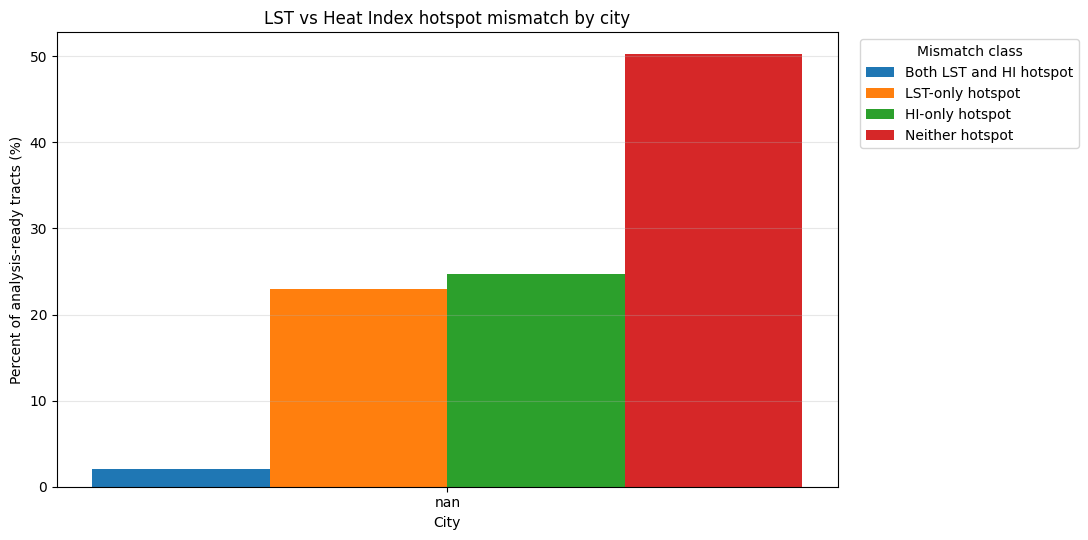


City summary fixed:


,city,n_ready,mean_lst_c,mean_hi_c,mean_hi_minus_lst,q75_lst_c,q75_hi_c,q75_hi_minus_lst,priority_n,priority_pct
0,nan,1339,49.881524,32.893764,-16.987761,52.139367,34.175943,-14.418203,485,36.22106



Mismatch counts fixed:


,city,mismatch_class,n,pct
0,nan,Both LST and HI hotspot,27,2.016430
1,nan,LST-only hotspot,308,23.002240
2,nan,HI-only hotspot,331,24.719940
3,nan,Neither hotspot,673,50.261389



Priority summary fixed:


,city,n_ready,priority_n,mean_lst_c,mean_hi_c,mean_hi_minus_lst,priority_pct
0,nan,1339,485,49.881524,32.893764,-16.987761,36.22106



Saved fixed files:
- outputs/pilot/alphaearth/three_city_analysis_ready_tracts_FIXED.csv
- outputs/pilot/alphaearth/three_city_city_summary_FIXED.csv
- outputs/pilot/alphaearth/three_city_mismatch_counts_FIXED.csv
- outputs/pilot/alphaearth/three_city_priority_summary_FIXED.csv
- outputs/pilot/alphaearth/three_city_mismatch_grouped_bar_FIXED.png

DONE. The data are not missing; the previous error was only from the final plotting step.


In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# FINAL FIX CELL
# Use saved / in-memory three_city table and make robust summary + figure
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth"
OUTDIR.mkdir(parents=True, exist_ok=True)

THREE_CITY_PATH = OUTDIR / "three_city_analysis_ready_tracts.csv"

# 1. Load three_city table
try:
    three_city_raw = three_city.copy()
    print("Using in-memory three_city table.")
except NameError:
    if not THREE_CITY_PATH.exists():
        raise FileNotFoundError(
            f"Cannot find {THREE_CITY_PATH}. "
            "Please rerun the previous big cell until it reaches the selected-city step."
        )
    three_city_raw = pd.read_csv(THREE_CITY_PATH)
    print("Loaded saved three_city table:", THREE_CITY_PATH)

print("Raw shape:", three_city_raw.shape)
print("Columns:", list(three_city_raw.columns))

# 2. Standardize required columns
required = ["city", "GEOID", "lst_c", "hi_c"]
missing = [c for c in required if c not in three_city_raw.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

three_city_raw["city"] = three_city_raw["city"].astype(str).str.strip()
three_city_raw["lst_c"] = pd.to_numeric(three_city_raw["lst_c"], errors="coerce")
three_city_raw["hi_c"] = pd.to_numeric(three_city_raw["hi_c"], errors="coerce")
three_city_raw["hi_minus_lst"] = three_city_raw["hi_c"] - three_city_raw["lst_c"]

three_city_raw = three_city_raw.dropna(subset=["city", "lst_c", "hi_c", "hi_minus_lst"]).copy()

print("Analysis-ready shape after cleaning:", three_city_raw.shape)
print("\nRows by city:")
display(three_city_raw["city"].value_counts().rename_axis("city").reset_index(name="n"))

if len(three_city_raw) == 0:
    raise ValueError("No analysis-ready rows after cleaning. This would mean LST/HI values are empty.")

# 3. Recompute hotspot classes city-by-city
frames = []
summary_rows = []

for city, g in three_city_raw.groupby("city", sort=False):
    g = g.copy()

    q75_lst = g["lst_c"].quantile(0.75)
    q75_hi = g["hi_c"].quantile(0.75)
    q75_gap = g["hi_minus_lst"].quantile(0.75)

    g["lst_hot_q75"] = g["lst_c"] >= q75_lst
    g["hi_hot_q75"] = g["hi_c"] >= q75_hi

    g["mismatch_class"] = np.select(
        [
            g["lst_hot_q75"] & g["hi_hot_q75"],
            g["lst_hot_q75"] & ~g["hi_hot_q75"],
            ~g["lst_hot_q75"] & g["hi_hot_q75"],
        ],
        [
            "Both LST and HI hotspot",
            "LST-only hotspot",
            "HI-only hotspot",
        ],
        default="Neither hotspot"
    )

    g["priority_flag"] = (
        (g["mismatch_class"] == "HI-only hotspot")
        | (g["hi_minus_lst"] >= q75_gap)
    )

    frames.append(g)

    summary_rows.append({
        "city": city,
        "n_ready": len(g),
        "mean_lst_c": g["lst_c"].mean(),
        "mean_hi_c": g["hi_c"].mean(),
        "mean_hi_minus_lst": g["hi_minus_lst"].mean(),
        "q75_lst_c": q75_lst,
        "q75_hi_c": q75_hi,
        "q75_hi_minus_lst": q75_gap,
        "priority_n": int(g["priority_flag"].sum()),
        "priority_pct": 100 * g["priority_flag"].mean(),
    })

three_city_fixed = pd.concat(frames, ignore_index=True)
city_summary_fixed = pd.DataFrame(summary_rows)

# 4. Build robust mismatch count table
class_order = [
    "Both LST and HI hotspot",
    "LST-only hotspot",
    "HI-only hotspot",
    "Neither hotspot",
]

preferred_city_order = ["houston", "phoenix", "las_vegas"]
city_order = [c for c in preferred_city_order if c in three_city_fixed["city"].unique()]
city_order += [c for c in three_city_fixed["city"].unique() if c not in city_order]

counts_wide = pd.crosstab(
    three_city_fixed["city"],
    three_city_fixed["mismatch_class"]
).reindex(index=city_order, columns=class_order, fill_value=0)

pct_wide = counts_wide.div(counts_wide.sum(axis=1), axis=0) * 100
pct_wide = pct_wide.fillna(0)

mismatch_counts_fixed = (
    counts_wide
    .stack()
    .reset_index()
    .rename(columns={0: "n"})
)

mismatch_counts_fixed["pct"] = (
    pct_wide
    .stack()
    .reset_index(drop=True)
)

priority_summary_fixed = (
    three_city_fixed
    .groupby("city", as_index=False)
    .agg(
        n_ready=("GEOID", "count"),
        priority_n=("priority_flag", "sum"),
        mean_lst_c=("lst_c", "mean"),
        mean_hi_c=("hi_c", "mean"),
        mean_hi_minus_lst=("hi_minus_lst", "mean"),
    )
)

priority_summary_fixed["priority_pct"] = (
    priority_summary_fixed["priority_n"] / priority_summary_fixed["n_ready"] * 100
)

# 5. Save fixed outputs
three_city_fixed.to_csv(OUTDIR / "three_city_analysis_ready_tracts_FIXED.csv", index=False)
city_summary_fixed.to_csv(OUTDIR / "three_city_city_summary_FIXED.csv", index=False)
mismatch_counts_fixed.to_csv(OUTDIR / "three_city_mismatch_counts_FIXED.csv", index=False)
priority_summary_fixed.to_csv(OUTDIR / "three_city_priority_summary_FIXED.csv", index=False)

# 6. Manual grouped bar chart, avoiding pandas plot bug
x = np.arange(len(city_order))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, cls in enumerate(class_order):
    offset = (i - 1.5) * width
    values = pct_wide[cls].values
    ax.bar(x + offset, values, width, label=cls)

ax.set_xticks(x)
ax.set_xticklabels(city_order)
ax.set_ylabel("Percent of analysis-ready tracts (%)")
ax.set_xlabel("City")
ax.set_title("LST vs Heat Index hotspot mismatch by city")
ax.legend(title="Mismatch class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = OUTDIR / "three_city_mismatch_grouped_bar_FIXED.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# 7. Display final tables
print("\nCity summary fixed:")
display(city_summary_fixed)

print("\nMismatch counts fixed:")
display(mismatch_counts_fixed)

print("\nPriority summary fixed:")
display(priority_summary_fixed)

print("\nSaved fixed files:")
for p in [
    OUTDIR / "three_city_analysis_ready_tracts_FIXED.csv",
    OUTDIR / "three_city_city_summary_FIXED.csv",
    OUTDIR / "three_city_mismatch_counts_FIXED.csv",
    OUTDIR / "three_city_priority_summary_FIXED.csv",
    fig_path,
]:
    print("-", p.relative_to(PROJECT))

print("\nDONE. The data are not missing; the previous error was only from the final plotting step.")

PROJECT = /Users/yufeizhou/Desktop/heat-exposure-compare
OUTDIR  = /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth
Selected source file exists: True

Selected sources loaded:


,city,selected_path,layer,score,rows_total,complete_n,geoid_col,lst_col,hi_col,reason
0,houston,/Users/yufeizhou/Desktop/heat-exposure-compare...,NaN,6549,654,549,GEOID,lst_summer_mean_c,hi_summer_mean_c,ok
1,phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...,NaN,5332,373,332,GEOID,lst_c,hi_c,ok
2,las_vegas,/Users/yufeizhou/Desktop/heat-exposure-compare...,NaN,3458,535,458,GEOID,lst_c,hi_c,ok



Reading houston:
  path     = /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/houston/houston_master_lst_hi_hotcompare.gpkg
  GEOID col= GEOID
  LST col  = lst_summer_mean_c
  HI col   = hi_summer_mean_c
  analysis-ready rows = 549

Reading phoenix:
  path     = /Users/yufeizhou/Desktop/heat-exposure-compare/data_processed/phoenix/phoenix_master_with_lst_hi_fixed.gpkg
  GEOID col= GEOID
  LST col  = lst_c
  HI col   = hi_c
  analysis-ready rows = 332

Reading las_vegas:
  path     = /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/working/las_vegas_heat_master_template.csv
  GEOID col= GEOID
  LST col  = lst_c
  HI col   = hi_c
  analysis-ready rows = 458

Rows by city after rebuild:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332


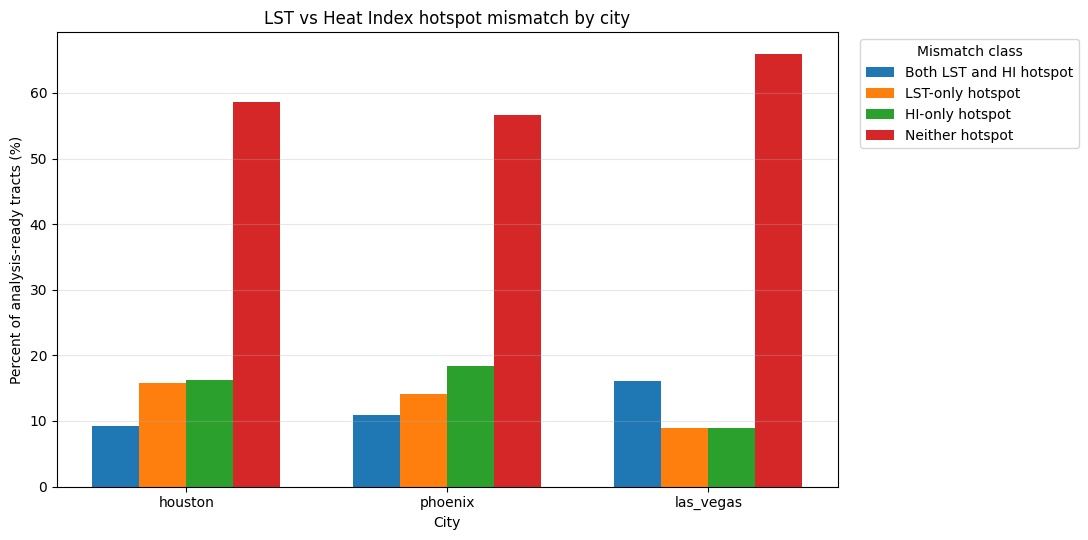


Source check FINAL:


,city,source_path,geoid_col,lst_col,hi_col,n_ready
0,houston,/Users/yufeizhou/Desktop/heat-exposure-compare...,GEOID,lst_summer_mean_c,hi_summer_mean_c,549
1,phoenix,/Users/yufeizhou/Desktop/heat-exposure-compare...,GEOID,lst_c,hi_c,332
2,las_vegas,/Users/yufeizhou/Desktop/heat-exposure-compare...,GEOID,lst_c,hi_c,458



City summary FINAL:


,city,n_ready,mean_lst_c,mean_hi_c,mean_hi_minus_lst,q75_lst_c,q75_hi_c,q75_hi_minus_lst,priority_n,priority_pct
0,houston,549,47.943522,34.154682,-13.788840,49.662024,34.198098,-12.750446,199,36.247723
1,phoenix,332,57.057313,33.287954,-23.769359,58.368204,33.685852,-22.714372,129,38.855422
2,las_vegas,458,47.002925,31.096568,-15.906357,48.001627,31.989976,-15.247753,128,27.947598



Mismatch counts FINAL:


,city,mismatch_class,n,pct
0,houston,Both LST and HI hotspot,51,9.289617
1,houston,LST-only hotspot,87,15.846995
2,houston,HI-only hotspot,89,16.211293
3,houston,Neither hotspot,322,58.652095
4,phoenix,Both LST and HI hotspot,36,10.843373
5,phoenix,LST-only hotspot,47,14.156627
6,phoenix,HI-only hotspot,61,18.373494
7,phoenix,Neither hotspot,188,56.626506
8,las_vegas,Both LST and HI hotspot,74,16.157205
9,las_vegas,LST-only hotspot,41,8.951965



Priority summary FINAL:


,city,n_ready,priority_n,mean_lst_c,mean_hi_c,mean_hi_minus_lst,priority_pct
0,houston,549,199,47.943522,34.154682,-13.788840,36.247723
1,las_vegas,458,128,47.002925,31.096568,-15.906357,27.947598
2,phoenix,332,129,57.057313,33.287954,-23.769359,38.855422



Saved FINAL files:
- outputs/pilot/alphaearth/three_city_source_check_FINAL.csv
- outputs/pilot/alphaearth/three_city_analysis_ready_tracts_FINAL.csv
- outputs/pilot/alphaearth/three_city_city_summary_FINAL.csv
- outputs/pilot/alphaearth/three_city_mismatch_counts_FINAL.csv
- outputs/pilot/alphaearth/three_city_priority_summary_FINAL.csv
- outputs/pilot/alphaearth/three_city_mismatch_grouped_bar_FINAL.png

DONE. Check that Rows by city shows houston, phoenix, and las_vegas, not nan.


In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# FINAL REBUILD CELL
# Rebuild three-city table using selected source files,
# fixing lost city labels.
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth"
OUTDIR.mkdir(parents=True, exist_ok=True)

SELECTED_PATH = OUTDIR / "three_city_selected_sources.csv"

print("PROJECT =", PROJECT)
print("OUTDIR  =", OUTDIR)
print("Selected source file exists:", SELECTED_PATH.exists())

if not SELECTED_PATH.exists():
    raise FileNotFoundError(
        "three_city_selected_sources.csv not found. "
        "Please rerun the previous big cell until it prints SELECTED for each city."
    )

selected_sources_final = pd.read_csv(SELECTED_PATH)
print("\nSelected sources loaded:")
display(selected_sources_final)

required_cols = ["city", "selected_path", "geoid_col", "lst_col", "hi_col"]
missing = [c for c in required_cols if c not in selected_sources_final.columns]
if missing:
    raise ValueError(f"Selected source table is missing columns: {missing}")

def resolve_path(raw_path):
    p = Path(str(raw_path))
    if p.exists():
        return p

    parts = list(p.parts)
    if "heat-exposure-compare" in parts:
        idx = parts.index("heat-exposure-compare")
        rel = Path(*parts[idx + 1:])
        p2 = PROJECT / rel
        if p2.exists():
            return p2

    p3 = PROJECT / str(raw_path)
    if p3.exists():
        return p3

    matches = list(PROJECT.rglob(p.name))
    matches = [m for m in matches if ".ipynb_checkpoints" not in str(m)]
    if len(matches) > 0:
        return matches[0]

    return p

def read_source(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix in [".gpkg", ".geojson", ".json", ".shp"]:
        return gpd.read_file(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported file type: {path}")

def coerce_num(s):
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    cleaned = (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(r"[^\d\.\-\+eE]", "", regex=True)
        .replace("", np.nan)
    )
    return pd.to_numeric(cleaned, errors="coerce")

# ------------------------------------------------------------
# 1. Rebuild analysis-ready tract table city by city
# ------------------------------------------------------------
frames = []
source_check_rows = []

for _, row in selected_sources_final.iterrows():
    city = str(row["city"]).strip()
    source_path = resolve_path(row["selected_path"])
    geoid_col = row["geoid_col"]
    lst_col = row["lst_col"]
    hi_col = row["hi_col"]

    print(f"\nReading {city}:")
    print("  path     =", source_path)
    print("  GEOID col=", geoid_col)
    print("  LST col  =", lst_col)
    print("  HI col   =", hi_col)

    if not source_path.exists():
        raise FileNotFoundError(f"Source file not found for {city}: {source_path}")

    df = read_source(source_path)

    for col in [geoid_col, lst_col, hi_col]:
        if col not in df.columns:
            raise ValueError(f"{city}: column '{col}' not found in {source_path}")

    # IMPORTANT: create DataFrame with same index first, so city label is preserved
    out = pd.DataFrame(index=df.index)
    out["city"] = city
    out["GEOID"] = (
        df[geoid_col]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )
    out["lst_c"] = coerce_num(df[lst_col])
    out["hi_c"] = coerce_num(df[hi_col])
    out["hi_minus_lst"] = out["hi_c"] - out["lst_c"]

    out = out.dropna(subset=["city", "GEOID", "lst_c", "hi_c", "hi_minus_lst"]).copy()

    print("  analysis-ready rows =", len(out))

    if len(out) == 0:
        raise ValueError(f"{city}: no analysis-ready rows after rebuilding")

    frames.append(out)

    source_check_rows.append({
        "city": city,
        "source_path": str(source_path),
        "geoid_col": geoid_col,
        "lst_col": lst_col,
        "hi_col": hi_col,
        "n_ready": len(out),
    })

three_city_final = pd.concat(frames, ignore_index=True)
source_check_final = pd.DataFrame(source_check_rows)

print("\nRows by city after rebuild:")
display(three_city_final["city"].value_counts().rename_axis("city").reset_index(name="n"))

# ------------------------------------------------------------
# 2. Recompute hotspot / mismatch classes within each city
# ------------------------------------------------------------
fixed_frames = []
summary_rows = []

for city, g in three_city_final.groupby("city", sort=False):
    g = g.copy()

    q75_lst = g["lst_c"].quantile(0.75)
    q75_hi = g["hi_c"].quantile(0.75)
    q75_gap = g["hi_minus_lst"].quantile(0.75)

    g["lst_hot_q75"] = g["lst_c"] >= q75_lst
    g["hi_hot_q75"] = g["hi_c"] >= q75_hi

    g["mismatch_class"] = np.select(
        [
            g["lst_hot_q75"] & g["hi_hot_q75"],
            g["lst_hot_q75"] & ~g["hi_hot_q75"],
            ~g["lst_hot_q75"] & g["hi_hot_q75"],
        ],
        [
            "Both LST and HI hotspot",
            "LST-only hotspot",
            "HI-only hotspot",
        ],
        default="Neither hotspot"
    )

    g["priority_flag"] = (
        (g["mismatch_class"] == "HI-only hotspot")
        | (g["hi_minus_lst"] >= q75_gap)
    )

    fixed_frames.append(g)

    summary_rows.append({
        "city": city,
        "n_ready": len(g),
        "mean_lst_c": g["lst_c"].mean(),
        "mean_hi_c": g["hi_c"].mean(),
        "mean_hi_minus_lst": g["hi_minus_lst"].mean(),
        "q75_lst_c": q75_lst,
        "q75_hi_c": q75_hi,
        "q75_hi_minus_lst": q75_gap,
        "priority_n": int(g["priority_flag"].sum()),
        "priority_pct": 100 * g["priority_flag"].mean(),
    })

three_city_final = pd.concat(fixed_frames, ignore_index=True)
city_summary_final = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 3. Build mismatch count / percent table
# ------------------------------------------------------------
class_order = [
    "Both LST and HI hotspot",
    "LST-only hotspot",
    "HI-only hotspot",
    "Neither hotspot",
]

preferred_city_order = ["houston", "phoenix", "las_vegas"]
actual_cities = list(three_city_final["city"].unique())
city_order = [c for c in preferred_city_order if c in actual_cities]
city_order += [c for c in actual_cities if c not in city_order]

counts_wide = pd.crosstab(
    three_city_final["city"],
    three_city_final["mismatch_class"]
).reindex(index=city_order, columns=class_order, fill_value=0)

pct_wide = counts_wide.div(counts_wide.sum(axis=1), axis=0) * 100
pct_wide = pct_wide.fillna(0)

mismatch_counts_final = (
    counts_wide
    .stack()
    .reset_index()
    .rename(columns={0: "n"})
)

mismatch_counts_final["pct"] = (
    pct_wide
    .stack()
    .reset_index(drop=True)
)

priority_summary_final = (
    three_city_final
    .groupby("city", as_index=False)
    .agg(
        n_ready=("GEOID", "count"),
        priority_n=("priority_flag", "sum"),
        mean_lst_c=("lst_c", "mean"),
        mean_hi_c=("hi_c", "mean"),
        mean_hi_minus_lst=("hi_minus_lst", "mean"),
    )
)

priority_summary_final["priority_pct"] = (
    priority_summary_final["priority_n"] / priority_summary_final["n_ready"] * 100
)

# ------------------------------------------------------------
# 4. Save final outputs
# ------------------------------------------------------------
source_check_final.to_csv(OUTDIR / "three_city_source_check_FINAL.csv", index=False)
three_city_final.to_csv(OUTDIR / "three_city_analysis_ready_tracts_FINAL.csv", index=False)
city_summary_final.to_csv(OUTDIR / "three_city_city_summary_FINAL.csv", index=False)
mismatch_counts_final.to_csv(OUTDIR / "three_city_mismatch_counts_FINAL.csv", index=False)
priority_summary_final.to_csv(OUTDIR / "three_city_priority_summary_FINAL.csv", index=False)

# ------------------------------------------------------------
# 5. Final grouped bar figure
# ------------------------------------------------------------
x = np.arange(len(city_order))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, cls in enumerate(class_order):
    offset = (i - 1.5) * width
    values = pct_wide[cls].values
    ax.bar(x + offset, values, width, label=cls)

ax.set_xticks(x)
ax.set_xticklabels(city_order)
ax.set_ylabel("Percent of analysis-ready tracts (%)")
ax.set_xlabel("City")
ax.set_title("LST vs Heat Index hotspot mismatch by city")
ax.legend(title="Mismatch class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

fig_path = OUTDIR / "three_city_mismatch_grouped_bar_FINAL.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Display final results
# ------------------------------------------------------------
print("\nSource check FINAL:")
display(source_check_final)

print("\nCity summary FINAL:")
display(city_summary_final)

print("\nMismatch counts FINAL:")
display(mismatch_counts_final)

print("\nPriority summary FINAL:")
display(priority_summary_final)

print("\nSaved FINAL files:")
for p in [
    OUTDIR / "three_city_source_check_FINAL.csv",
    OUTDIR / "three_city_analysis_ready_tracts_FINAL.csv",
    OUTDIR / "three_city_city_summary_FINAL.csv",
    OUTDIR / "three_city_mismatch_counts_FINAL.csv",
    OUTDIR / "three_city_priority_summary_FINAL.csv",
    fig_path,
]:
    print("-", p.relative_to(PROJECT))

print("\nDONE. Check that Rows by city shows houston, phoenix, and las_vegas, not nan.")

Paper city summary table:


,city,n_ready,mean_lst_c,mean_hi_c,mean_hi_minus_lst,q75_lst_c,q75_hi_c,priority_n,priority_pct
0,houston,549,47.94,34.15,-13.79,49.66,34.20,199,36.25
1,phoenix,332,57.06,33.29,-23.77,58.37,33.69,129,38.86
2,las_vegas,458,47.00,31.10,-15.91,48.00,31.99,128,27.95


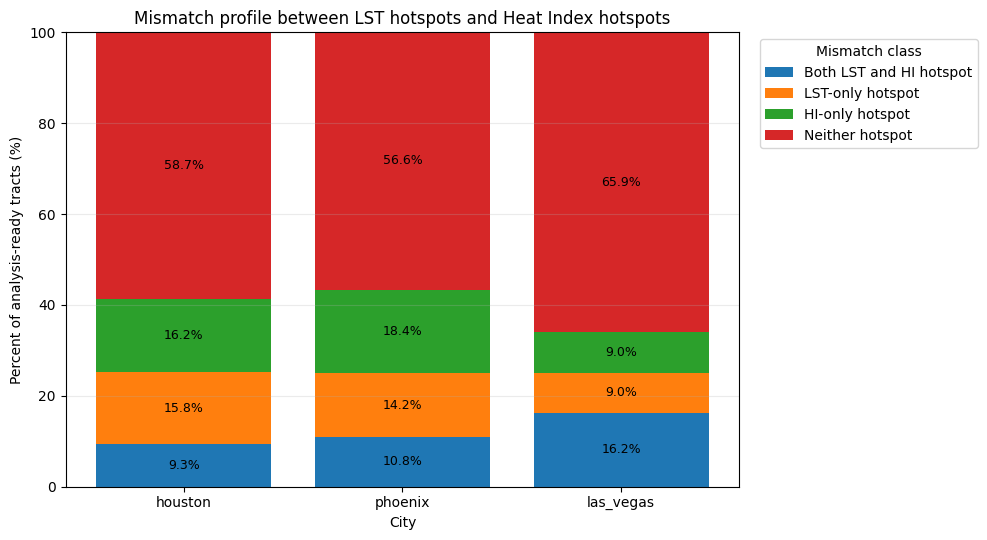

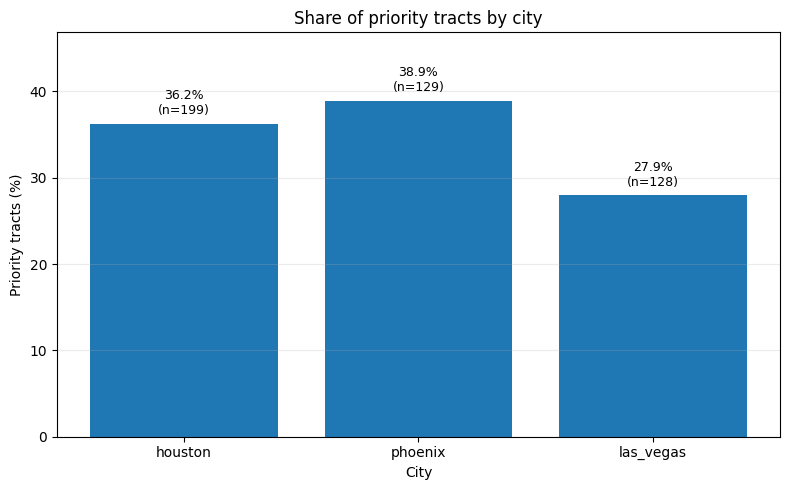

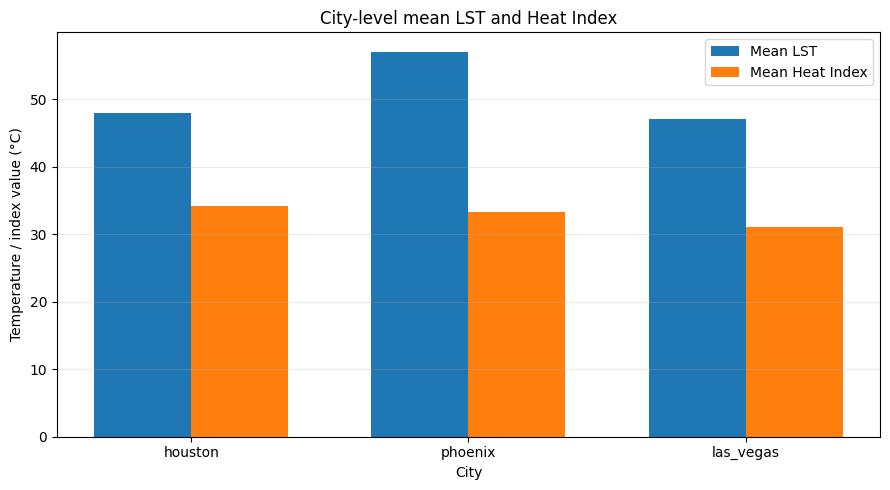


Paper interpretation bullets:
- Phoenix shows the highest mean LST (57.06 °C), while Houston shows the highest mean Heat Index (34.15 °C). This suggests that surface heat intensity and apparent heat exposure do not rank cities in the same way.
- Phoenix has the highest share of priority tracts (38.86%), followed by Houston (36.25%) and Las Vegas (27.95%). This indicates that the strongest mismatch or high Heat Index concern is not evenly distributed across the three cities.
- Las Vegas has the largest overlap between LST and Heat Index hotspots (16.16% Both-hotspot tracts), while Houston and Phoenix show higher HI-only hotspot shares (16.21% and 18.37%). This may indicate different city-specific mechanisms of heat exposure.
- For the next step, the most important task is to map these mismatch classes spatially. The table-level results show city-level differences, but maps are needed to identify whether HI-only or LST-only tracts cluster in specific urban zones.

Saved paper-level outp

In [47]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# PAPER-LEVEL THREE-CITY INTERPRETATION FIGURES
# Builds cleaner summary tables and figures from FINAL outputs
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth"
FIGDIR = OUTDIR / "paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TRACTS = OUTDIR / "three_city_analysis_ready_tracts_FINAL.csv"
CITY_SUMMARY = OUTDIR / "three_city_city_summary_FINAL.csv"
MISMATCH = OUTDIR / "three_city_mismatch_counts_FINAL.csv"
PRIORITY = OUTDIR / "three_city_priority_summary_FINAL.csv"

three_city = pd.read_csv(TRACTS)
city_summary = pd.read_csv(CITY_SUMMARY)
mismatch_counts = pd.read_csv(MISMATCH)
priority_summary = pd.read_csv(PRIORITY)

city_order = ["houston", "phoenix", "las_vegas"]
class_order = [
    "Both LST and HI hotspot",
    "LST-only hotspot",
    "HI-only hotspot",
    "Neither hotspot",
]

# Make sure order is stable
three_city["city"] = pd.Categorical(three_city["city"], categories=city_order, ordered=True)
city_summary["city"] = pd.Categorical(city_summary["city"], categories=city_order, ordered=True)
mismatch_counts["city"] = pd.Categorical(mismatch_counts["city"], categories=city_order, ordered=True)
mismatch_counts["mismatch_class"] = pd.Categorical(
    mismatch_counts["mismatch_class"],
    categories=class_order,
    ordered=True
)

city_summary = city_summary.sort_values("city")
priority_summary["city"] = pd.Categorical(priority_summary["city"], categories=city_order, ordered=True)
priority_summary = priority_summary.sort_values("city")
mismatch_counts = mismatch_counts.sort_values(["city", "mismatch_class"])

# ------------------------------------------------------------
# 1. Clean table for paper / PPT
# ------------------------------------------------------------
paper_city_table = city_summary.copy()

for col in [
    "mean_lst_c", "mean_hi_c", "mean_hi_minus_lst",
    "q75_lst_c", "q75_hi_c", "q75_hi_minus_lst",
    "priority_pct"
]:
    if col in paper_city_table.columns:
        paper_city_table[col] = paper_city_table[col].round(2)

paper_city_table = paper_city_table[
    [
        "city",
        "n_ready",
        "mean_lst_c",
        "mean_hi_c",
        "mean_hi_minus_lst",
        "q75_lst_c",
        "q75_hi_c",
        "priority_n",
        "priority_pct",
    ]
]

paper_city_table.to_csv(FIGDIR / "paper_city_summary_table.csv", index=False)

print("Paper city summary table:")
display(paper_city_table)

# ------------------------------------------------------------
# 2. Stacked mismatch profile bar
# ------------------------------------------------------------
pct_wide = (
    mismatch_counts
    .pivot(index="city", columns="mismatch_class", values="pct")
    .reindex(index=city_order, columns=class_order)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

bottom = np.zeros(len(pct_wide))

for cls in class_order:
    values = pct_wide[cls].values
    ax.bar(pct_wide.index.astype(str), values, bottom=bottom, label=cls)

    # Add labels only for meaningful segments
    for i, v in enumerate(values):
        if v >= 7:
            ax.text(
                i,
                bottom[i] + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
            )
    bottom += values

ax.set_ylabel("Percent of analysis-ready tracts (%)")
ax.set_xlabel("City")
ax.set_title("Mismatch profile between LST hotspots and Heat Index hotspots")
ax.legend(title="Mismatch class", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGDIR / "paper_stacked_mismatch_profile.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. Priority tract percentage comparison
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

priority_plot = priority_summary.copy()
priority_plot = priority_plot.sort_values("city")

ax.bar(priority_plot["city"].astype(str), priority_plot["priority_pct"])

for i, row in priority_plot.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["priority_pct"] + 0.8,
        f"{row['priority_pct']:.1f}%\n(n={int(row['priority_n'])})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylabel("Priority tracts (%)")
ax.set_xlabel("City")
ax.set_title("Share of priority tracts by city")
ax.set_ylim(0, max(priority_plot["priority_pct"]) + 8)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGDIR / "paper_priority_tracts_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Mean LST vs mean Heat Index comparison
# ------------------------------------------------------------
x = np.arange(len(city_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

summary_plot = city_summary.set_index("city").reindex(city_order)

ax.bar(x - width/2, summary_plot["mean_lst_c"], width, label="Mean LST")
ax.bar(x + width/2, summary_plot["mean_hi_c"], width, label="Mean Heat Index")

ax.set_xticks(x)
ax.set_xticklabels(city_order)
ax.set_ylabel("Temperature / index value (°C)")
ax.set_xlabel("City")
ax.set_title("City-level mean LST and Heat Index")
ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGDIR / "paper_mean_lst_vs_hi_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Paper-style interpretation bullets
# ------------------------------------------------------------
h = paper_city_table.set_index("city")

interpretation_lines = []

lst_rank = h["mean_lst_c"].sort_values(ascending=False)
hi_rank = h["mean_hi_c"].sort_values(ascending=False)
priority_rank = h["priority_pct"].sort_values(ascending=False)

interpretation_lines.append(
    f"Phoenix shows the highest mean LST ({h.loc['phoenix', 'mean_lst_c']:.2f} °C), "
    f"while Houston shows the highest mean Heat Index ({h.loc['houston', 'mean_hi_c']:.2f} °C). "
    "This suggests that surface heat intensity and apparent heat exposure do not rank cities in the same way."
)

interpretation_lines.append(
    f"Phoenix has the highest share of priority tracts ({h.loc['phoenix', 'priority_pct']:.2f}%), "
    f"followed by Houston ({h.loc['houston', 'priority_pct']:.2f}%) and Las Vegas ({h.loc['las_vegas', 'priority_pct']:.2f}%). "
    "This indicates that the strongest mismatch or high Heat Index concern is not evenly distributed across the three cities."
)

lv_both = mismatch_counts[
    (mismatch_counts["city"].astype(str) == "las_vegas") &
    (mismatch_counts["mismatch_class"].astype(str) == "Both LST and HI hotspot")
]["pct"].iloc[0]

hou_hi_only = mismatch_counts[
    (mismatch_counts["city"].astype(str) == "houston") &
    (mismatch_counts["mismatch_class"].astype(str) == "HI-only hotspot")
]["pct"].iloc[0]

phx_hi_only = mismatch_counts[
    (mismatch_counts["city"].astype(str) == "phoenix") &
    (mismatch_counts["mismatch_class"].astype(str) == "HI-only hotspot")
]["pct"].iloc[0]

interpretation_lines.append(
    f"Las Vegas has the largest overlap between LST and Heat Index hotspots "
    f"({lv_both:.2f}% Both-hotspot tracts), while Houston and Phoenix show higher HI-only hotspot shares "
    f"({hou_hi_only:.2f}% and {phx_hi_only:.2f}%). "
    "This may indicate different city-specific mechanisms of heat exposure."
)

interpretation_lines.append(
    "For the next step, the most important task is to map these mismatch classes spatially. "
    "The table-level results show city-level differences, but maps are needed to identify whether HI-only or LST-only tracts cluster in specific urban zones."
)

interp_path = FIGDIR / "paper_interpretation_bullets.txt"
with open(interp_path, "w") as f:
    for line in interpretation_lines:
        f.write("- " + line + "\n")

print("\nPaper interpretation bullets:")
for line in interpretation_lines:
    print("- " + line)

print("\nSaved paper-level outputs:")
for p in sorted(FIGDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

Input rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Relative extremeness table preview:


,city,GEOID,lst_c,hi_c,lst_z_city,hi_z_city,hi_minus_lst_z,mismatch_class
0,houston,48201421101,49.259128,34.198098,0.498644,0.559706,0.061062,HI-only hotspot
1,houston,48201423301,48.109522,34.199077,0.062918,0.572327,0.509409,HI-only hotspot
2,houston,48201453401,50.612499,34.199077,1.011603,0.572327,-0.439276,Both LST and HI hotspot
3,houston,48201331100,50.163449,34.183054,0.841403,0.365768,-0.475634,LST-only hotspot
4,houston,48201331200,46.407487,34.183054,-0.582192,0.365768,0.947961,Neither hotspot


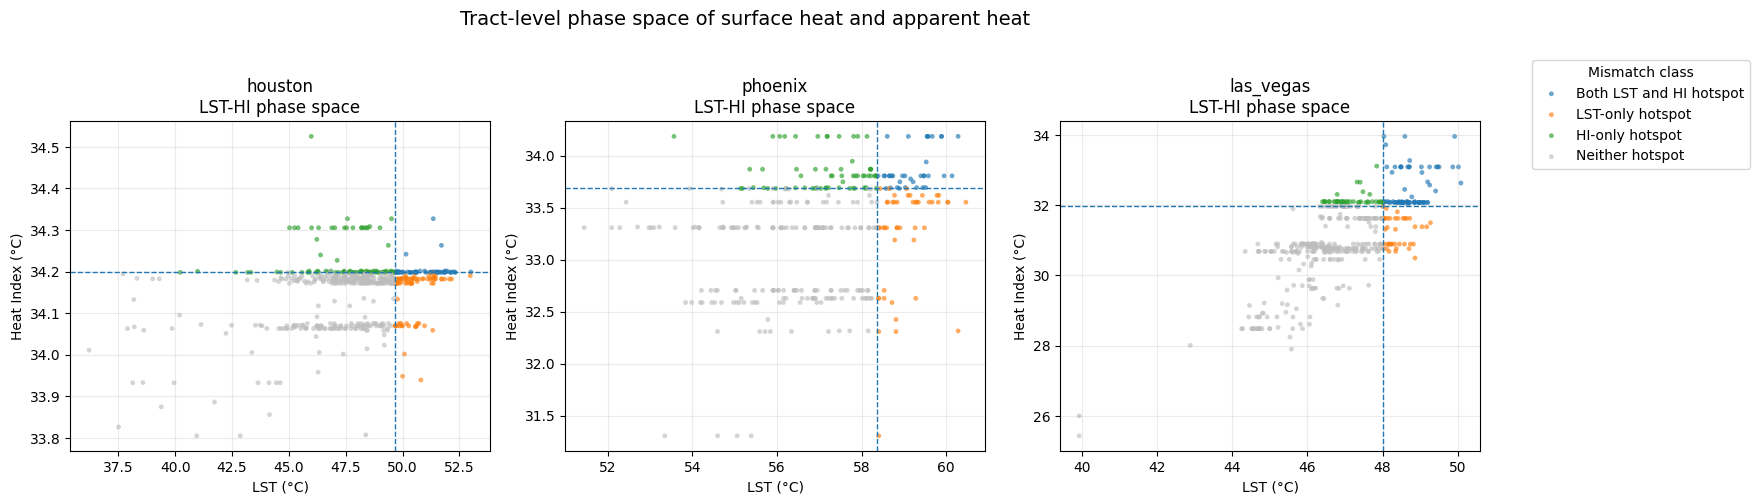

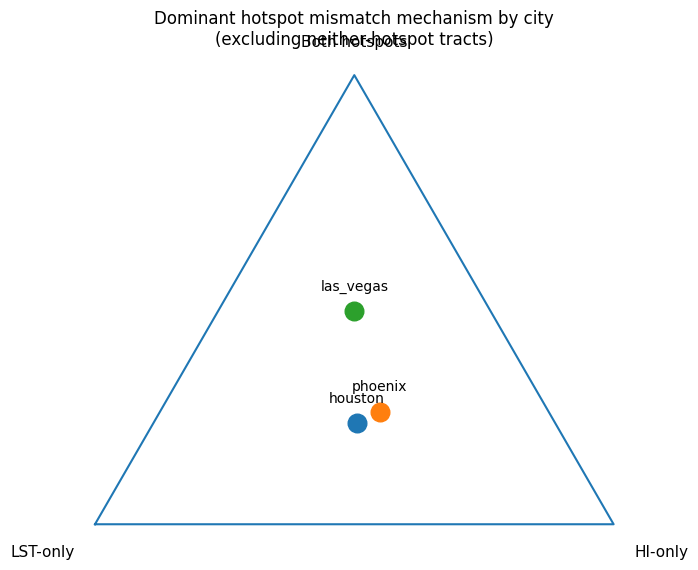


Mismatch triangle table:


,city,both_raw_pct,lst_only_raw_pct,hi_only_raw_pct,both_share_among_hot_related,lst_only_share_among_hot_related,hi_only_share_among_hot_related,hot_related_pct
0,houston,9.289617,15.846995,16.211293,0.224670,0.383260,0.392070,41.347905
1,phoenix,10.843373,14.156627,18.373494,0.250000,0.326389,0.423611,43.373494
2,las_vegas,16.157205,8.951965,8.951965,0.474359,0.262821,0.262821,34.061135


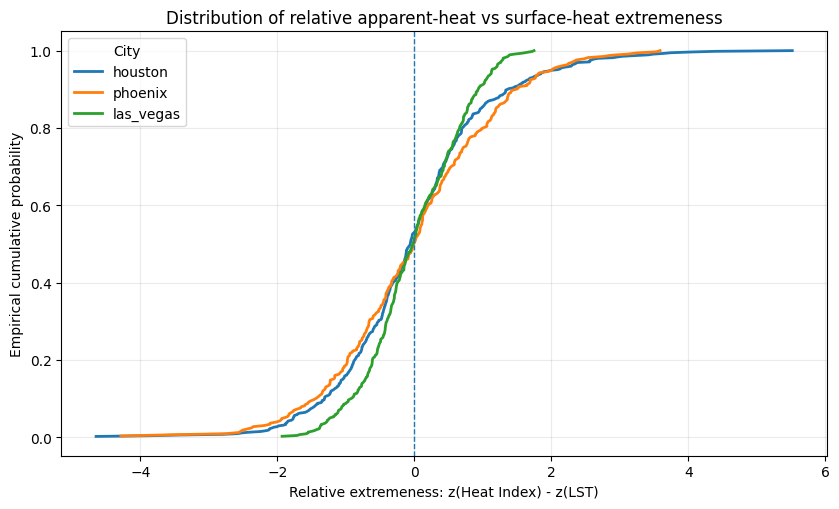


Relative extremeness ECDF summary:


,city,n,median_hi_minus_lst_z,pct_hi_more_extreme_than_lst,pct_strong_hi_shift_gt_0_5,pct_strong_lst_shift_lt_minus_0_5
0,houston,549,-0.057946,47.176685,26.775956,30.236794
1,phoenix,332,-0.003689,50.000000,31.024096,33.132530
2,las_vegas,458,-0.014566,48.908297,26.200873,24.454148


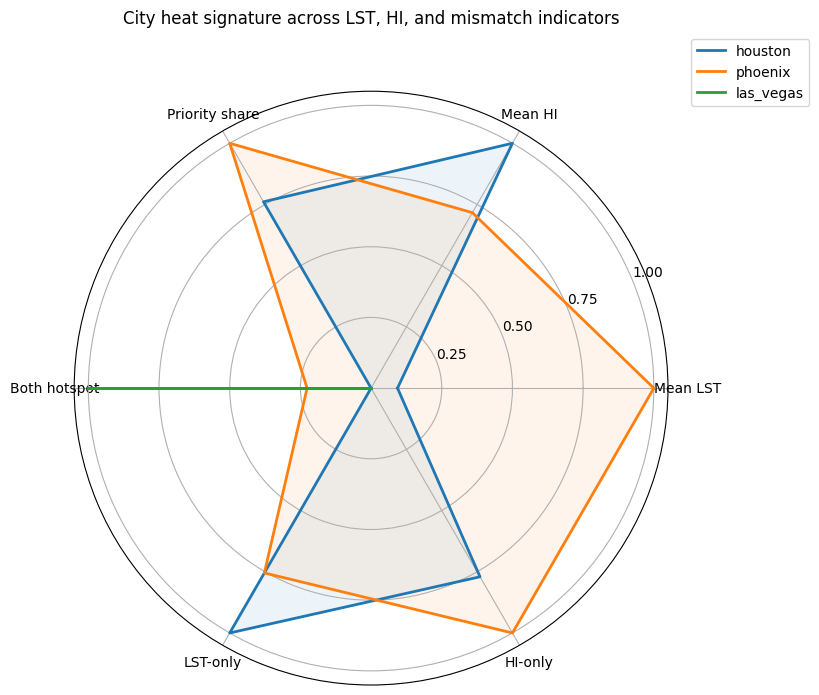


Saved non-bar paper figures:
- outputs/pilot/alphaearth/paper_nonbar_figures/city_heat_signature_radar_values.csv
- outputs/pilot/alphaearth/paper_nonbar_figures/fig_A_lst_hi_phase_space.png
- outputs/pilot/alphaearth/paper_nonbar_figures/fig_B_mismatch_triangle.png
- outputs/pilot/alphaearth/paper_nonbar_figures/fig_C_relative_extremeness_ecdf.png
- outputs/pilot/alphaearth/paper_nonbar_figures/fig_D_city_heat_signature_radar.png
- outputs/pilot/alphaearth/paper_nonbar_figures/mismatch_triangle_coordinates.csv
- outputs/pilot/alphaearth/paper_nonbar_figures/nonbar_figure_interpretation_notes.txt
- outputs/pilot/alphaearth/paper_nonbar_figures/relative_extremeness_ecdf_summary.csv
- outputs/pilot/alphaearth/paper_nonbar_figures/three_city_relative_extremeness_table.csv

Interpretation notes:
- Figure A (phase space) should be used to show that tract-level surface heat and apparent heat do not occupy the same distribution across cities. Phoenix is expected to sit further toward high LS

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# NON-BAR PAPER FIGURES
# Goal: move beyond simple bar charts toward paper-level interpretation
# Inputs: FINAL outputs from previous step
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth"
FIGDIR = OUTDIR / "paper_nonbar_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

TRACTS = OUTDIR / "three_city_analysis_ready_tracts_FINAL.csv"
CITY_SUMMARY = OUTDIR / "three_city_city_summary_FINAL.csv"
MISMATCH = OUTDIR / "three_city_mismatch_counts_FINAL.csv"
PRIORITY = OUTDIR / "three_city_priority_summary_FINAL.csv"

three_city = pd.read_csv(TRACTS)
city_summary = pd.read_csv(CITY_SUMMARY)
mismatch_counts = pd.read_csv(MISMATCH)
priority_summary = pd.read_csv(PRIORITY)

city_order = ["houston", "phoenix", "las_vegas"]
class_order = [
    "Both LST and HI hotspot",
    "LST-only hotspot",
    "HI-only hotspot",
    "Neither hotspot",
]

three_city["city"] = three_city["city"].astype(str)
mismatch_counts["city"] = mismatch_counts["city"].astype(str)
city_summary["city"] = city_summary["city"].astype(str)
priority_summary["city"] = priority_summary["city"].astype(str)

# Keep only expected cities
three_city = three_city[three_city["city"].isin(city_order)].copy()
city_summary = city_summary[city_summary["city"].isin(city_order)].copy()
mismatch_counts = mismatch_counts[mismatch_counts["city"].isin(city_order)].copy()
priority_summary = priority_summary[priority_summary["city"].isin(city_order)].copy()

print("Input rows by city:")
display(three_city["city"].value_counts().rename_axis("city").reset_index(name="n"))

# ============================================================
# 1. Add city-standardized relative extremeness
# z_HI - z_LST: positive means HI is more extreme than LST within the same city
# ============================================================

frames = []

for city, g in three_city.groupby("city", sort=False):
    g = g.copy()

    lst_mean = g["lst_c"].mean()
    lst_std = g["lst_c"].std(ddof=0)
    hi_mean = g["hi_c"].mean()
    hi_std = g["hi_c"].std(ddof=0)

    if lst_std == 0:
        lst_std = np.nan
    if hi_std == 0:
        hi_std = np.nan

    g["lst_z_city"] = (g["lst_c"] - lst_mean) / lst_std
    g["hi_z_city"] = (g["hi_c"] - hi_mean) / hi_std
    g["hi_minus_lst_z"] = g["hi_z_city"] - g["lst_z_city"]

    frames.append(g)

three_city_z = pd.concat(frames, ignore_index=True)

three_city_z.to_csv(FIGDIR / "three_city_relative_extremeness_table.csv", index=False)

print("\nRelative extremeness table preview:")
display(three_city_z[["city", "GEOID", "lst_c", "hi_c", "lst_z_city", "hi_z_city", "hi_minus_lst_z", "mismatch_class"]].head())

# ============================================================
# 2. Figure A: LST-HI phase space
# Each tract is one point. This shows whether cities occupy different heat regimes.
# ============================================================

class_colors = {
    "Both LST and HI hotspot": "#1f77b4",
    "LST-only hotspot": "#ff7f0e",
    "HI-only hotspot": "#2ca02c",
    "Neither hotspot": "#bdbdbd",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=False, sharey=False)

for ax, city in zip(axes, city_order):
    g = three_city_z[three_city_z["city"] == city].copy()

    q75_lst = g["lst_c"].quantile(0.75)
    q75_hi = g["hi_c"].quantile(0.75)

    for cls in class_order:
        sub = g[g["mismatch_class"] == cls]
        ax.scatter(
            sub["lst_c"],
            sub["hi_c"],
            s=12,
            alpha=0.65,
            label=cls,
            color=class_colors.get(cls, None),
            edgecolor="none",
        )

    ax.axvline(q75_lst, linestyle="--", linewidth=1)
    ax.axhline(q75_hi, linestyle="--", linewidth=1)

    ax.set_title(f"{city}\nLST-HI phase space")
    ax.set_xlabel("LST (°C)")
    ax.set_ylabel("Heat Index (°C)")
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Mismatch class", bbox_to_anchor=(1.02, 0.95), loc="upper left")

fig.suptitle("Tract-level phase space of surface heat and apparent heat", y=1.04, fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_A_lst_hi_phase_space.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 3. Figure B: mismatch triangle
# Uses only hotspot-related tracts: Both, LST-only, HI-only.
# This shows the dominant mismatch mechanism for each city.
# ============================================================

tri_rows = []

for city in city_order:
    m = mismatch_counts[mismatch_counts["city"] == city].copy()

    both = m.loc[m["mismatch_class"] == "Both LST and HI hotspot", "pct"].sum()
    lst_only = m.loc[m["mismatch_class"] == "LST-only hotspot", "pct"].sum()
    hi_only = m.loc[m["mismatch_class"] == "HI-only hotspot", "pct"].sum()

    total_hot_related = both + lst_only + hi_only

    tri_rows.append({
        "city": city,
        "both_raw_pct": both,
        "lst_only_raw_pct": lst_only,
        "hi_only_raw_pct": hi_only,
        "both_share_among_hot_related": both / total_hot_related if total_hot_related > 0 else np.nan,
        "lst_only_share_among_hot_related": lst_only / total_hot_related if total_hot_related > 0 else np.nan,
        "hi_only_share_among_hot_related": hi_only / total_hot_related if total_hot_related > 0 else np.nan,
        "hot_related_pct": total_hot_related,
    })

tri = pd.DataFrame(tri_rows)
tri.to_csv(FIGDIR / "mismatch_triangle_coordinates.csv", index=False)

def ternary_to_xy(a, b, c):
    """
    a = Both, b = LST-only, c = HI-only
    vertices:
      Both     -> (0.5, sqrt(3)/2)
      LST-only -> (0, 0)
      HI-only  -> (1, 0)
    """
    x = 0.5 * a + 0.0 * b + 1.0 * c
    y = (np.sqrt(3) / 2) * a
    return x, y

fig, ax = plt.subplots(figsize=(7, 6))

# triangle outline
triangle_x = [0, 1, 0.5, 0]
triangle_y = [0, 0, np.sqrt(3)/2, 0]
ax.plot(triangle_x, triangle_y, linewidth=1.5)

# vertex labels
ax.text(0.5, np.sqrt(3)/2 + 0.05, "Both hotspots", ha="center", va="bottom", fontsize=11)
ax.text(-0.04, -0.04, "LST-only", ha="right", va="top", fontsize=11)
ax.text(1.04, -0.04, "HI-only", ha="left", va="top", fontsize=11)

for _, row in tri.iterrows():
    a = row["both_share_among_hot_related"]
    b = row["lst_only_share_among_hot_related"]
    c = row["hi_only_share_among_hot_related"]

    x, y = ternary_to_xy(a, b, c)

    ax.scatter(x, y, s=180)
    ax.text(x, y + 0.035, row["city"], ha="center", va="bottom", fontsize=10)

ax.set_title("Dominant hotspot mismatch mechanism by city\n(excluding neither-hotspot tracts)")
ax.set_aspect("equal")
ax.axis("off")

fig.tight_layout()
fig.savefig(FIGDIR / "fig_B_mismatch_triangle.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMismatch triangle table:")
display(tri)

# ============================================================
# 4. Figure C: ECDF of relative extremeness
# x = z(HI) - z(LST)
# positive side means a tract is more extreme in HI than in LST relative to its own city.
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ecdf_summary_rows = []

for city in city_order:
    g = three_city_z[three_city_z["city"] == city].dropna(subset=["hi_minus_lst_z"]).copy()
    values = np.sort(g["hi_minus_lst_z"].values)
    y = np.arange(1, len(values) + 1) / len(values)

    ax.plot(values, y, linewidth=2, label=city)

    ecdf_summary_rows.append({
        "city": city,
        "n": len(values),
        "median_hi_minus_lst_z": np.median(values),
        "pct_hi_more_extreme_than_lst": 100 * np.mean(values > 0),
        "pct_strong_hi_shift_gt_0_5": 100 * np.mean(values > 0.5),
        "pct_strong_lst_shift_lt_minus_0_5": 100 * np.mean(values < -0.5),
    })

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Relative extremeness: z(Heat Index) - z(LST)")
ax.set_ylabel("Empirical cumulative probability")
ax.set_title("Distribution of relative apparent-heat vs surface-heat extremeness")
ax.legend(title="City")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGDIR / "fig_C_relative_extremeness_ecdf.png", dpi=300, bbox_inches="tight")
plt.show()

ecdf_summary = pd.DataFrame(ecdf_summary_rows)
ecdf_summary.to_csv(FIGDIR / "relative_extremeness_ecdf_summary.csv", index=False)

print("\nRelative extremeness ECDF summary:")
display(ecdf_summary)

# ============================================================
# 5. Figure D: City heat signature radar plot
# This is a compact "city profile" figure, better than simple bars.
# ============================================================

# Prepare normalized indicators, all scaled 0-1 across the three cities
radar_base = city_summary[["city", "mean_lst_c", "mean_hi_c", "priority_pct"]].copy()

both_pct = mismatch_counts[mismatch_counts["mismatch_class"] == "Both LST and HI hotspot"][["city", "pct"]].rename(columns={"pct": "both_hotspot_pct"})
lst_only_pct = mismatch_counts[mismatch_counts["mismatch_class"] == "LST-only hotspot"][["city", "pct"]].rename(columns={"pct": "lst_only_pct"})
hi_only_pct = mismatch_counts[mismatch_counts["mismatch_class"] == "HI-only hotspot"][["city", "pct"]].rename(columns={"pct": "hi_only_pct"})

radar_base = radar_base.merge(both_pct, on="city", how="left")
radar_base = radar_base.merge(lst_only_pct, on="city", how="left")
radar_base = radar_base.merge(hi_only_pct, on="city", how="left")
radar_base = radar_base.set_index("city").reindex(city_order).reset_index()

radar_vars = [
    "mean_lst_c",
    "mean_hi_c",
    "priority_pct",
    "both_hotspot_pct",
    "lst_only_pct",
    "hi_only_pct",
]

radar_labels = [
    "Mean LST",
    "Mean HI",
    "Priority share",
    "Both hotspot",
    "LST-only",
    "HI-only",
]

radar_norm = radar_base.copy()

for col in radar_vars:
    mn = radar_norm[col].min()
    mx = radar_norm[col].max()

    if mx == mn:
        radar_norm[col + "_norm"] = 0.5
    else:
        radar_norm[col + "_norm"] = (radar_norm[col] - mn) / (mx - mn)

radar_norm.to_csv(FIGDIR / "city_heat_signature_radar_values.csv", index=False)

angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 7))
ax = plt.subplot(111, polar=True)

for city in city_order:
    row = radar_norm[radar_norm["city"] == city].iloc[0]
    values = [row[col + "_norm"] for col in radar_vars]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=city)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"])
ax.set_title("City heat signature across LST, HI, and mismatch indicators", y=1.10)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

fig.tight_layout()
fig.savefig(FIGDIR / "fig_D_city_heat_signature_radar.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. Generate stronger paper interpretation notes
# ============================================================

notes = []

notes.append(
    "Figure A (phase space) should be used to show that tract-level surface heat and apparent heat do not occupy the same distribution across cities. "
    "Phoenix is expected to sit further toward high LST, while Houston retains relatively high Heat Index despite lower mean LST."
)

notes.append(
    "Figure B (mismatch triangle) reframes the result as a mechanism comparison rather than a count comparison. "
    "Las Vegas appears more overlap-dominated, while Houston and Phoenix retain stronger LST-only / HI-only separation."
)

notes.append(
    "Figure C (relative extremeness ECDF) is the strongest non-map diagnostic figure. "
    "It compares whether tracts become more extreme under Heat Index than under LST after standardizing within each city."
)

notes.append(
    "Figure D (radar profile) can be used as a compact city typology figure. "
    "It helps motivate categories such as surface-heat dominated, apparent-heat sensitive, and overlap-dominated cities."
)

notes.append(
    "These figures should not replace maps. They should come before maps: first establish cross-city mechanisms, then use maps to show where those mechanisms occur spatially."
)

with open(FIGDIR / "nonbar_figure_interpretation_notes.txt", "w") as f:
    for note in notes:
        f.write("- " + note + "\n")

print("\nSaved non-bar paper figures:")
for p in sorted(FIGDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nInterpretation notes:")
for note in notes:
    print("- " + note)

PROJECT = /Users/yufeizhou/Desktop/heat-exposure-compare
GISDIR  = /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/paper_gis_figures
TRACTS_FINAL exists: True
SELECTED_FINAL exists: True

Analytical table rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Finding geometry for Houston...

Selected geometry for houston:
  path    = /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/houston/tract_2025/tl_2025_48_tract.shp
  geoid   = GEOID
  overlap = 549
  merged map rows = 549

Finding geometry for Phoenix...

Selected geometry for phoenix:
  path    = /Users/yufeizhou/Desktop/heat-exposure-compare/data_raw/phoenix/tract_2025/tl_2025_04_tract.shp
  geoid   = GEOID
  overlap = 332
  merged map rows = 332

Finding geometry for Las Vegas...

Selected geometry for las_vegas:
  path    = /Users/yufeizhou/Desktop/heat-exposure-compare/city_intake/las_vegas/raw/tract_2025/tl_2025_32_tract.shp
  geoid   = GEOID
  overlap = 458
  merged map rows = 458

Mapped rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Saved GIS-ready files:
- outputs/pilot/alphaearth/paper_gis_figures/three_city_lstadaptive_heat_index_mismatch_GIS_READY.gpkg
- outputs/pilot/alphaearth/paper_gis_figures/three_city_lstadaptive_heat_index_mismatch_GIS_READY.geojson


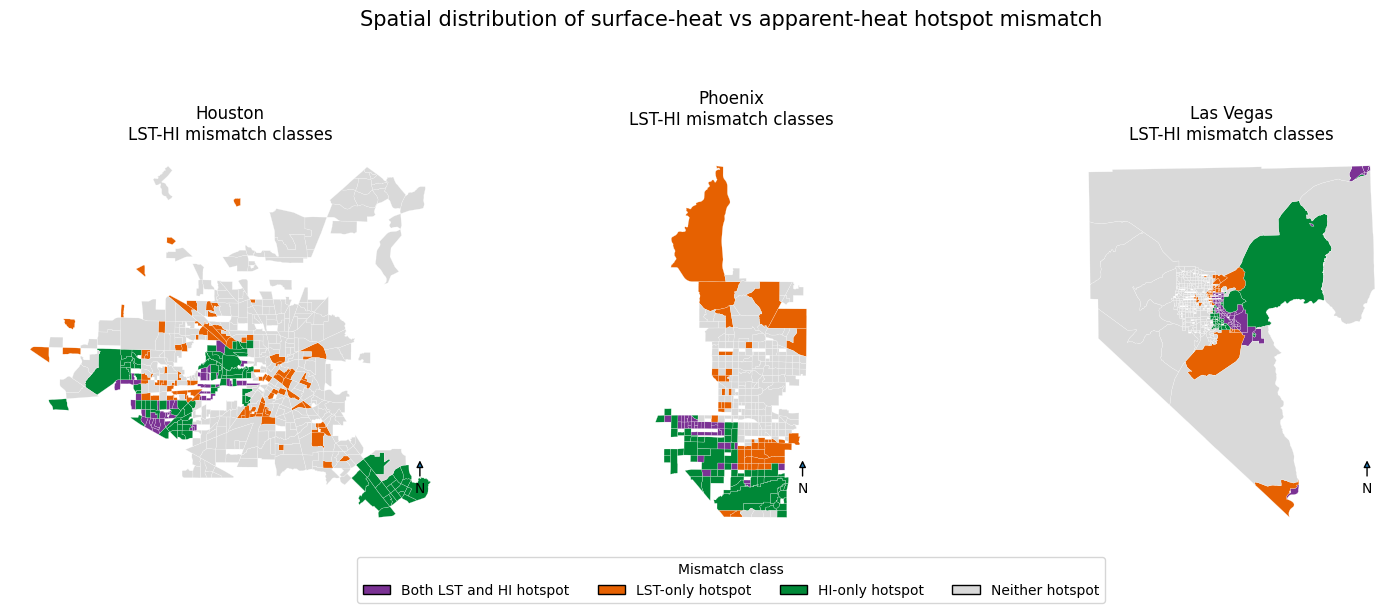

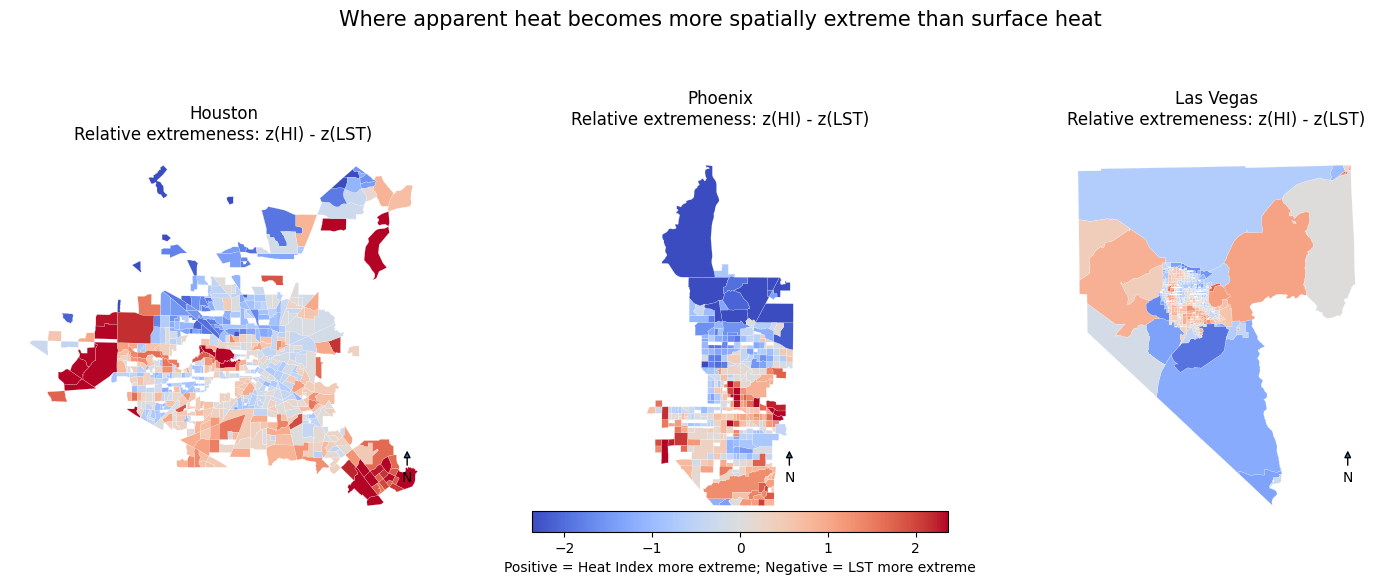

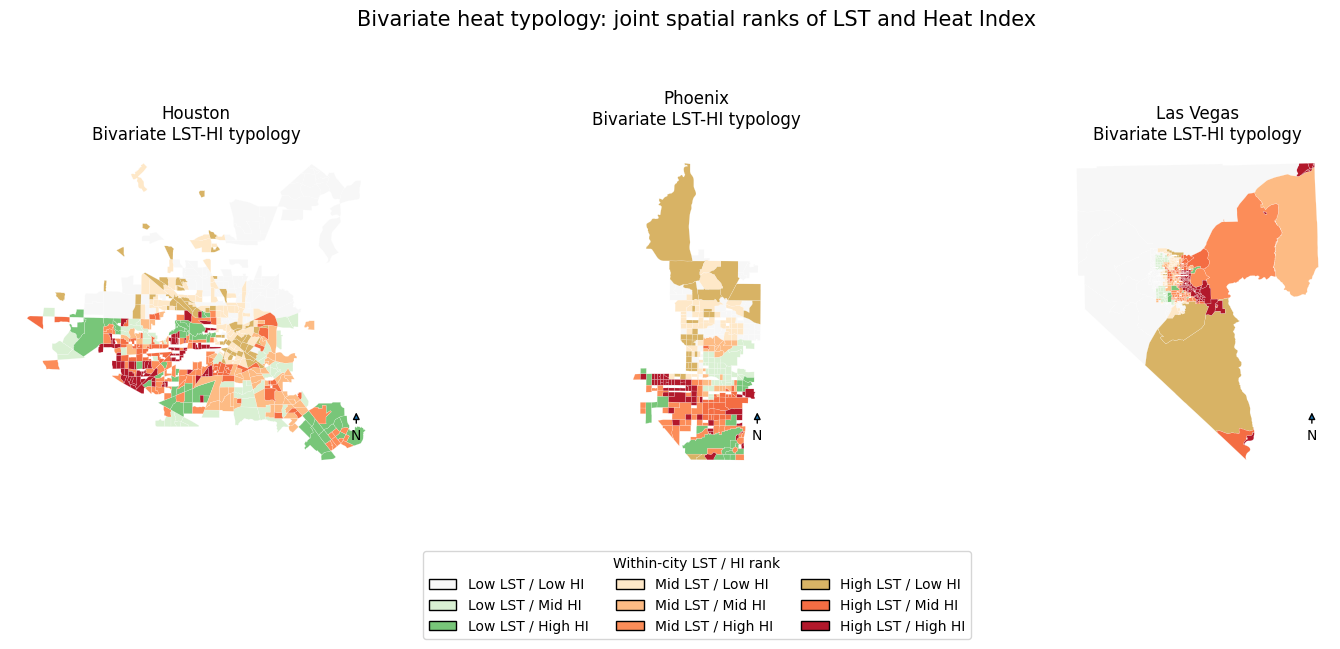

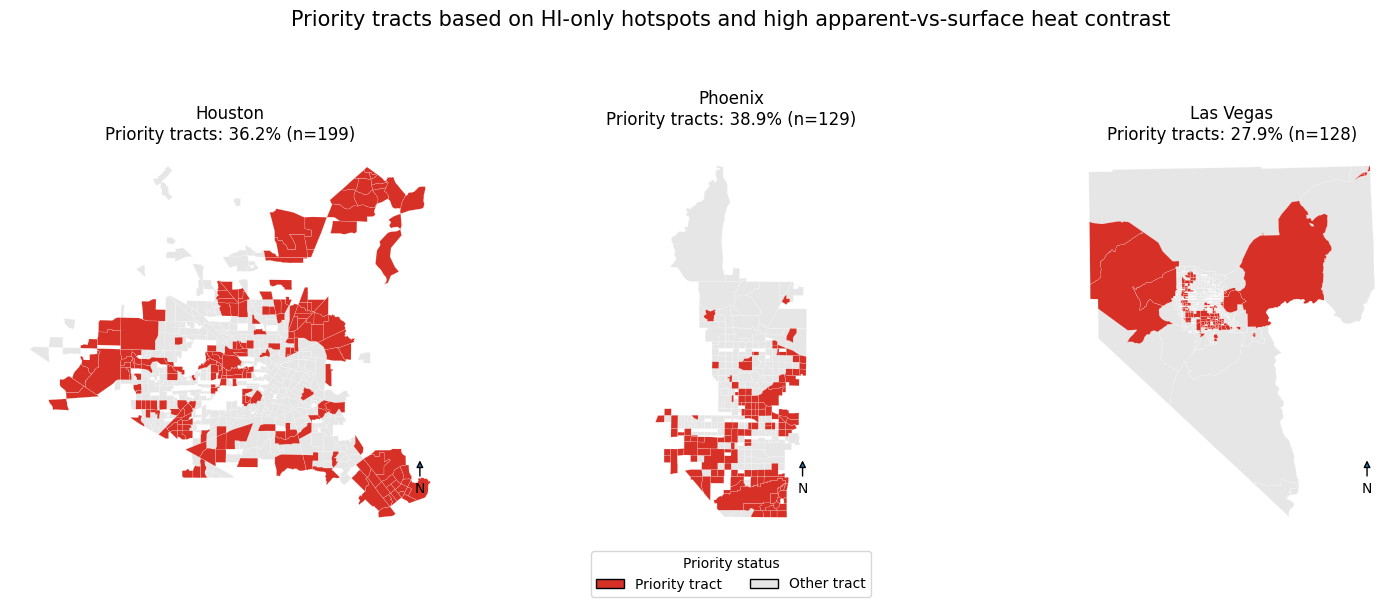


Cross-city spatial mechanism summary:


,city,n_mapped,mean_lst_c,mean_hi_c,pearson_lst_hi,spearman_lst_hi,both_hotspot_pct,lst_only_pct,hi_only_pct,priority_pct,mismatch_separation_pct,overlap_dominance_ratio,hi_only_to_lst_only_ratio,median_hi_minus_lst_z,pct_hi_more_extreme_than_lst
0,houston,549,47.944,34.155,0.341,0.248,9.290,15.847,16.211,36.248,32.058,0.290,1.023,-0.058,47.177
1,phoenix,332,57.057,33.288,0.291,0.323,10.843,14.157,18.373,38.855,32.530,0.333,1.298,-0.004,50.000
2,las_vegas,458,47.003,31.097,0.750,0.672,16.157,8.952,8.952,27.948,17.904,0.902,1.000,-0.015,48.908



Top tracts where Heat Index is more extreme than LST:


,city,GEOID,lst_c,hi_c,hi_minus_lst_z,mismatch_class,priority_flag
483,houston,48201341304,45.984982,34.525119,5.517933,HI-only hotspot,True
216,houston,48201454504,37.702446,34.194292,4.392239,Neither hotspot,True
252,houston,48201454502,38.316711,34.183682,4.022646,Neither hotspot,True
36,houston,48157673006,39.006449,34.182580,3.747009,Neither hotspot,True
35,houston,48157673007,39.301578,34.182580,3.635148,Neither hotspot,True
850,phoenix,04013082204,53.565818,34.186790,3.587343,HI-only hotspot,True
593,phoenix,04013108000,52.093661,33.684223,3.536927,Neither hotspot,True
314,houston,48201510802,40.224181,34.198098,3.485512,HI-only hotspot,True
208,houston,48201541703,38.180265,34.132717,3.417323,Neither hotspot,True
566,phoenix,04013107800,51.440967,33.308242,3.243018,Neither hotspot,True



Top tracts where LST is more extreme than Heat Index:


,city,GEOID,lst_c,hi_c,hi_minus_lst_z,mismatch_class,priority_flag
58,houston,48201554809,48.381187,33.807297,-4.644311,Neither hotspot,False
816,phoenix,04013613300,58.405870,31.306490,-4.283170,LST-only hotspot,False
190,houston,48201552002,50.807701,33.939243,-3.862986,LST-only hotspot,False
779,phoenix,04013612402,60.280840,32.315020,-3.565702,LST-only hotspot,False
536,houston,48201553300,50.002989,33.948243,-3.441964,LST-only hotspot,False
95,houston,48201552603,50.082382,34.001609,-2.784071,LST-only hotspot,False
619,phoenix,04013611300,58.813121,32.308979,-2.738316,LST-only hotspot,False
499,houston,48201251200,42.863102,33.805164,-2.580328,Neither hotspot,True
617,phoenix,04013613000,55.390966,31.306490,-2.561599,Neither hotspot,False
801,phoenix,04013610002,58.813441,32.424857,-2.533048,LST-only hotspot,False



Saved GIS paper figures:
- outputs/pilot/alphaearth/paper_gis_figures/GIS_cross_city_spatial_mechanism_summary.csv
- outputs/pilot/alphaearth/paper_gis_figures/GIS_fig1_mismatch_class_maps.png
- outputs/pilot/alphaearth/paper_gis_figures/GIS_fig2_relative_extremeness_maps.png
- outputs/pilot/alphaearth/paper_gis_figures/GIS_fig3_bivariate_lst_hi_typology_maps.png
- outputs/pilot/alphaearth/paper_gis_figures/GIS_fig4_priority_tract_maps.png
- outputs/pilot/alphaearth/paper_gis_figures/geometry_search_debug_all_cities.csv
- outputs/pilot/alphaearth/paper_gis_figures/three_city_lstadaptive_heat_index_mismatch_GIS_READY.geojson
- outputs/pilot/alphaearth/paper_gis_figures/three_city_lstadaptive_heat_index_mismatch_GIS_READY.gpkg
- outputs/pilot/alphaearth/paper_gis_figures/top_30_tracts_HI_more_extreme_than_LST.csv
- outputs/pilot/alphaearth/paper_gis_figures/top_30_tracts_LST_more_extreme_than_HI.csv

DONE: GIS map-first outputs generated.


In [49]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely import wkt
from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================================
# GIS PAPER FIGURES: map-first outputs
# Goal:
#   1) rebuild tract polygons for Houston / Phoenix / Las Vegas
#   2) join FINAL LST-HI mismatch outputs back to geometry
#   3) produce GIS-style paper figures, not simple bar charts
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth"
GISDIR = OUTDIR / "paper_gis_figures"
GISDIR.mkdir(parents=True, exist_ok=True)

TRACTS_FINAL = OUTDIR / "three_city_analysis_ready_tracts_FINAL.csv"
SELECTED_FINAL = OUTDIR / "three_city_selected_sources.csv"

print("PROJECT =", PROJECT)
print("GISDIR  =", GISDIR)
print("TRACTS_FINAL exists:", TRACTS_FINAL.exists())
print("SELECTED_FINAL exists:", SELECTED_FINAL.exists())

if not TRACTS_FINAL.exists():
    raise FileNotFoundError("Missing three_city_analysis_ready_tracts_FINAL.csv")
if not SELECTED_FINAL.exists():
    raise FileNotFoundError("Missing three_city_selected_sources.csv")

city_order = ["houston", "phoenix", "las_vegas"]

city_state_fips = {
    "houston": "48",
    "phoenix": "04",
    "las_vegas": "32",
}

city_display = {
    "houston": "Houston",
    "phoenix": "Phoenix",
    "las_vegas": "Las Vegas",
}

# ------------------------------------------------------------
# 1. Helpers
# ------------------------------------------------------------
def norm_col(c):
    return re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_")

def normalize_geoid_value(x, city=None):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = re.sub(r"[^0-9]", "", s)

    if s == "":
        return np.nan

    # City-specific repair for leading zero state FIPS, especially Arizona
    if city in city_state_fips:
        state = city_state_fips[city]
        if s.startswith(state) and len(s) <= 11:
            s = s.zfill(11)
        elif city == "phoenix" and len(s) == 10 and s.startswith("4"):
            s = "0" + s
        elif len(s) < 11:
            s = s.zfill(11)

    return s

def find_geoid_col(cols):
    norm_map = {norm_col(c): c for c in cols}
    aliases = [
        "geoid", "geoid20", "geoid10", "geoid_tract",
        "tract_geoid", "tractid", "geo_id", "census_tract",
        "census_tract_geoid", "tract"
    ]

    for a in aliases:
        if a in norm_map:
            return norm_map[a]

    for c in cols:
        n = norm_col(c)
        if "geoid" in n or "tract" in n:
            return c

    return None

def resolve_path(raw_path):
    p = Path(str(raw_path))

    if p.exists():
        return p

    parts = list(p.parts)
    if "heat-exposure-compare" in parts:
        idx = parts.index("heat-exposure-compare")
        rel = Path(*parts[idx + 1:])
        p2 = PROJECT / rel
        if p2.exists():
            return p2

    p3 = PROJECT / str(raw_path)
    if p3.exists():
        return p3

    matches = list(PROJECT.rglob(p.name))
    matches = [m for m in matches if ".ipynb_checkpoints" not in str(m)]
    if len(matches) > 0:
        return matches[0]

    return p

def try_make_geodataframe_from_csv(path):
    df = pd.read_csv(path)

    # Case 1: WKT geometry column
    geometry_cols = []
    for c in df.columns:
        n = norm_col(c)
        if n in ["geometry", "geom", "wkt", "the_geom"]:
            geometry_cols.append(c)

    for gc in geometry_cols:
        try:
            geom = df[gc].dropna().astype(str).head(5)
            if len(geom) > 0 and geom.str.contains("POLYGON|MULTIPOLYGON|POINT", case=False, regex=True).any():
                df["geometry"] = df[gc].apply(lambda x: wkt.loads(x) if pd.notna(x) and str(x).strip() != "" else None)
                gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
                return gdf
        except Exception:
            pass

    # Case 2: lon/lat point columns
    lon_candidates = [c for c in df.columns if norm_col(c) in ["lon", "long", "longitude", "x", "centroid_x"]]
    lat_candidates = [c for c in df.columns if norm_col(c) in ["lat", "latitude", "y", "centroid_y"]]

    if lon_candidates and lat_candidates:
        lon = lon_candidates[0]
        lat = lat_candidates[0]
        try:
            gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.points_from_xy(pd.to_numeric(df[lon], errors="coerce"),
                                            pd.to_numeric(df[lat], errors="coerce")),
                crs="EPSG:4326"
            )
            return gdf
        except Exception:
            pass

    return None

def read_any_geo(path):
    path = Path(path)
    suffix = path.suffix.lower()

    try:
        if suffix in [".gpkg", ".geojson", ".json", ".shp"]:
            gdf = gpd.read_file(path)
            if "geometry" in gdf.columns:
                return gdf

        if suffix == ".parquet":
            try:
                gdf = gpd.read_parquet(path)
                if "geometry" in gdf.columns:
                    return gdf
            except Exception:
                df = pd.read_parquet(path)
                if "geometry" in df.columns:
                    try:
                        df["geometry"] = df["geometry"].apply(lambda x: wkt.loads(x) if pd.notna(x) else None)
                        return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
                    except Exception:
                        return None

        if suffix == ".csv":
            return try_make_geodataframe_from_csv(path)

    except Exception:
        return None

    return None

def candidate_geometry_paths(city, selected_path):
    aliases = {
        "houston": ["houston"],
        "phoenix": ["phoenix"],
        "las_vegas": ["las_vegas", "las vegas", "lasvegas", "vegas"],
    }[city]

    roots = [
        selected_path.parent,
        PROJECT / "data" / "processed" / city,
        PROJECT / "city_intake" / city,
        PROJECT / "outputs",
        PROJECT / "data",
        PROJECT,
    ]

    exts = ["*.gpkg", "*.geojson", "*.json", "*.shp", "*.parquet", "*.csv"]

    paths = []

    # First include selected path itself
    paths.append(selected_path)

    for root in roots:
        if not root.exists():
            continue

        for ext in exts:
            for p in root.rglob(ext):
                s = str(p).lower()
                if ".ipynb_checkpoints" in s:
                    continue

                matched = False
                for a in aliases:
                    ak = a.replace("_", "").replace(" ", "").lower()
                    sk = s.replace("_", "").replace(" ", "").lower()
                    if ak in sk:
                        matched = True

                if city == "las_vegas":
                    if ("las" in s and "vegas" in s) or "lasvegas" in s:
                        matched = True

                if matched:
                    paths.append(p)

    # Remove duplicates
    clean = []
    seen = set()
    for p in paths:
        key = str(p)
        if key not in seen:
            seen.add(key)
            clean.append(p)

    return clean

def download_census_tracts_if_needed(city, target_geoids):
    """
    Optional fallback: pull TIGER tract polygons by state.
    This only runs if local geometry cannot be found.
    Requires internet. If it fails, the local search diagnostics will still show what happened.
    """
    state = city_state_fips[city]
    url = f"https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_{state}_tract.zip"

    print(f"  Trying Census TIGER fallback for {city}: {url}")

    try:
        gdf = gpd.read_file(url)
        if "GEOID" not in gdf.columns:
            return None

        gdf["GEOID_norm"] = gdf["GEOID"].map(lambda x: normalize_geoid_value(x, city))
        gdf = gdf[gdf["GEOID_norm"].isin(target_geoids)].copy()

        if len(gdf) > 0:
            return gdf

    except Exception as e:
        print("  Census TIGER fallback failed:", e)

    return None

def find_best_geometry_for_city(city, selected_path, target_geoids):
    paths = candidate_geometry_paths(city, selected_path)

    checked = []

    for p in paths:
        gdf = read_any_geo(p)

        if gdf is None or "geometry" not in gdf.columns:
            checked.append({
                "city": city,
                "path": str(p),
                "rows": 0,
                "geoid_col": None,
                "overlap": 0,
                "reason": "no readable geometry"
            })
            continue

        geoid_col = find_geoid_col(gdf.columns)

        if geoid_col is None:
            checked.append({
                "city": city,
                "path": str(p),
                "rows": len(gdf),
                "geoid_col": None,
                "overlap": 0,
                "reason": "geometry found but no GEOID column"
            })
            continue

        gdf = gdf.copy()
        gdf["GEOID_norm"] = gdf[geoid_col].map(lambda x: normalize_geoid_value(x, city))
        overlap = int(gdf["GEOID_norm"].isin(target_geoids).sum())

        checked.append({
            "city": city,
            "path": str(p),
            "rows": len(gdf),
            "geoid_col": geoid_col,
            "overlap": overlap,
            "reason": "ok" if overlap > 0 else "geometry + geoid found, but no overlap"
        })

    checked_df = pd.DataFrame(checked)
    if len(checked_df) > 0:
        checked_df = checked_df.sort_values(["overlap", "rows"], ascending=False)

    best_row = None
    if len(checked_df) > 0 and checked_df["overlap"].max() > 0:
        best_row = checked_df.iloc[0]

    if best_row is not None:
        best_path = Path(best_row["path"])
        best_gdf = read_any_geo(best_path)
        best_geoid_col = best_row["geoid_col"]

        best_gdf = best_gdf.copy()
        best_gdf["GEOID"] = best_gdf[best_geoid_col].map(lambda x: normalize_geoid_value(x, city))
        best_gdf = best_gdf[best_gdf["GEOID"].isin(target_geoids)].copy()

        print(f"\nSelected geometry for {city}:")
        print("  path    =", best_path)
        print("  geoid   =", best_geoid_col)
        print("  overlap =", len(best_gdf))

        return best_gdf, checked_df

    # Optional fallback to Census TIGER
    census_gdf = download_census_tracts_if_needed(city, target_geoids)
    if census_gdf is not None and len(census_gdf) > 0:
        census_gdf = census_gdf.copy()
        census_gdf["GEOID"] = census_gdf["GEOID_norm"]
        print(f"\nSelected Census TIGER geometry for {city}:")
        print("  overlap =", len(census_gdf))
        return census_gdf, checked_df

    print(f"\nFAILED to find geometry for {city}. Top checked files:")
    display(checked_df.head(20))
    checked_df.to_csv(GISDIR / f"debug_geometry_search_{city}.csv", index=False)

    return None, checked_df

# ------------------------------------------------------------
# 2. Load final analytical table and selected source table
# ------------------------------------------------------------
tracts = pd.read_csv(TRACTS_FINAL)
selected = pd.read_csv(SELECTED_FINAL)

tracts["city"] = tracts["city"].astype(str).str.strip()
tracts = tracts[tracts["city"].isin(city_order)].copy()

tracts["GEOID"] = tracts.apply(
    lambda r: normalize_geoid_value(r["GEOID"], r["city"]),
    axis=1
)

# Recompute key columns just in case
tracts["lst_c"] = pd.to_numeric(tracts["lst_c"], errors="coerce")
tracts["hi_c"] = pd.to_numeric(tracts["hi_c"], errors="coerce")
tracts["hi_minus_lst"] = tracts["hi_c"] - tracts["lst_c"]

# Recompute z-scores and classes city-by-city
frames = []

for city, g in tracts.groupby("city", sort=False):
    g = g.copy()

    q75_lst = g["lst_c"].quantile(0.75)
    q75_hi = g["hi_c"].quantile(0.75)
    q75_gap = g["hi_minus_lst"].quantile(0.75)

    g["lst_hot_q75"] = g["lst_c"] >= q75_lst
    g["hi_hot_q75"] = g["hi_c"] >= q75_hi

    g["mismatch_class"] = np.select(
        [
            g["lst_hot_q75"] & g["hi_hot_q75"],
            g["lst_hot_q75"] & ~g["hi_hot_q75"],
            ~g["lst_hot_q75"] & g["hi_hot_q75"],
        ],
        [
            "Both LST and HI hotspot",
            "LST-only hotspot",
            "HI-only hotspot",
        ],
        default="Neither hotspot"
    )

    g["priority_flag"] = (
        (g["mismatch_class"] == "HI-only hotspot")
        | (g["hi_minus_lst"] >= q75_gap)
    )

    g["lst_z_city"] = (g["lst_c"] - g["lst_c"].mean()) / g["lst_c"].std(ddof=0)
    g["hi_z_city"] = (g["hi_c"] - g["hi_c"].mean()) / g["hi_c"].std(ddof=0)
    g["hi_minus_lst_z"] = g["hi_z_city"] - g["lst_z_city"]

    # 3x3 bivariate ranks within each city
    g["lst_rank3"] = pd.qcut(g["lst_c"], q=3, labels=["Low LST", "Mid LST", "High LST"], duplicates="drop")
    g["hi_rank3"] = pd.qcut(g["hi_c"], q=3, labels=["Low HI", "Mid HI", "High HI"], duplicates="drop")
    g["bivar_lst_hi"] = g["lst_rank3"].astype(str) + " / " + g["hi_rank3"].astype(str)

    frames.append(g)

tracts = pd.concat(frames, ignore_index=True)

print("\nAnalytical table rows by city:")
display(tracts["city"].value_counts().rename_axis("city").reset_index(name="n"))

# ------------------------------------------------------------
# 3. Rebuild GeoDataFrame for each city
# ------------------------------------------------------------
geo_frames = []
geometry_debug_frames = []

for city in city_order:
    target = tracts[tracts["city"] == city].copy()
    target_geoids = set(target["GEOID"].dropna().astype(str))

    selected_row = selected[selected["city"].astype(str).str.strip() == city].iloc[0]
    selected_path = resolve_path(selected_row["selected_path"])

    print(f"\nFinding geometry for {city_display[city]}...")
    gdf_geom, debug_df = find_best_geometry_for_city(city, selected_path, target_geoids)

    if debug_df is not None and len(debug_df) > 0:
        geometry_debug_frames.append(debug_df)

    if gdf_geom is None or len(gdf_geom) == 0:
        print(f"WARNING: skipping map layer for {city}; no geometry found.")
        continue

    # Keep only geometry + GEOID
    gdf_geom = gdf_geom[["GEOID", "geometry"]].copy()
    gdf_geom = gdf_geom.dropna(subset=["GEOID", "geometry"]).copy()

    merged = gdf_geom.merge(
        target.drop(columns=["geometry"], errors="ignore"),
        on="GEOID",
        how="inner"
    )

    merged = gpd.GeoDataFrame(merged, geometry="geometry", crs=gdf_geom.crs)

    if merged.crs is None:
        merged = merged.set_crs("EPSG:4326", allow_override=True)

    print("  merged map rows =", len(merged))

    if len(merged) == 0:
        raise ValueError(f"{city}: geometry found but merge produced 0 rows")

    geo_frames.append(merged)

if len(geometry_debug_frames) > 0:
    geometry_debug_all = pd.concat(geometry_debug_frames, ignore_index=True)
    geometry_debug_all.to_csv(GISDIR / "geometry_search_debug_all_cities.csv", index=False)

if len(geo_frames) == 0:
    raise ValueError("No city geometry layers found. Need tract geometry before GIS maps.")

gdf_all = pd.concat(geo_frames, ignore_index=True)
gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs=geo_frames[0].crs)

print("\nMapped rows by city:")
display(gdf_all["city"].value_counts().rename_axis("city").reset_index(name="n"))

# Save GIS-ready GeoPackage layers for ArcGIS/QGIS
gpkg_path = GISDIR / "three_city_lstadaptive_heat_index_mismatch_GIS_READY.gpkg"

for city in city_order:
    sub = gdf_all[gdf_all["city"] == city].copy()
    if len(sub) == 0:
        continue
    sub.to_file(gpkg_path, layer=city, driver="GPKG")

gdf_all.to_file(GISDIR / "three_city_lstadaptive_heat_index_mismatch_GIS_READY.geojson", driver="GeoJSON")

print("\nSaved GIS-ready files:")
print("-", gpkg_path.relative_to(PROJECT))
print("-", (GISDIR / "three_city_lstadaptive_heat_index_mismatch_GIS_READY.geojson").relative_to(PROJECT))

# ------------------------------------------------------------
# 4. Plot helpers
# ------------------------------------------------------------
mismatch_colors = {
    "Both LST and HI hotspot": "#7b3294",
    "LST-only hotspot": "#e66101",
    "HI-only hotspot": "#008837",
    "Neither hotspot": "#d9d9d9",
}

bivar_colors = {
    "Low LST / Low HI": "#f7f7f7",
    "Low LST / Mid HI": "#d9f0d3",
    "Low LST / High HI": "#78c679",
    "Mid LST / Low HI": "#fee8c8",
    "Mid LST / Mid HI": "#fdbb84",
    "Mid LST / High HI": "#fc8d59",
    "High LST / Low HI": "#d8b365",
    "High LST / Mid HI": "#f46d43",
    "High LST / High HI": "#b2182b",
}

def prepare_city_for_plot(gdf_city):
    g = gdf_city.copy()

    try:
        utm = g.estimate_utm_crs()
        if utm is not None:
            g = g.to_crs(utm)
    except Exception:
        pass

    return g

def add_north_arrow(ax, x=0.93, y=0.12):
    ax.annotate(
        "N",
        xy=(x, y + 0.08),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=10,
        arrowprops=dict(arrowstyle="-|>", lw=1),
    )

def clean_map_axis(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")

# ------------------------------------------------------------
# 5. GIS Figure 1: mismatch class choropleth
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, city in zip(axes, city_order):
    g = gdf_all[gdf_all["city"] == city].copy()
    g = prepare_city_for_plot(g)

    for cls, color in mismatch_colors.items():
        sub = g[g["mismatch_class"] == cls]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.15)

    ax.set_title(f"{city_display[city]}\nLST-HI mismatch classes", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=mismatch_colors[k], edgecolor="black", label=k)
    for k in mismatch_colors
]

fig.legend(
    handles=legend_handles,
    title="Mismatch class",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Spatial distribution of surface-heat vs apparent-heat hotspot mismatch",
    fontsize=15,
    y=0.98,
)
fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig1 = GISDIR / "GIS_fig1_mismatch_class_maps.png"
fig.savefig(fig1, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. GIS Figure 2: relative extremeness map
# Positive = HI more extreme than LST within the same city
# Negative = LST more extreme than HI within the same city
# ------------------------------------------------------------
vmax = np.nanpercentile(np.abs(gdf_all["hi_minus_lst_z"]), 97)
if not np.isfinite(vmax) or vmax == 0:
    vmax = 2

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, city in zip(axes, city_order):
    g = gdf_all[gdf_all["city"] == city].copy()
    g = prepare_city_for_plot(g)

    g.plot(
        ax=ax,
        column="hi_minus_lst_z",
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        edgecolor="white",
        linewidth=0.12,
        legend=False,
    )

    ax.set_title(f"{city_display[city]}\nRelative extremeness: z(HI) - z(LST)", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045, pad=0.08)
cbar.set_label("Positive = Heat Index more extreme; Negative = LST more extreme")

fig.suptitle(
    "Where apparent heat becomes more spatially extreme than surface heat",
    fontsize=15,
    y=0.98,
)
fig.tight_layout(rect=[0, 0.10, 1, 0.93])

fig2 = GISDIR / "GIS_fig2_relative_extremeness_maps.png"
fig.savefig(fig2, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 7. GIS Figure 3: 3x3 bivariate LST-HI typology map
# This is more GIS/paper-like than a bar chart:
# it maps the joint rank of LST and HI within each city.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, city in zip(axes, city_order):
    g = gdf_all[gdf_all["city"] == city].copy()
    g = prepare_city_for_plot(g)

    for cat, color in bivar_colors.items():
        sub = g[g["bivar_lst_hi"] == cat]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.12)

    ax.set_title(f"{city_display[city]}\nBivariate LST-HI typology", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=bivar_colors[k], edgecolor="black", label=k)
    for k in bivar_colors
]

fig.legend(
    handles=legend_handles,
    title="Within-city LST / HI rank",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    "Bivariate heat typology: joint spatial ranks of LST and Heat Index",
    fontsize=15,
    y=0.98,
)
fig.tight_layout(rect=[0, 0.18, 1, 0.93])

fig3 = GISDIR / "GIS_fig3_bivariate_lst_hi_typology_maps.png"
fig.savefig(fig3, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 8. GIS Figure 4: priority tract map
# Priority = HI-only hotspot OR top-quartile HI-LST contrast
# ------------------------------------------------------------
priority_colors = {
    False: "#e6e6e6",
    True: "#d73027",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, city in zip(axes, city_order):
    g = gdf_all[gdf_all["city"] == city].copy()
    g = prepare_city_for_plot(g)

    g[~g["priority_flag"]].plot(ax=ax, color=priority_colors[False], edgecolor="white", linewidth=0.12)
    g[g["priority_flag"]].plot(ax=ax, color=priority_colors[True], edgecolor="white", linewidth=0.12)

    n_priority = int(g["priority_flag"].sum())
    pct_priority = 100 * g["priority_flag"].mean()

    ax.set_title(
        f"{city_display[city]}\nPriority tracts: {pct_priority:.1f}% (n={n_priority})",
        fontsize=12,
    )
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=priority_colors[True], edgecolor="black", label="Priority tract"),
    Patch(facecolor=priority_colors[False], edgecolor="black", label="Other tract"),
]

fig.legend(
    handles=legend_handles,
    title="Priority status",
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Priority tracts based on HI-only hotspots and high apparent-vs-surface heat contrast",
    fontsize=15,
    y=0.98,
)
fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig4 = GISDIR / "GIS_fig4_priority_tract_maps.png"
fig.savefig(fig4, dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9. Innovative cross-city spatial-mechanism summary
# ------------------------------------------------------------
summary_rows = []

for city in city_order:
    g = gdf_all[gdf_all["city"] == city].copy()

    # Correlation: tells whether LST and HI are spatially aligned
    pearson = g[["lst_c", "hi_c"]].corr(method="pearson").iloc[0, 1]
    spearman = g[["lst_c", "hi_c"]].corr(method="spearman").iloc[0, 1]

    both_pct = 100 * (g["mismatch_class"] == "Both LST and HI hotspot").mean()
    lst_only_pct = 100 * (g["mismatch_class"] == "LST-only hotspot").mean()
    hi_only_pct = 100 * (g["mismatch_class"] == "HI-only hotspot").mean()
    priority_pct = 100 * g["priority_flag"].mean()

    # Mechanism indicators
    mismatch_separation_pct = lst_only_pct + hi_only_pct
    overlap_dominance_ratio = both_pct / mismatch_separation_pct if mismatch_separation_pct > 0 else np.nan
    hi_only_to_lst_only_ratio = hi_only_pct / lst_only_pct if lst_only_pct > 0 else np.nan

    summary_rows.append({
        "city": city,
        "n_mapped": len(g),
        "mean_lst_c": g["lst_c"].mean(),
        "mean_hi_c": g["hi_c"].mean(),
        "pearson_lst_hi": pearson,
        "spearman_lst_hi": spearman,
        "both_hotspot_pct": both_pct,
        "lst_only_pct": lst_only_pct,
        "hi_only_pct": hi_only_pct,
        "priority_pct": priority_pct,
        "mismatch_separation_pct": mismatch_separation_pct,
        "overlap_dominance_ratio": overlap_dominance_ratio,
        "hi_only_to_lst_only_ratio": hi_only_to_lst_only_ratio,
        "median_hi_minus_lst_z": g["hi_minus_lst_z"].median(),
        "pct_hi_more_extreme_than_lst": 100 * (g["hi_minus_lst_z"] > 0).mean(),
    })

mechanism_summary = pd.DataFrame(summary_rows)
mechanism_summary.to_csv(GISDIR / "GIS_cross_city_spatial_mechanism_summary.csv", index=False)

print("\nCross-city spatial mechanism summary:")
display(mechanism_summary.round(3))

# Top tracts for follow-up interpretation
top_hi_shift = (
    gdf_all
    .sort_values("hi_minus_lst_z", ascending=False)
    [["city", "GEOID", "lst_c", "hi_c", "hi_minus_lst_z", "mismatch_class", "priority_flag"]]
    .head(30)
)

top_lst_shift = (
    gdf_all
    .sort_values("hi_minus_lst_z", ascending=True)
    [["city", "GEOID", "lst_c", "hi_c", "hi_minus_lst_z", "mismatch_class", "priority_flag"]]
    .head(30)
)

top_hi_shift.to_csv(GISDIR / "top_30_tracts_HI_more_extreme_than_LST.csv", index=False)
top_lst_shift.to_csv(GISDIR / "top_30_tracts_LST_more_extreme_than_HI.csv", index=False)

print("\nTop tracts where Heat Index is more extreme than LST:")
display(top_hi_shift.head(10))

print("\nTop tracts where LST is more extreme than Heat Index:")
display(top_lst_shift.head(10))

print("\nSaved GIS paper figures:")
for p in sorted(GISDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nDONE: GIS map-first outputs generated.")

GEOJSON exists: True
ADV_DIR: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/paper_gis_advanced_figures

Mapped rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Advanced GIS table rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Priority patch summary preview:


,priority_patch_id,patch_n,patch_area_km2,mean_hi_minus_lst_z,mean_lst_c,mean_hi_c,patch_rank,city
0,4,21,197.682079,-0.391936,41.753601,33.942295,1,houston
1,6,25,167.732528,1.822293,44.052079,34.181625,2,houston
2,5,30,102.232580,0.090015,45.263250,34.082864,3,houston
3,8,22,98.802777,2.201303,47.006509,34.297886,4,houston
4,1,27,46.858816,0.969937,46.861183,34.198098,5,houston
5,9,10,45.541816,1.163951,45.965571,34.186816,6,houston
6,12,9,28.457386,-0.228792,45.647493,34.069431,7,houston
7,2,16,26.422365,0.454657,48.253978,34.199077,8,houston
8,11,3,25.835817,1.136965,45.840143,34.181035,9,houston
9,3,5,18.510857,1.217413,45.666339,34.182165,10,houston


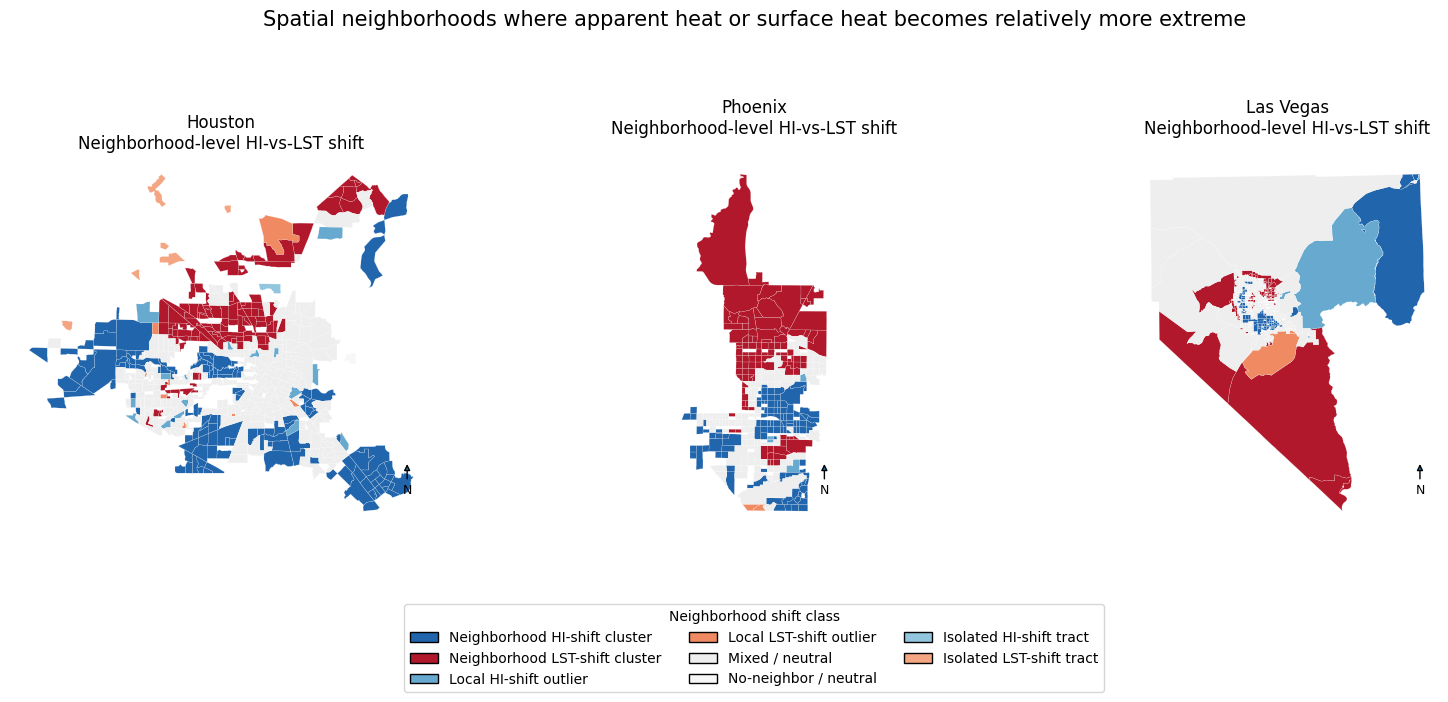

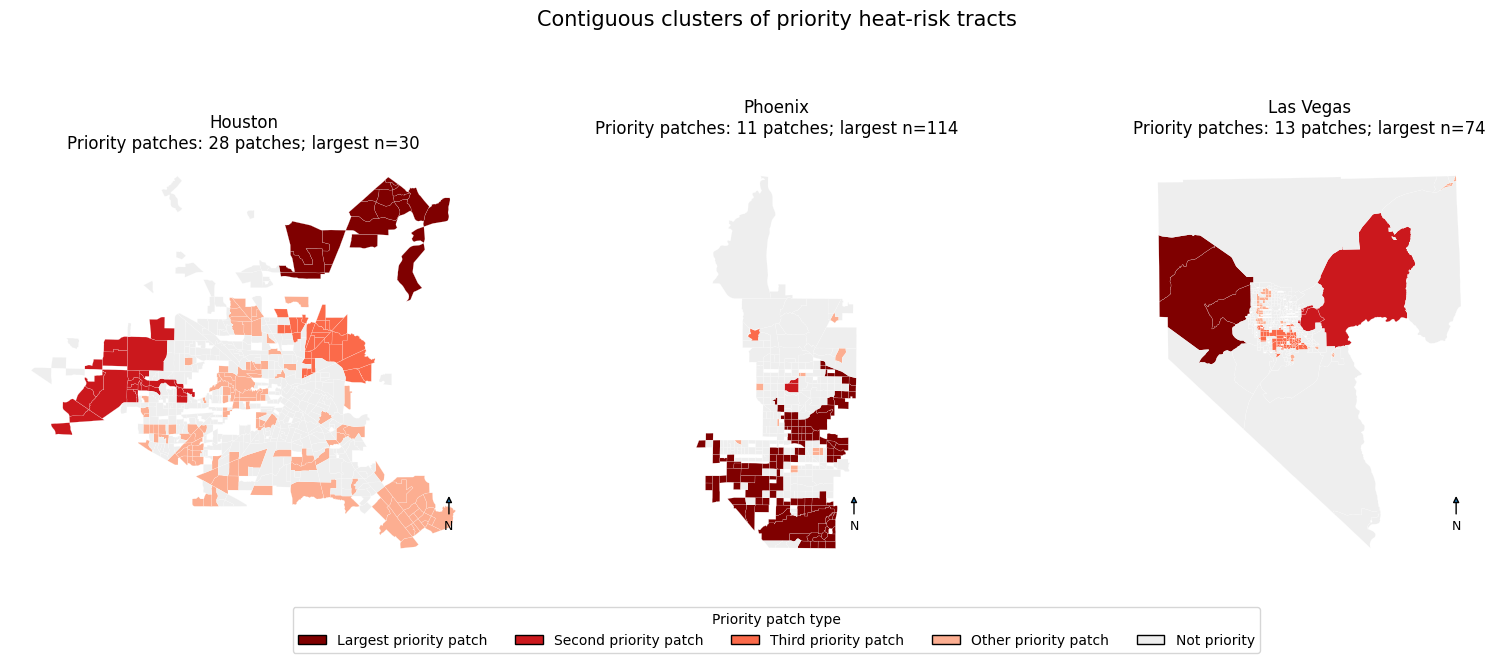

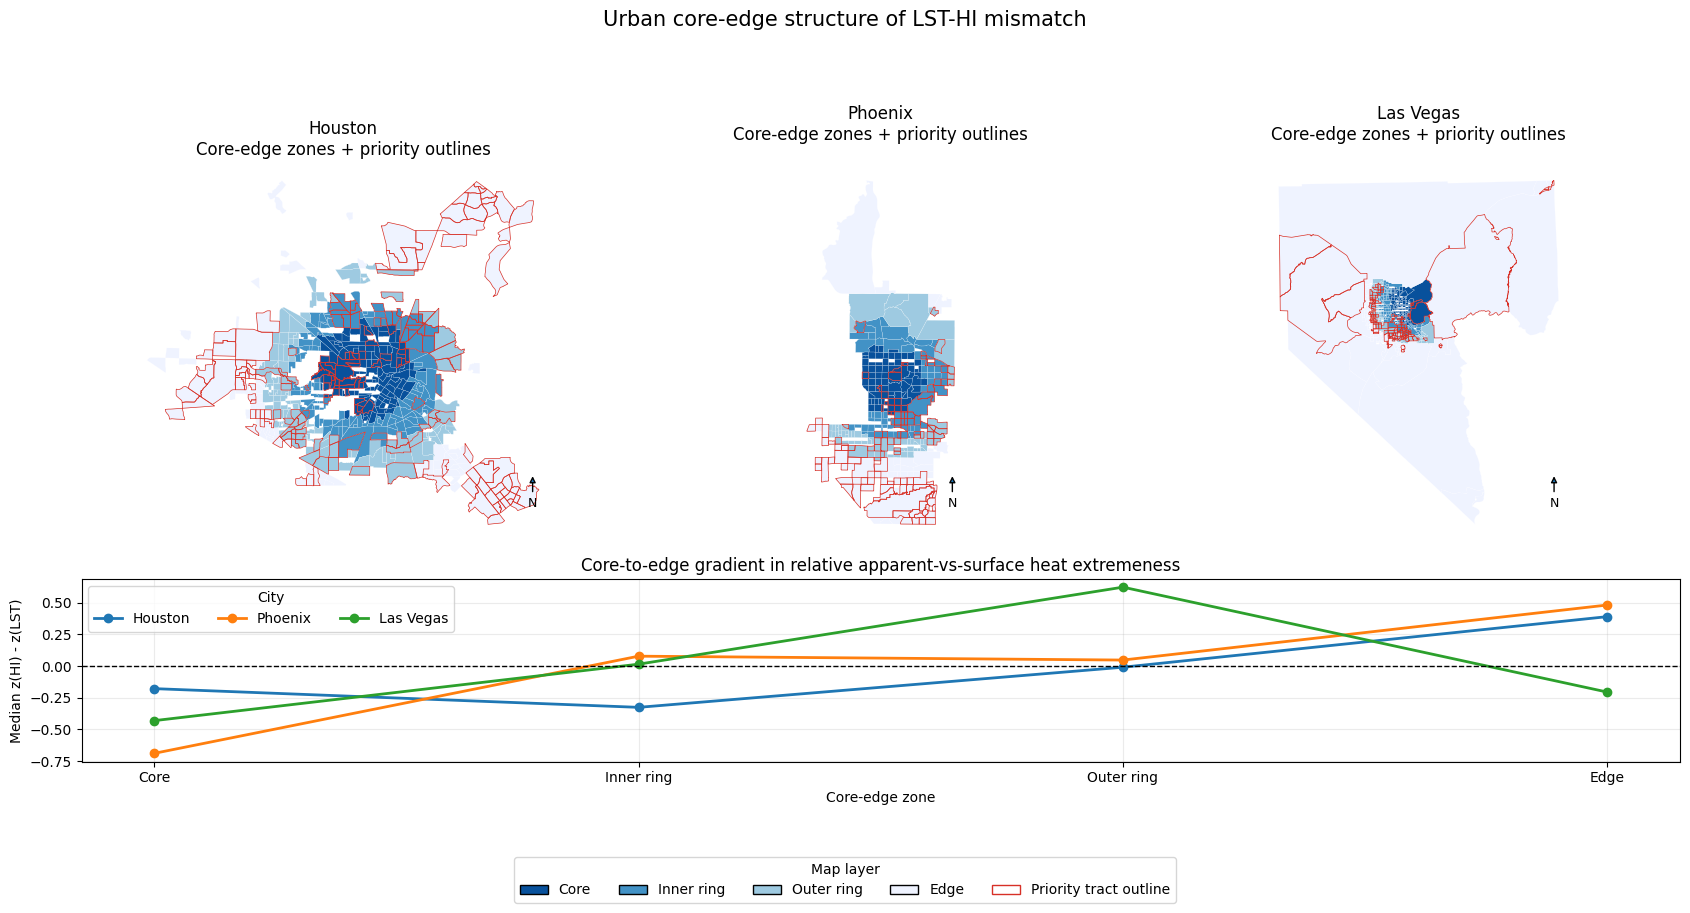


Advanced cross-city spatial mechanism summary:


,city,n_mapped,pearson_lst_hi,spearman_lst_hi,priority_pct,n_priority,n_priority_patches,largest_patch_n,largest_patch_area_km2,largest_patch_share_of_priority,pct_neighborhood_hi_shift_cluster,pct_neighborhood_lst_shift_cluster,core_edge_slope_hi_minus_lst_z_per_km,median_hi_minus_lst_z,pct_hi_more_extreme_than_lst
0,houston,549,0.341,0.248,36.248,199,28,30,197.682,0.151,23.315,20.583,0.033,-0.058,47.177
1,phoenix,332,0.291,0.323,38.855,129,11,114,442.755,0.884,31.627,31.024,0.038,-0.004,50.000
2,las_vegas,458,0.750,0.672,27.948,128,13,74,2629.851,0.578,19.651,17.467,0.007,-0.015,48.908



Core-edge gradient profile:


,city,zone,median_hi_minus_lst_z,mean_hi_minus_lst_z,priority_pct,n
0,houston,Core,-0.178,-0.142,28.986,138
1,houston,Inner ring,-0.326,-0.323,23.358,137
2,houston,Outer ring,-0.009,-0.043,32.847,137
3,houston,Edge,0.390,0.509,59.854,137
8,las_vegas,Core,-0.431,-0.429,8.696,115
9,las_vegas,Inner ring,0.015,0.044,23.684,114
10,las_vegas,Outer ring,0.622,0.504,58.772,114
11,las_vegas,Edge,-0.206,-0.114,20.870,115
4,phoenix,Core,-0.689,-0.483,19.277,83
5,phoenix,Inner ring,0.078,0.067,38.554,83



Saved advanced GIS figures and tables:
- outputs/pilot/alphaearth/paper_gis_advanced_figures/GIS_ADV_cross_city_spatial_mechanism_summary.csv
- outputs/pilot/alphaearth/paper_gis_advanced_figures/GIS_ADV_fig5_neighborhood_shift_maps.png
- outputs/pilot/alphaearth/paper_gis_advanced_figures/GIS_ADV_fig6_priority_patch_clusters.png
- outputs/pilot/alphaearth/paper_gis_advanced_figures/GIS_ADV_fig7_core_edge_gradient.png
- outputs/pilot/alphaearth/paper_gis_advanced_figures/core_edge_gradient_profile.csv
- outputs/pilot/alphaearth/paper_gis_advanced_figures/priority_patch_summary.csv
- outputs/pilot/alphaearth/paper_gis_advanced_figures/three_city_GIS_ADVANCED.geojson
- outputs/pilot/alphaearth/paper_gis_advanced_figures/three_city_GIS_ADVANCED.gpkg

DONE: advanced GIS mechanism figures generated.


In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# ADVANCED GIS RELATION FIGURES
# Build more paper-level spatial mechanism outputs:
# 1) neighborhood HI/LST shift map
# 2) priority patch cluster map
# 3) core-edge gradient map + profile
# 4) cross-city spatial mechanism summary
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
BASE_GISDIR = PROJECT / "outputs" / "pilot" / "alphaearth" / "paper_gis_figures"
ADV_DIR = PROJECT / "outputs" / "pilot" / "alphaearth" / "paper_gis_advanced_figures"
ADV_DIR.mkdir(parents=True, exist_ok=True)

GEOJSON = BASE_GISDIR / "three_city_lstadaptive_heat_index_mismatch_GIS_READY.geojson"

print("GEOJSON exists:", GEOJSON.exists())
print("ADV_DIR:", ADV_DIR)

if not GEOJSON.exists():
    raise FileNotFoundError("Cannot find GIS-ready GeoJSON. Run the previous GIS map cell first.")

gdf = gpd.read_file(GEOJSON)

city_order = ["houston", "phoenix", "las_vegas"]
city_display = {
    "houston": "Houston",
    "phoenix": "Phoenix",
    "las_vegas": "Las Vegas",
}

gdf["city"] = gdf["city"].astype(str).str.strip()
gdf = gdf[gdf["city"].isin(city_order)].copy()

# Fix bool column if it was saved as string
def as_bool(x):
    if isinstance(x, bool):
        return x
    s = str(x).lower().strip()
    return s in ["true", "1", "yes", "t"]

if "priority_flag" in gdf.columns:
    gdf["priority_flag"] = gdf["priority_flag"].map(as_bool)
else:
    raise ValueError("priority_flag column missing.")

for col in ["lst_c", "hi_c", "hi_minus_lst"]:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

# Recompute city-level z if needed
frames = []
for city, gg in gdf.groupby("city", sort=False):
    gg = gg.copy()
    gg["lst_z_city"] = (gg["lst_c"] - gg["lst_c"].mean()) / gg["lst_c"].std(ddof=0)
    gg["hi_z_city"] = (gg["hi_c"] - gg["hi_c"].mean()) / gg["hi_c"].std(ddof=0)
    gg["hi_minus_lst_z"] = gg["hi_z_city"] - gg["lst_z_city"]
    frames.append(gg)

gdf = pd.concat(frames, ignore_index=True)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf.crs)

print("\nMapped rows by city:")
display(gdf["city"].value_counts().rename_axis("city").reset_index(name="n"))

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def to_city_projected(g):
    g = g.copy()
    try:
        utm = g.estimate_utm_crs()
        if utm is not None:
            return g.to_crs(utm)
    except Exception:
        pass
    return g

def clean_map_axis(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")

def add_north_arrow(ax, x=0.94, y=0.10):
    ax.annotate(
        "N",
        xy=(x, y + 0.08),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="-|>", lw=1),
    )

def get_neighbor_lists(g_proj, tolerance_m=20):
    """
    Returns list of neighbor indices for each polygon.
    Uses touches first; then small buffer fallback to catch tiny topology gaps.
    """
    g_proj = g_proj.reset_index(drop=True)
    sindex = g_proj.sindex
    geoms = list(g_proj.geometry)
    neighbor_lists = []

    for i, geom in enumerate(geoms):
        neighbors = []

        try:
            candidates = list(sindex.query(geom, predicate="touches"))
            neighbors = [j for j in candidates if j != i]
        except Exception:
            candidates = list(sindex.query(geom))
            neighbors = [
                j for j in candidates
                if j != i and (geom.touches(geoms[j]) or geom.intersects(geoms[j]))
            ]

        if len(neighbors) == 0:
            try:
                buffered = geom.buffer(tolerance_m)
                candidates = list(sindex.query(buffered, predicate="intersects"))
                neighbors = [j for j in candidates if j != i]
            except Exception:
                candidates = list(sindex.query(geom.buffer(tolerance_m)))
                neighbors = [j for j in candidates if j != i]

        neighbor_lists.append(sorted(set(neighbors)))

    return neighbor_lists

def classify_neighborhood_shift(row):
    local = row["hi_minus_lst_z"]
    lag = row["spatial_lag_hi_minus_lst_z"]

    if pd.isna(lag):
        if local >= 0.75:
            return "Isolated HI-shift tract"
        elif local <= -0.75:
            return "Isolated LST-shift tract"
        return "No-neighbor / neutral"

    if lag >= 0.50:
        return "Neighborhood HI-shift cluster"
    if lag <= -0.50:
        return "Neighborhood LST-shift cluster"
    if local >= 1.00 and lag < 0.25:
        return "Local HI-shift outlier"
    if local <= -1.00 and lag > -0.25:
        return "Local LST-shift outlier"
    return "Mixed / neutral"

# ------------------------------------------------------------
# 1. Compute advanced spatial features city-by-city
# ------------------------------------------------------------
advanced_frames = []
patch_summary_rows = []

for city in city_order:
    g_city_orig = gdf[gdf["city"] == city].copy().reset_index(drop=True)
    g_city_proj = to_city_projected(g_city_orig)

    # Area and distance to city center
    g_city_proj["area_km2"] = g_city_proj.geometry.area / 1_000_000
    center = g_city_proj.geometry.unary_union.centroid
    g_city_proj["centroid_geom"] = g_city_proj.geometry.centroid
    g_city_proj["distance_to_center_km"] = g_city_proj["centroid_geom"].distance(center) / 1000

    # Core-edge zones using rank to avoid qcut duplicate problems
    ranked_dist = g_city_proj["distance_to_center_km"].rank(method="first")
    g_city_proj["core_edge_zone"] = pd.qcut(
        ranked_dist,
        q=4,
        labels=["Core", "Inner ring", "Outer ring", "Edge"]
    )

    # Spatial lag of HI-vs-LST relative extremeness
    neighbor_lists = get_neighbor_lists(g_city_proj, tolerance_m=20)
    vals = g_city_proj["hi_minus_lst_z"].values

    lag_values = []
    neighbor_counts = []

    for neigh in neighbor_lists:
        neighbor_counts.append(len(neigh))
        if len(neigh) == 0:
            lag_values.append(np.nan)
        else:
            lag_values.append(np.nanmean(vals[neigh]))

    g_city_proj["neighbor_count"] = neighbor_counts
    g_city_proj["spatial_lag_hi_minus_lst_z"] = lag_values
    g_city_proj["neighborhood_shift_class"] = g_city_proj.apply(classify_neighborhood_shift, axis=1)

    # Priority patch connected components
    g_city_proj["priority_patch_id"] = -1

    priority_idx = list(g_city_proj.index[g_city_proj["priority_flag"] == True])
    prio = g_city_proj.loc[priority_idx].copy().reset_index().rename(columns={"index": "orig_idx"})

    if len(prio) > 0:
        prio_neighbors = get_neighbor_lists(prio, tolerance_m=20)

        visited = set()
        patch_id = 0

        for i in range(len(prio)):
            if i in visited:
                continue

            patch_id += 1
            stack = [i]
            component = []

            while stack:
                node = stack.pop()
                if node in visited:
                    continue

                visited.add(node)
                component.append(node)

                for nb in prio_neighbors[node]:
                    if nb not in visited:
                        stack.append(nb)

            orig_indices = prio.loc[component, "orig_idx"].tolist()
            g_city_proj.loc[orig_indices, "priority_patch_id"] = patch_id

    patch_stats = (
        g_city_proj[g_city_proj["priority_patch_id"] > 0]
        .groupby("priority_patch_id", as_index=False)
        .agg(
            patch_n=("GEOID", "count"),
            patch_area_km2=("area_km2", "sum"),
            mean_hi_minus_lst_z=("hi_minus_lst_z", "mean"),
            mean_lst_c=("lst_c", "mean"),
            mean_hi_c=("hi_c", "mean"),
        )
    )

    if len(patch_stats) > 0:
        patch_stats = patch_stats.sort_values(
            ["patch_area_km2", "patch_n"],
            ascending=False
        ).reset_index(drop=True)
        patch_stats["patch_rank"] = np.arange(1, len(patch_stats) + 1)
    else:
        patch_stats["patch_rank"] = []

    rank_map = dict(zip(patch_stats["priority_patch_id"], patch_stats["patch_rank"]))
    n_map = dict(zip(patch_stats["priority_patch_id"], patch_stats["patch_n"]))
    area_map = dict(zip(patch_stats["priority_patch_id"], patch_stats["patch_area_km2"]))

    g_city_proj["priority_patch_rank"] = g_city_proj["priority_patch_id"].map(rank_map).fillna(0).astype(int)
    g_city_proj["priority_patch_n"] = g_city_proj["priority_patch_id"].map(n_map).fillna(0).astype(int)
    g_city_proj["priority_patch_area_km2"] = g_city_proj["priority_patch_id"].map(area_map).fillna(0)

    def patch_label(row):
        if not row["priority_flag"]:
            return "Not priority"
        r = row["priority_patch_rank"]
        if r == 1:
            return "Largest priority patch"
        if r == 2:
            return "Second priority patch"
        if r == 3:
            return "Third priority patch"
        return "Other priority patch"

    g_city_proj["priority_patch_label"] = g_city_proj.apply(patch_label, axis=1)

    # Bring attributes back to original CRS geometry
    keep_attrs = [
        "area_km2",
        "distance_to_center_km",
        "core_edge_zone",
        "neighbor_count",
        "spatial_lag_hi_minus_lst_z",
        "neighborhood_shift_class",
        "priority_patch_id",
        "priority_patch_rank",
        "priority_patch_n",
        "priority_patch_area_km2",
        "priority_patch_label",
    ]

    for col in keep_attrs:
        g_city_orig[col] = g_city_proj[col].values

    advanced_frames.append(g_city_orig)

    # Patch summary
    if len(patch_stats) > 0:
        patch_stats["city"] = city
        patch_summary_rows.append(patch_stats)

gdf_adv = pd.concat(advanced_frames, ignore_index=True)
gdf_adv = gpd.GeoDataFrame(gdf_adv, geometry="geometry", crs=gdf.crs)

if len(patch_summary_rows) > 0:
    patch_summary = pd.concat(patch_summary_rows, ignore_index=True)
else:
    patch_summary = pd.DataFrame()

gdf_adv.to_file(ADV_DIR / "three_city_GIS_ADVANCED.geojson", driver="GeoJSON")

gpkg_path = ADV_DIR / "three_city_GIS_ADVANCED.gpkg"
gdf_adv.to_file(gpkg_path, layer="all_cities", driver="GPKG")

for city in city_order:
    sub = gdf_adv[gdf_adv["city"] == city].copy()
    sub.to_file(gpkg_path, layer=city, driver="GPKG")

patch_summary.to_csv(ADV_DIR / "priority_patch_summary.csv", index=False)

print("\nAdvanced GIS table rows by city:")
display(gdf_adv["city"].value_counts().rename_axis("city").reset_index(name="n"))

print("\nPriority patch summary preview:")
display(patch_summary.head(15))

# ------------------------------------------------------------
# 2. Figure 5: Neighborhood shift maps
# ------------------------------------------------------------
neigh_colors = {
    "Neighborhood HI-shift cluster": "#2166ac",
    "Neighborhood LST-shift cluster": "#b2182b",
    "Local HI-shift outlier": "#67a9cf",
    "Local LST-shift outlier": "#ef8a62",
    "Mixed / neutral": "#eeeeee",
    "No-neighbor / neutral": "#f7f7f7",
    "Isolated HI-shift tract": "#92c5de",
    "Isolated LST-shift tract": "#f4a582",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 6.5))

for ax, city in zip(axes, city_order):
    gg = gdf_adv[gdf_adv["city"] == city].copy()
    gg_plot = to_city_projected(gg)

    for cls, color in neigh_colors.items():
        sub = gg_plot[gg_plot["neighborhood_shift_class"] == cls]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.12)

    ax.set_title(
        f"{city_display[city]}\nNeighborhood-level HI-vs-LST shift",
        fontsize=12
    )
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=cls)
    for cls, color in neigh_colors.items()
]

fig.legend(
    handles=legend_handles,
    title="Neighborhood shift class",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    "Spatial neighborhoods where apparent heat or surface heat becomes relatively more extreme",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.16, 1, 0.92])

fig5 = ADV_DIR / "GIS_ADV_fig5_neighborhood_shift_maps.png"
fig.savefig(fig5, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 3. Figure 6: Priority patch cluster maps
# ------------------------------------------------------------
patch_colors = {
    "Largest priority patch": "#7f0000",
    "Second priority patch": "#cb181d",
    "Third priority patch": "#fb6a4a",
    "Other priority patch": "#fcae91",
    "Not priority": "#eeeeee",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 6.5))

for ax, city in zip(axes, city_order):
    gg = gdf_adv[gdf_adv["city"] == city].copy()
    gg_plot = to_city_projected(gg)

    for cls, color in patch_colors.items():
        sub = gg_plot[gg_plot["priority_patch_label"] == cls]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.12)

    city_patches = patch_summary[patch_summary["city"] == city].copy()
    n_patches = len(city_patches)
    largest_n = int(city_patches["patch_n"].max()) if n_patches > 0 else 0

    ax.set_title(
        f"{city_display[city]}\nPriority patches: {n_patches} patches; largest n={largest_n}",
        fontsize=12
    )
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=cls)
    for cls, color in patch_colors.items()
]

fig.legend(
    handles=legend_handles,
    title="Priority patch type",
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Contiguous clusters of priority heat-risk tracts",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.10, 1, 0.92])

fig6 = ADV_DIR / "GIS_ADV_fig6_priority_patch_clusters.png"
fig.savefig(fig6, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Figure 7: Core-edge gradient map + profile
# ------------------------------------------------------------
zone_colors = {
    "Core": "#08519c",
    "Inner ring": "#4292c6",
    "Outer ring": "#9ecae1",
    "Edge": "#eff3ff",
}

fig = plt.figure(figsize=(17, 9))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1.45])

for i, city in enumerate(city_order):
    ax = fig.add_subplot(gs[0, i])

    gg = gdf_adv[gdf_adv["city"] == city].copy()
    gg_plot = to_city_projected(gg)

    for zone, color in zone_colors.items():
        sub = gg_plot[gg_plot["core_edge_zone"].astype(str) == zone]
        if len(sub) > 0:
            sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.12)

    # Overlay priority outlines
    prio = gg_plot[gg_plot["priority_flag"] == True]
    if len(prio) > 0:
        prio.boundary.plot(ax=ax, color="#d73027", linewidth=0.5)

    ax.set_title(f"{city_display[city]}\nCore-edge zones + priority outlines", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

ax_profile = fig.add_subplot(gs[1, :])

profile_rows = []
zone_order = ["Core", "Inner ring", "Outer ring", "Edge"]

for city in city_order:
    gg = gdf_adv[gdf_adv["city"] == city].copy()
    for zone in zone_order:
        sub = gg[gg["core_edge_zone"].astype(str) == zone]
        if len(sub) == 0:
            continue
        profile_rows.append({
            "city": city,
            "zone": zone,
            "median_hi_minus_lst_z": sub["hi_minus_lst_z"].median(),
            "mean_hi_minus_lst_z": sub["hi_minus_lst_z"].mean(),
            "priority_pct": 100 * sub["priority_flag"].mean(),
            "n": len(sub),
        })

profile = pd.DataFrame(profile_rows)
profile["zone"] = pd.Categorical(profile["zone"], categories=zone_order, ordered=True)
profile = profile.sort_values(["city", "zone"])
profile.to_csv(ADV_DIR / "core_edge_gradient_profile.csv", index=False)

for city in city_order:
    sub = profile[profile["city"] == city].copy()
    ax_profile.plot(
        sub["zone"].astype(str),
        sub["median_hi_minus_lst_z"],
        marker="o",
        linewidth=2,
        label=city_display[city],
    )

ax_profile.axhline(0, color="black", linewidth=1, linestyle="--")
ax_profile.set_ylabel("Median z(HI) - z(LST)")
ax_profile.set_xlabel("Core-edge zone")
ax_profile.set_title("Core-to-edge gradient in relative apparent-vs-surface heat extremeness")
ax_profile.grid(alpha=0.25)
ax_profile.legend(title="City", ncol=3)

legend_zone = [
    Patch(facecolor=color, edgecolor="black", label=zone)
    for zone, color in zone_colors.items()
]
legend_priority = Patch(facecolor="none", edgecolor="#d73027", label="Priority tract outline")

fig.legend(
    handles=legend_zone + [legend_priority],
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
    title="Map layer",
)

fig.suptitle(
    "Urban core-edge structure of LST-HI mismatch",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig7 = ADV_DIR / "GIS_ADV_fig7_core_edge_gradient.png"
fig.savefig(fig7, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Cross-city advanced spatial mechanism summary
# ------------------------------------------------------------
summary_rows = []

for city in city_order:
    gg = gdf_adv[gdf_adv["city"] == city].copy()

    corr_pearson = gg[["lst_c", "hi_c"]].corr(method="pearson").iloc[0, 1]
    corr_spearman = gg[["lst_c", "hi_c"]].corr(method="spearman").iloc[0, 1]

    n_priority = int(gg["priority_flag"].sum())
    priority_pct = 100 * gg["priority_flag"].mean()

    city_patches = patch_summary[patch_summary["city"] == city].copy()
    n_patches = len(city_patches)

    largest_patch_n = int(city_patches["patch_n"].max()) if n_patches > 0 else 0
    largest_patch_area = city_patches["patch_area_km2"].max() if n_patches > 0 else 0
    largest_patch_share_of_priority = largest_patch_n / n_priority if n_priority > 0 else np.nan

    pct_neighborhood_hi_shift = 100 * (
        gg["neighborhood_shift_class"] == "Neighborhood HI-shift cluster"
    ).mean()

    pct_neighborhood_lst_shift = 100 * (
        gg["neighborhood_shift_class"] == "Neighborhood LST-shift cluster"
    ).mean()

    # Core-edge slope: positive means HI-relative extremeness increases outward
    if gg["distance_to_center_km"].nunique() > 1:
        slope = np.polyfit(
            gg["distance_to_center_km"],
            gg["hi_minus_lst_z"],
            1
        )[0]
    else:
        slope = np.nan

    summary_rows.append({
        "city": city,
        "n_mapped": len(gg),
        "pearson_lst_hi": corr_pearson,
        "spearman_lst_hi": corr_spearman,
        "priority_pct": priority_pct,
        "n_priority": n_priority,
        "n_priority_patches": n_patches,
        "largest_patch_n": largest_patch_n,
        "largest_patch_area_km2": largest_patch_area,
        "largest_patch_share_of_priority": largest_patch_share_of_priority,
        "pct_neighborhood_hi_shift_cluster": pct_neighborhood_hi_shift,
        "pct_neighborhood_lst_shift_cluster": pct_neighborhood_lst_shift,
        "core_edge_slope_hi_minus_lst_z_per_km": slope,
        "median_hi_minus_lst_z": gg["hi_minus_lst_z"].median(),
        "pct_hi_more_extreme_than_lst": 100 * (gg["hi_minus_lst_z"] > 0).mean(),
    })

advanced_summary = pd.DataFrame(summary_rows)
advanced_summary.to_csv(ADV_DIR / "GIS_ADV_cross_city_spatial_mechanism_summary.csv", index=False)

print("\nAdvanced cross-city spatial mechanism summary:")
display(advanced_summary.round(3))

print("\nCore-edge gradient profile:")
display(profile.round(3))

print("\nSaved advanced GIS figures and tables:")
for p in sorted(ADV_DIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nDONE: advanced GIS mechanism figures generated.")

Checking variables from previous failed cell...
OK: previous edge/frontier variables exist.

Adjacency edge summary:


,city,n_edges
0,houston,1441
1,las_vegas,1373
2,phoenix,949



Frontier line summary:


,city,frontier_type,n_segments
0,houston,Both ↔ Neither transition,54
1,houston,Both ↔ single-hotspot transition,903
2,houston,Direct LST-only ↔ HI-only frontier,229
3,houston,HI-only ↔ Neither transition,629
4,houston,LST-only ↔ Neither transition,3242
5,las_vegas,Both ↔ Neither transition,610
6,las_vegas,Both ↔ single-hotspot transition,2490
7,las_vegas,Direct LST-only ↔ HI-only frontier,544
8,las_vegas,HI-only ↔ Neither transition,6857
9,las_vegas,LST-only ↔ Neither transition,2832


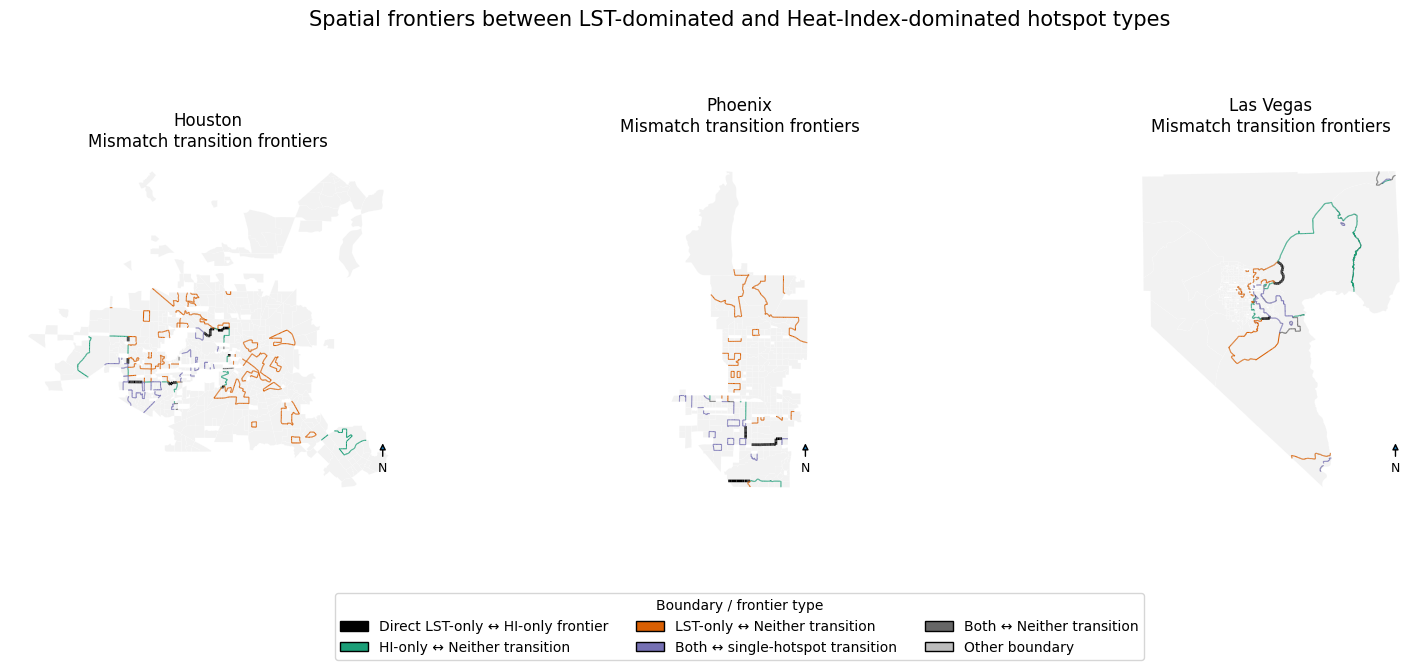

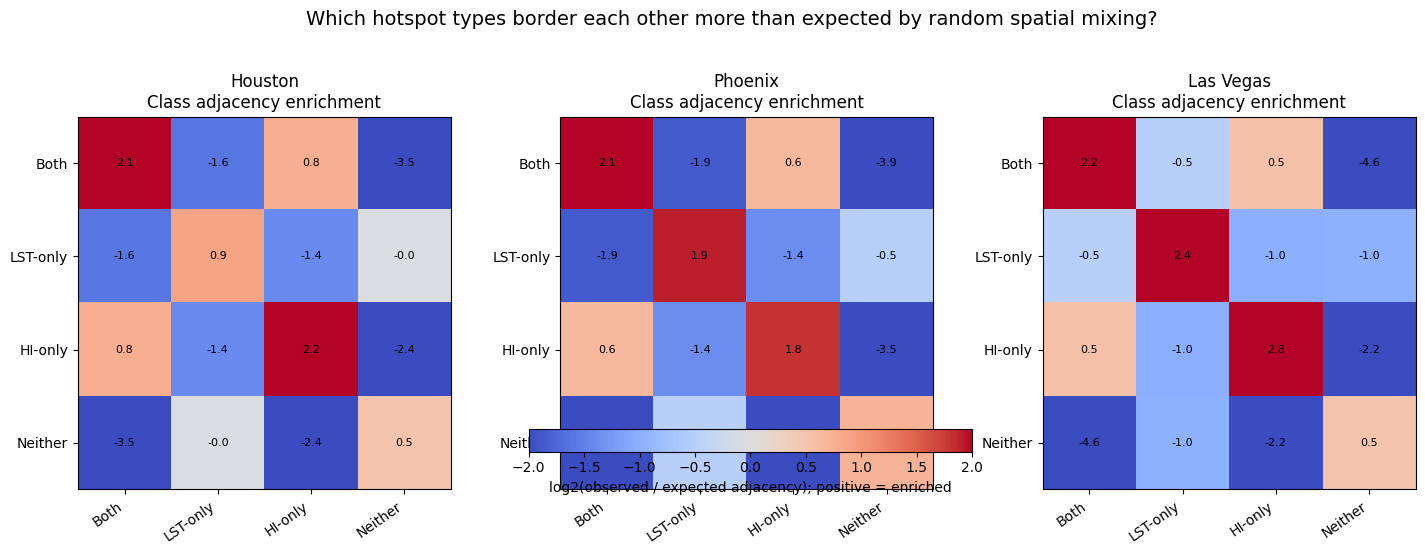

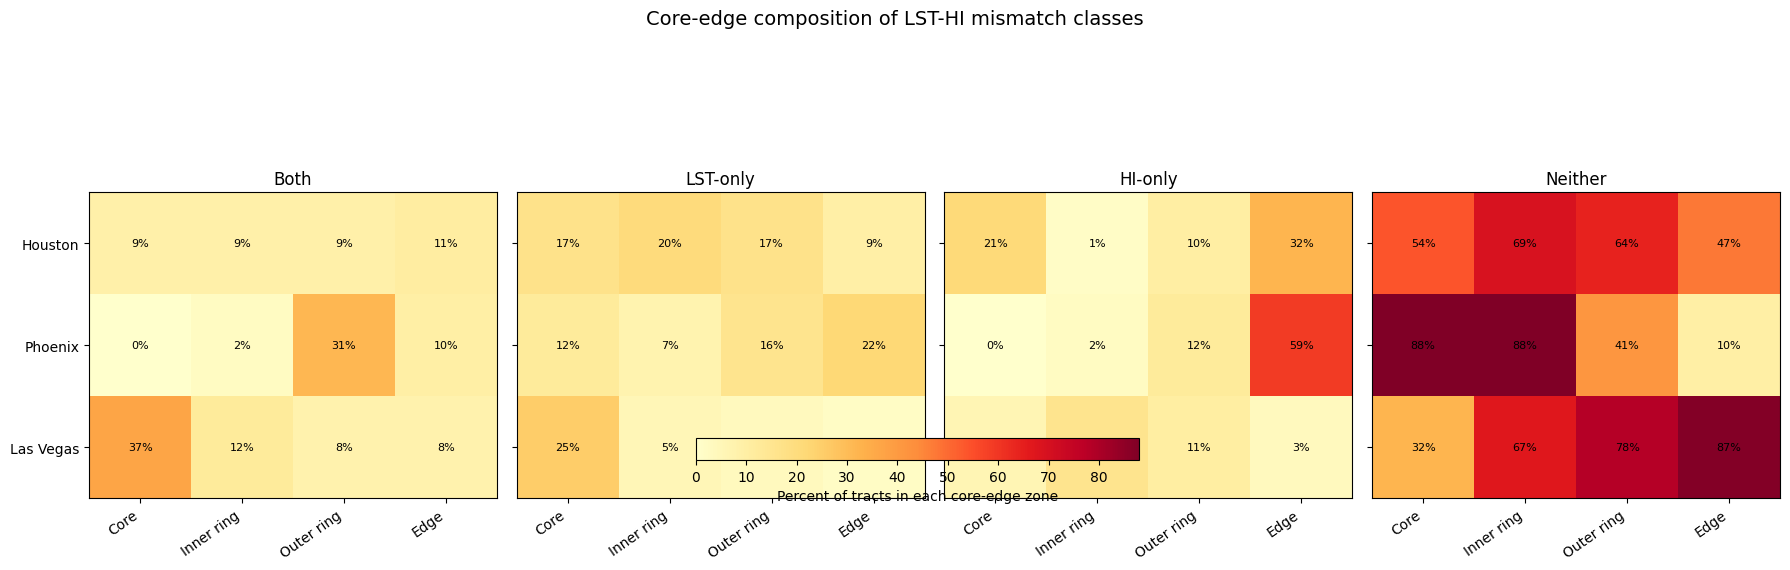


Frontier interpretation summary:


,city,n_adjacency_edges,same_class_adjacency_pct,direct_LST_only_HI_only_frontier_length_km,most_common_neighbor_pair,most_common_neighbor_pair_edges
0,houston,1441,69.188,14.934,Neither | Neither,706
1,phoenix,949,76.923,18.839,Neither | Neither,500
2,las_vegas,1373,83.467,30.581,Neither | Neither,848



Saved frontier / adjacency outputs:
- outputs/pilot/alphaearth/paper_gis_frontier_figures/GIS_FRONTIER_fig10_core_edge_mismatch_composition_heatmaps.png
- outputs/pilot/alphaearth/paper_gis_frontier_figures/GIS_FRONTIER_fig8_mismatch_transition_frontiers.png
- outputs/pilot/alphaearth/paper_gis_frontier_figures/GIS_FRONTIER_fig9_adjacency_enrichment_heatmaps.png
- outputs/pilot/alphaearth/paper_gis_frontier_figures/adjacency_enrichment_observed_expected.csv
- outputs/pilot/alphaearth/paper_gis_frontier_figures/core_edge_mismatch_composition.csv
- outputs/pilot/alphaearth/paper_gis_frontier_figures/frontier_interpretation_summary.csv
- outputs/pilot/alphaearth/paper_gis_frontier_figures/mismatch_frontier_lines_all_cities.geojson
- outputs/pilot/alphaearth/paper_gis_frontier_figures/mismatch_frontier_lines_all_cities.gpkg
- outputs/pilot/alphaearth/paper_gis_frontier_figures/spatial_adjacency_edges_all_cities.csv

DONE: CRS fixed; spatial frontier and adjacency relationship figures gene

In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# FIX CELL: continue from failed frontier cell
# Fix CRS mismatch among frontier lines from different UTM zones
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")
OUTDIR = PROJECT / "outputs" / "pilot" / "alphaearth" / "paper_gis_frontier_figures"
OUTDIR.mkdir(parents=True, exist_ok=True)

city_order = ["houston", "phoenix", "las_vegas"]
city_display = {
    "houston": "Houston",
    "phoenix": "Phoenix",
    "las_vegas": "Las Vegas",
}

class_order = [
    "Both LST and HI hotspot",
    "LST-only hotspot",
    "HI-only hotspot",
    "Neither hotspot",
]

class_short = {
    "Both LST and HI hotspot": "Both",
    "LST-only hotspot": "LST-only",
    "HI-only hotspot": "HI-only",
    "Neither hotspot": "Neither",
}

print("Checking variables from previous failed cell...")

needed_vars = ["all_edges", "all_frontiers", "plot_city_projected", "gdf"]
missing_vars = [v for v in needed_vars if v not in globals()]

if missing_vars:
    raise NameError(
        f"Missing variables: {missing_vars}. "
        "Please rerun the previous frontier cell until it reaches the CRS error, then run this fix cell."
    )

print("OK: previous edge/frontier variables exist.")

# ------------------------------------------------------------
# 1. Concatenate edges normally
# ------------------------------------------------------------
edges_all = pd.concat(all_edges, ignore_index=True)
edges_all.to_csv(OUTDIR / "spatial_adjacency_edges_all_cities.csv", index=False)

print("\nAdjacency edge summary:")
display(edges_all.groupby("city").size().reset_index(name="n_edges"))

# ------------------------------------------------------------
# 2. FIX: convert every frontier GeoDataFrame to EPSG:4326 before concat
# ------------------------------------------------------------
frontier_fixed_list = []

for f in all_frontiers:
    if f is None or len(f) == 0:
        continue

    f = gpd.GeoDataFrame(f, geometry="geometry")

    if f.crs is None:
        # If missing CRS, assume it matches one of the projected city layers.
        # This should rarely happen, but prevents crash.
        print("WARNING: one frontier layer has no CRS; skipping it.")
        continue

    f = f.to_crs("EPSG:4326")
    frontier_fixed_list.append(f)

if len(frontier_fixed_list) > 0:
    frontiers_all = pd.concat(frontier_fixed_list, ignore_index=True)
    frontiers_all = gpd.GeoDataFrame(frontiers_all, geometry="geometry", crs="EPSG:4326")
else:
    frontiers_all = gpd.GeoDataFrame(
        columns=["city", "class_i", "class_j", "frontier_type", "length_m", "geometry"],
        geometry="geometry",
        crs="EPSG:4326"
    )

print("\nFrontier line summary:")
if len(frontiers_all) > 0:
    display(frontiers_all.groupby(["city", "frontier_type"]).size().reset_index(name="n_segments"))
else:
    print("No frontier lines found.")

frontiers_all.to_file(OUTDIR / "mismatch_frontier_lines_all_cities.geojson", driver="GeoJSON")
frontiers_all.to_file(OUTDIR / "mismatch_frontier_lines_all_cities.gpkg", layer="frontiers", driver="GPKG")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def clean_map_axis(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")

def add_north_arrow(ax, x=0.94, y=0.10):
    ax.annotate(
        "N",
        xy=(x, y + 0.08),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="-|>", lw=1),
    )

# ------------------------------------------------------------
# 3. Figure 8: Mismatch frontier maps
# ------------------------------------------------------------
frontier_colors = {
    "Direct LST-only ↔ HI-only frontier": "#000000",
    "HI-only ↔ Neither transition": "#1b9e77",
    "LST-only ↔ Neither transition": "#d95f02",
    "Both ↔ single-hotspot transition": "#7570b3",
    "Both ↔ Neither transition": "#666666",
    "Other boundary": "#bdbdbd",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 6.2))

for ax, city in zip(axes, city_order):
    g_plot = plot_city_projected[city].copy()

    # base tract map
    g_plot.plot(ax=ax, color="#f2f2f2", edgecolor="white", linewidth=0.10)

    f_city = frontiers_all[frontiers_all["city"] == city].copy()

    if len(f_city) > 0:
        # Convert frontier lines back to this city's projected CRS for plotting
        f_city = f_city.to_crs(g_plot.crs)

        for ftype, color in frontier_colors.items():
            sub = f_city[f_city["frontier_type"] == ftype]
            if len(sub) > 0:
                lw = 1.9 if ftype == "Direct LST-only ↔ HI-only frontier" else 0.75
                sub.plot(ax=ax, color=color, linewidth=lw)

    ax.set_title(f"{city_display[city]}\nMismatch transition frontiers", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=label)
    for label, color in frontier_colors.items()
]

fig.legend(
    handles=legend_handles,
    title="Boundary / frontier type",
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08),
)

fig.suptitle(
    "Spatial frontiers between LST-dominated and Heat-Index-dominated hotspot types",
    fontsize=15,
    y=0.98,
)

fig.tight_layout(rect=[0, 0.16, 1, 0.92])

fig8 = OUTDIR / "GIS_FRONTIER_fig8_mismatch_transition_frontiers.png"
fig.savefig(fig8, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Figure 9: Adjacency enrichment heatmaps
# ------------------------------------------------------------
matrix_rows = []

for city in city_order:
    g_city = gdf[gdf["city"] == city].copy()
    e_city = edges_all[edges_all["city"] == city].copy()

    class_counts = g_city["mismatch_class"].value_counts()
    class_probs = class_counts / class_counts.sum()
    total_edges = len(e_city)

    for a in class_order:
        for b in class_order:
            if class_order.index(b) < class_order.index(a):
                continue

            if a == b:
                obs = ((e_city["class_i"] == a) & (e_city["class_j"] == b)).sum()
                expected_prob = class_probs.get(a, 0) ** 2
            else:
                obs = (
                    ((e_city["class_i"] == a) & (e_city["class_j"] == b))
                    | ((e_city["class_i"] == b) & (e_city["class_j"] == a))
                ).sum()
                expected_prob = 2 * class_probs.get(a, 0) * class_probs.get(b, 0)

            expected = expected_prob * total_edges
            ratio = obs / expected if expected > 0 else np.nan
            log2_ratio = np.log2(ratio) if ratio > 0 else np.nan

            matrix_rows.append({
                "city": city,
                "class_a": a,
                "class_b": b,
                "observed_edges": obs,
                "expected_edges_random_mixing": expected,
                "observed_expected_ratio": ratio,
                "log2_observed_expected_ratio": log2_ratio,
            })

matrix = pd.DataFrame(matrix_rows)
matrix.to_csv(OUTDIR / "adjacency_enrichment_observed_expected.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, city in zip(axes, city_order):
    m_city = matrix[matrix["city"] == city].copy()

    mat = pd.DataFrame(
        np.nan,
        index=[class_short[c] for c in class_order],
        columns=[class_short[c] for c in class_order],
    )

    for _, r in m_city.iterrows():
        a = class_short[r["class_a"]]
        b = class_short[r["class_b"]]
        val = r["log2_observed_expected_ratio"]
        mat.loc[a, b] = val
        mat.loc[b, a] = val

    im = ax.imshow(mat.values, vmin=-2, vmax=2, cmap="coolwarm")

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=35, ha="right")
    ax.set_yticklabels(mat.index)

    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            val = mat.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)

    ax.set_title(f"{city_display[city]}\nClass adjacency enrichment")

fig.suptitle(
    "Which hotspot types border each other more than expected by random spatial mixing?",
    fontsize=14,
    y=1.03,
)

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.06, pad=0.22)
cbar.set_label("log2(observed / expected adjacency); positive = enriched")

fig.tight_layout()

fig9 = OUTDIR / "GIS_FRONTIER_fig9_adjacency_enrichment_heatmaps.png"
fig.savefig(fig9, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. Figure 10: Core-edge mismatch composition heatmap
# ------------------------------------------------------------
if "core_edge_zone" not in gdf.columns:
    raise ValueError("core_edge_zone missing. Run advanced GIS cell first.")

zone_order = ["Core", "Inner ring", "Outer ring", "Edge"]

composition_rows = []

for city in city_order:
    gg = gdf[gdf["city"] == city].copy()

    for zone in zone_order:
        gz = gg[gg["core_edge_zone"].astype(str) == zone].copy()
        if len(gz) == 0:
            continue

        for cls in class_order:
            pct = 100 * (gz["mismatch_class"] == cls).mean()
            composition_rows.append({
                "city": city,
                "zone": zone,
                "mismatch_class": cls,
                "pct": pct,
                "n_zone": len(gz),
            })

composition = pd.DataFrame(composition_rows)
composition.to_csv(OUTDIR / "core_edge_mismatch_composition.csv", index=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8), sharey=True)

vmax = np.nanmax(composition["pct"])

for ax, cls in zip(axes, class_order):
    sub = composition[composition["mismatch_class"] == cls].copy()

    mat = (
        sub
        .pivot(index="city", columns="zone", values="pct")
        .reindex(index=city_order, columns=zone_order)
    )

    im = ax.imshow(mat.values, vmin=0, vmax=vmax, cmap="YlOrRd")

    ax.set_xticks(np.arange(len(zone_order)))
    ax.set_xticklabels(zone_order, rotation=35, ha="right")

    ax.set_yticks(np.arange(len(city_order)))
    ax.set_yticklabels([city_display[c] for c in city_order])

    ax.set_title(class_short[cls])

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8)

fig.suptitle(
    "Core-edge composition of LST-HI mismatch classes",
    fontsize=14,
    y=1.05,
)

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.06, pad=0.24)
cbar.set_label("Percent of tracts in each core-edge zone")

fig.tight_layout()

fig10 = OUTDIR / "GIS_FRONTIER_fig10_core_edge_mismatch_composition_heatmaps.png"
fig.savefig(fig10, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Frontier interpretation summary
# ------------------------------------------------------------
interpretation_rows = []

for city in city_order:
    e_city = edges_all[edges_all["city"] == city].copy()
    f_city = frontiers_all[frontiers_all["city"] == city].copy()

    direct_frontier_len = 0
    if len(f_city) > 0:
        direct_frontier_len = f_city.loc[
            f_city["frontier_type"] == "Direct LST-only ↔ HI-only frontier",
            "length_m"
        ].sum()

    same_class_pct = 100 * e_city["same_class"].mean() if len(e_city) > 0 else np.nan

    top_pair_counts = e_city["pair_label"].value_counts()
    if len(top_pair_counts) > 0:
        top_pair_label = top_pair_counts.index[0]
        top_pair_edges = int(top_pair_counts.iloc[0])
    else:
        top_pair_label = None
        top_pair_edges = 0

    interpretation_rows.append({
        "city": city,
        "n_adjacency_edges": len(e_city),
        "same_class_adjacency_pct": same_class_pct,
        "direct_LST_only_HI_only_frontier_length_km": direct_frontier_len / 1000,
        "most_common_neighbor_pair": top_pair_label,
        "most_common_neighbor_pair_edges": top_pair_edges,
    })

frontier_summary = pd.DataFrame(interpretation_rows)
frontier_summary.to_csv(OUTDIR / "frontier_interpretation_summary.csv", index=False)

print("\nFrontier interpretation summary:")
display(frontier_summary.round(3))

print("\nSaved frontier / adjacency outputs:")
for p in sorted(OUTDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nDONE: CRS fixed; spatial frontier and adjacency relationship figures generated.")

ADV_GEOJSON exists: True
OUTDIR: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures

Hotspot displacement summary:


,city,n_tracts,lst_hot_n,hi_hot_n,both_hot_n,hotspot_union_n,hotspot_jaccard_overlap,lst_hot_q75_threshold,hi_hot_q75_threshold,centroid_shift_distance_km,centroid_shift_direction,centroid_shift_direction_degrees_from_north
0,houston,549,138,140,51,227,0.225,49.662,34.198,8.234,SE,151.700
1,phoenix,332,83,97,36,144,0.250,58.368,33.686,35.199,S,182.080
2,las_vegas,458,115,115,74,156,0.474,48.002,31.990,50.930,NE,25.576


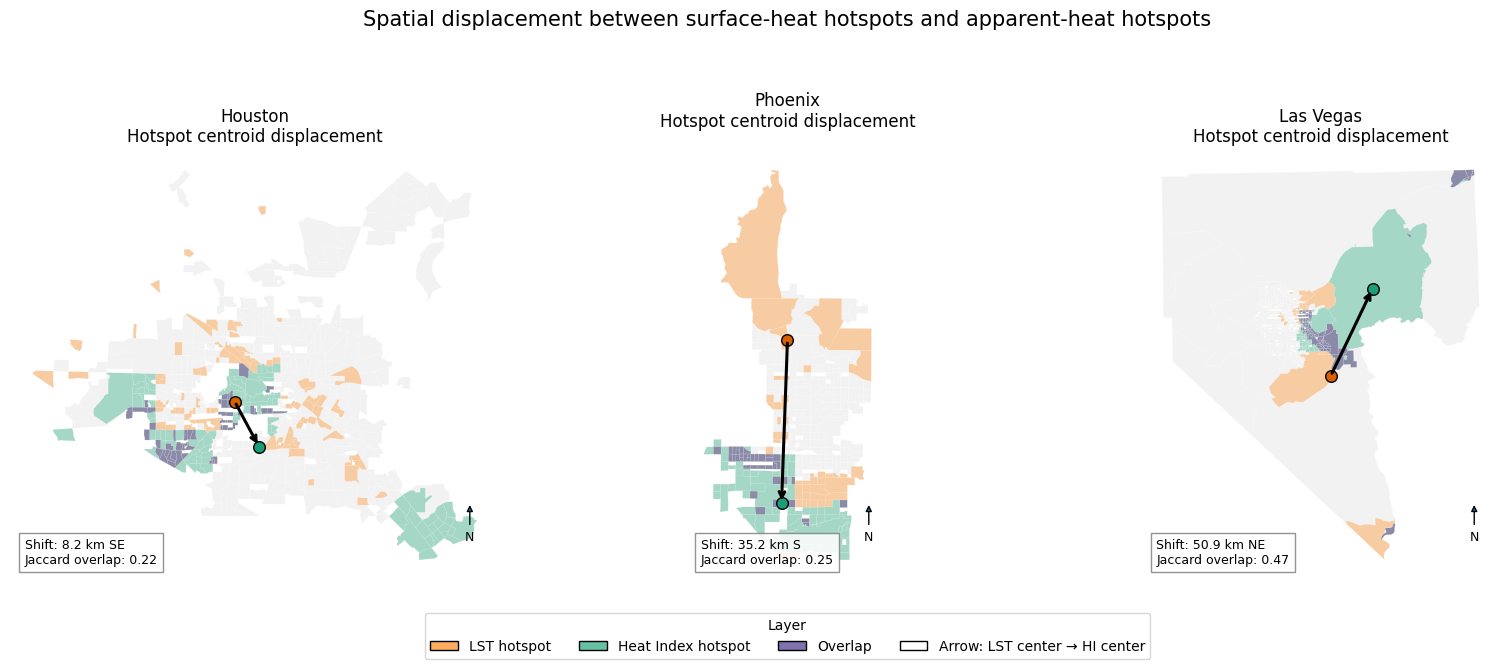


Interpretation notes:
- Houston: the Heat Index hotspot center is shifted 8.2 km toward SE relative to the LST hotspot center; hotspot Jaccard overlap = 0.22.
- Phoenix: the Heat Index hotspot center is shifted 35.2 km toward S relative to the LST hotspot center; hotspot Jaccard overlap = 0.25.
- Las Vegas: the Heat Index hotspot center is shifted 50.9 km toward NE relative to the LST hotspot center; hotspot Jaccard overlap = 0.47.

Saved hotspot shift outputs:
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/GIS_SHIFT_fig11_hotspot_centroid_displacement.png
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/hotspot_centroid_displacement_GIS_READY.gpkg
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/hotspot_centroid_displacement_summary.csv
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/hotspot_centroid_points.geojson
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/hotspot_centroid_shift_lines.geojson
- outputs/pilot/alphaearth/paper

In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import Point, LineString
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# HOTSPOT DISPLACEMENT VECTOR MAP
# Question:
#   Are LST hotspots and Heat Index hotspots centered in the same place?
# Output:
#   1) map with LST-hotspot centroid -> HI-hotspot centroid arrow
#   2) displacement distance / direction table
#   3) GIS-ready centroid points and shift lines
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

ADV_GEOJSON = (
    PROJECT
    / "outputs"
    / "pilot"
    / "alphaearth"
    / "paper_gis_advanced_figures"
    / "three_city_GIS_ADVANCED.geojson"
)

OUTDIR = (
    PROJECT
    / "outputs"
    / "pilot"
    / "alphaearth"
    / "paper_gis_hotspot_shift_figures"
)
OUTDIR.mkdir(parents=True, exist_ok=True)

print("ADV_GEOJSON exists:", ADV_GEOJSON.exists())
print("OUTDIR:", OUTDIR)

if not ADV_GEOJSON.exists():
    raise FileNotFoundError("Cannot find three_city_GIS_ADVANCED.geojson. Run the advanced GIS cell first.")

gdf = gpd.read_file(ADV_GEOJSON)

city_order = ["houston", "phoenix", "las_vegas"]
city_display = {
    "houston": "Houston",
    "phoenix": "Phoenix",
    "las_vegas": "Las Vegas",
}

gdf["city"] = gdf["city"].astype(str).str.strip()
gdf = gdf[gdf["city"].isin(city_order)].copy()

for col in ["lst_c", "hi_c"]:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def to_city_projected(g):
    g = g.copy()
    try:
        utm = g.estimate_utm_crs()
        if utm is not None:
            return g.to_crs(utm)
    except Exception:
        pass
    return g

def area_weighted_centroid(g):
    """
    Area-weighted centroid for a group of polygons.
    """
    g = g.copy()
    areas = g.geometry.area.values
    centroids = g.geometry.centroid

    if np.nansum(areas) == 0:
        x = centroids.x.mean()
        y = centroids.y.mean()
    else:
        x = np.average(centroids.x, weights=areas)
        y = np.average(centroids.y, weights=areas)

    return Point(x, y)

def compass_from_dxdy(dx, dy):
    """
    Direction of arrow from LST center to HI center.
    0 degrees = North, 90 = East.
    """
    angle = (np.degrees(np.arctan2(dx, dy)) + 360) % 360
    labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((angle + 22.5) // 45) % 8
    return labels[idx], angle

def clean_map_axis(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")

def add_north_arrow(ax, x=0.94, y=0.10):
    ax.annotate(
        "N",
        xy=(x, y + 0.08),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=9,
        arrowprops=dict(arrowstyle="-|>", lw=1),
    )

# ------------------------------------------------------------
# Build displacement metrics and GIS layers
# ------------------------------------------------------------
summary_rows = []
point_layers = []
line_layers = []
plot_data = {}

for city in city_order:
    gg = gdf[gdf["city"] == city].copy()
    gg_proj = to_city_projected(gg)

    # Recompute top-quartile LST and HI hotspots within each city
    q75_lst = gg_proj["lst_c"].quantile(0.75)
    q75_hi = gg_proj["hi_c"].quantile(0.75)

    gg_proj["lst_hot_q75"] = gg_proj["lst_c"] >= q75_lst
    gg_proj["hi_hot_q75"] = gg_proj["hi_c"] >= q75_hi

    lst_hot = gg_proj[gg_proj["lst_hot_q75"]].copy()
    hi_hot = gg_proj[gg_proj["hi_hot_q75"]].copy()
    both_hot = gg_proj[gg_proj["lst_hot_q75"] & gg_proj["hi_hot_q75"]].copy()

    if len(lst_hot) == 0 or len(hi_hot) == 0:
        print(f"WARNING: {city} has missing hotspot group; skipping.")
        continue

    lst_center = area_weighted_centroid(lst_hot)
    hi_center = area_weighted_centroid(hi_hot)

    dx = hi_center.x - lst_center.x
    dy = hi_center.y - lst_center.y
    distance_km = np.sqrt(dx**2 + dy**2) / 1000
    direction_label, direction_deg = compass_from_dxdy(dx, dy)

    union_n = int((gg_proj["lst_hot_q75"] | gg_proj["hi_hot_q75"]).sum())
    both_n = int((gg_proj["lst_hot_q75"] & gg_proj["hi_hot_q75"]).sum())
    jaccard = both_n / union_n if union_n > 0 else np.nan

    summary_rows.append({
        "city": city,
        "n_tracts": len(gg_proj),
        "lst_hot_n": len(lst_hot),
        "hi_hot_n": len(hi_hot),
        "both_hot_n": both_n,
        "hotspot_union_n": union_n,
        "hotspot_jaccard_overlap": jaccard,
        "lst_hot_q75_threshold": q75_lst,
        "hi_hot_q75_threshold": q75_hi,
        "centroid_shift_distance_km": distance_km,
        "centroid_shift_direction": direction_label,
        "centroid_shift_direction_degrees_from_north": direction_deg,
    })

    # Save point/line layers in city CRS, then convert to WGS84 for concat
    pts = gpd.GeoDataFrame(
        [
            {"city": city, "center_type": "LST hotspot center", "geometry": lst_center},
            {"city": city, "center_type": "HI hotspot center", "geometry": hi_center},
        ],
        geometry="geometry",
        crs=gg_proj.crs
    ).to_crs("EPSG:4326")

    line = gpd.GeoDataFrame(
        [
            {
                "city": city,
                "shift_type": "LST center to HI center",
                "distance_km": distance_km,
                "direction": direction_label,
                "geometry": LineString([lst_center, hi_center])
            }
        ],
        geometry="geometry",
        crs=gg_proj.crs
    ).to_crs("EPSG:4326")

    point_layers.append(pts)
    line_layers.append(line)

    plot_data[city] = {
        "g": gg_proj,
        "lst_hot": lst_hot,
        "hi_hot": hi_hot,
        "both_hot": both_hot,
        "lst_center": lst_center,
        "hi_center": hi_center,
        "distance_km": distance_km,
        "direction_label": direction_label,
        "jaccard": jaccard,
    }

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTDIR / "hotspot_centroid_displacement_summary.csv", index=False)

points_all = pd.concat(point_layers, ignore_index=True)
points_all = gpd.GeoDataFrame(points_all, geometry="geometry", crs="EPSG:4326")
points_all.to_file(OUTDIR / "hotspot_centroid_points.geojson", driver="GeoJSON")

lines_all = pd.concat(line_layers, ignore_index=True)
lines_all = gpd.GeoDataFrame(lines_all, geometry="geometry", crs="EPSG:4326")
lines_all.to_file(OUTDIR / "hotspot_centroid_shift_lines.geojson", driver="GeoJSON")

gpkg_path = OUTDIR / "hotspot_centroid_displacement_GIS_READY.gpkg"
points_all.to_file(gpkg_path, layer="centroid_points", driver="GPKG")
lines_all.to_file(gpkg_path, layer="shift_lines", driver="GPKG")

print("\nHotspot displacement summary:")
display(summary.round(3))

# ------------------------------------------------------------
# Figure 11: Hotspot centroid displacement vector map
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 6.5))

for ax, city in zip(axes, city_order):
    d = plot_data[city]

    gg = d["g"]
    lst_hot = d["lst_hot"]
    hi_hot = d["hi_hot"]
    both_hot = d["both_hot"]
    lst_center = d["lst_center"]
    hi_center = d["hi_center"]

    # Base tracts
    gg.plot(ax=ax, color="#f2f2f2", edgecolor="white", linewidth=0.10)

    # LST and HI hotspot layers
    lst_hot.plot(ax=ax, color="#fdae61", alpha=0.55, edgecolor="white", linewidth=0.12)
    hi_hot.plot(ax=ax, color="#66c2a5", alpha=0.55, edgecolor="white", linewidth=0.12)

    # Both overlap on top
    if len(both_hot) > 0:
        both_hot.plot(ax=ax, color="#8073ac", alpha=0.70, edgecolor="white", linewidth=0.12)

    # Centroid points
    ax.scatter(lst_center.x, lst_center.y, s=70, color="#d95f02", edgecolor="black", zorder=5)
    ax.scatter(hi_center.x, hi_center.y, s=70, color="#1b9e77", edgecolor="black", zorder=5)

    # Arrow from LST center to HI center
    ax.annotate(
        "",
        xy=(hi_center.x, hi_center.y),
        xytext=(lst_center.x, lst_center.y),
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black"),
        zorder=6,
    )

    text = (
        f"Shift: {d['distance_km']:.1f} km {d['direction_label']}\n"
        f"Jaccard overlap: {d['jaccard']:.2f}"
    )

    ax.text(
        0.03,
        0.03,
        text,
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
    )

    ax.set_title(f"{city_display[city]}\nHotspot centroid displacement", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor="#fdae61", edgecolor="black", label="LST hotspot"),
    Patch(facecolor="#66c2a5", edgecolor="black", label="Heat Index hotspot"),
    Patch(facecolor="#8073ac", edgecolor="black", label="Overlap"),
    Patch(facecolor="white", edgecolor="black", label="Arrow: LST center → HI center"),
]

fig.legend(
    handles=legend_handles,
    title="Layer",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.03)
)

fig.suptitle(
    "Spatial displacement between surface-heat hotspots and apparent-heat hotspots",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig_path = OUTDIR / "GIS_SHIFT_fig11_hotspot_centroid_displacement.png"
fig.savefig(fig_path, dpi=350, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# Simple interpretation text
# ------------------------------------------------------------
notes = []

for _, r in summary.iterrows():
    notes.append(
        f"{city_display[r['city']]}: the Heat Index hotspot center is shifted "
        f"{r['centroid_shift_distance_km']:.1f} km toward {r['centroid_shift_direction']} "
        f"relative to the LST hotspot center; hotspot Jaccard overlap = {r['hotspot_jaccard_overlap']:.2f}."
    )

with open(OUTDIR / "hotspot_displacement_interpretation_notes.txt", "w") as f:
    for note in notes:
        f.write("- " + note + "\n")

print("\nInterpretation notes:")
for note in notes:
    print("- " + note)

print("\nSaved hotspot shift outputs:")
for p in sorted(OUTDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nDONE: hotspot displacement vector map generated.")

ADV_GEOJSON exists: True
OUTDIR: /Users/yufeizhou/Desktop/heat-exposure-compare/outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures

Input rows by city:


,city,n
0,houston,549
1,las_vegas,458
2,phoenix,332



Deeper hotspot shift summary:


,city,n_tracts,lst_hot_n,hi_hot_n,both_hot_n,lst_only_n,hi_only_n,hotspot_union_n,hotspot_jaccard_overlap,lst_hot_q75_threshold,hi_hot_q75_threshold,centroid_shift_distance_km,centroid_shift_direction,centroid_shift_direction_degrees_from_north,corridor_width_km,corridor_tract_n,corridor_priority_pct,corridor_mean_hi_minus_lst_pct,city_pct_strong_HI_dominant,city_pct_strong_LST_dominant
0,houston,549,138,140,51,87,89,227,0.225,49.662,34.198,8.234,SE,151.700,3.337,65,35.385,0.151,14.754,13.115
1,phoenix,332,83,97,36,47,61,144,0.250,58.368,33.686,35.199,S,182.080,3.207,115,24.348,-0.150,13.554,11.747
2,las_vegas,458,115,115,74,41,41,156,0.474,48.002,31.990,50.930,NE,25.576,6.000,10,40.000,-0.050,4.585,4.585


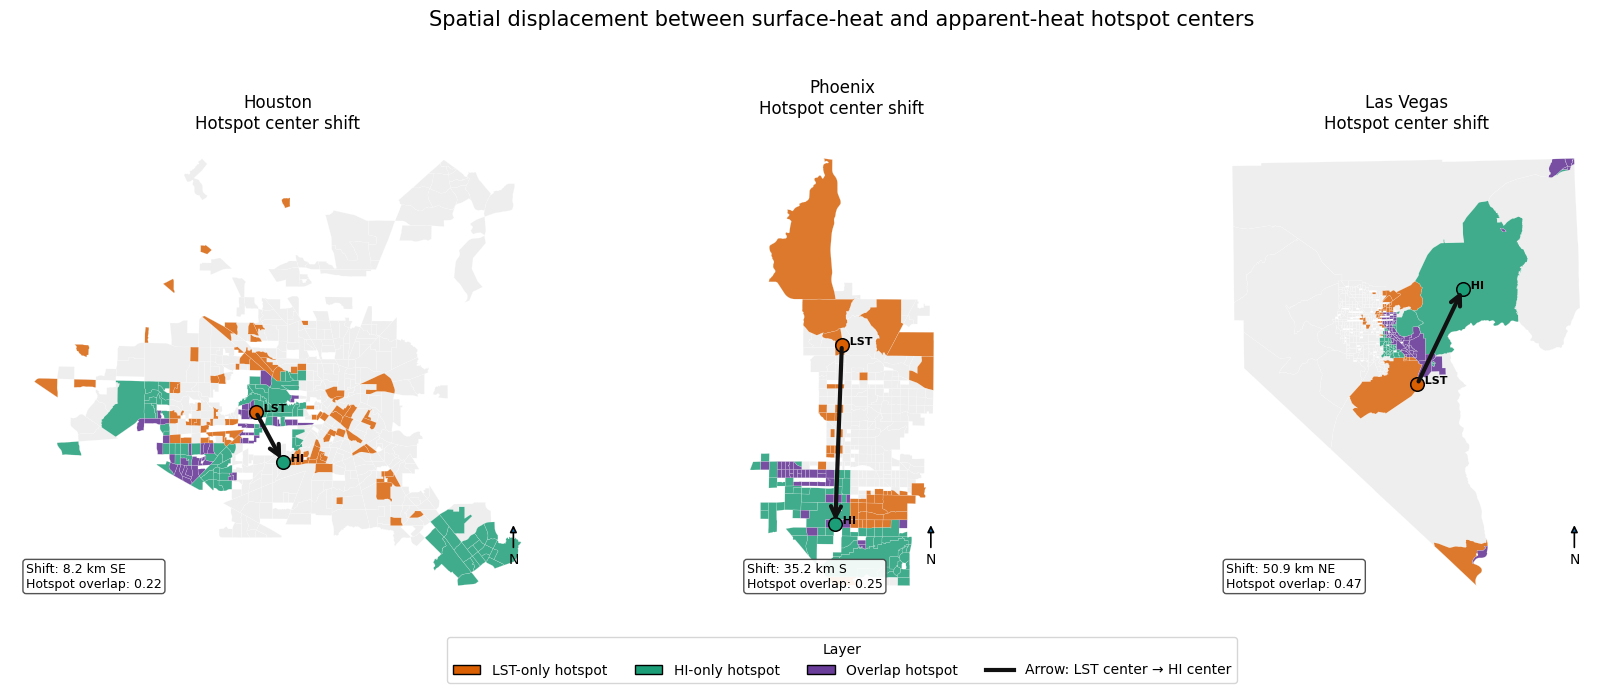

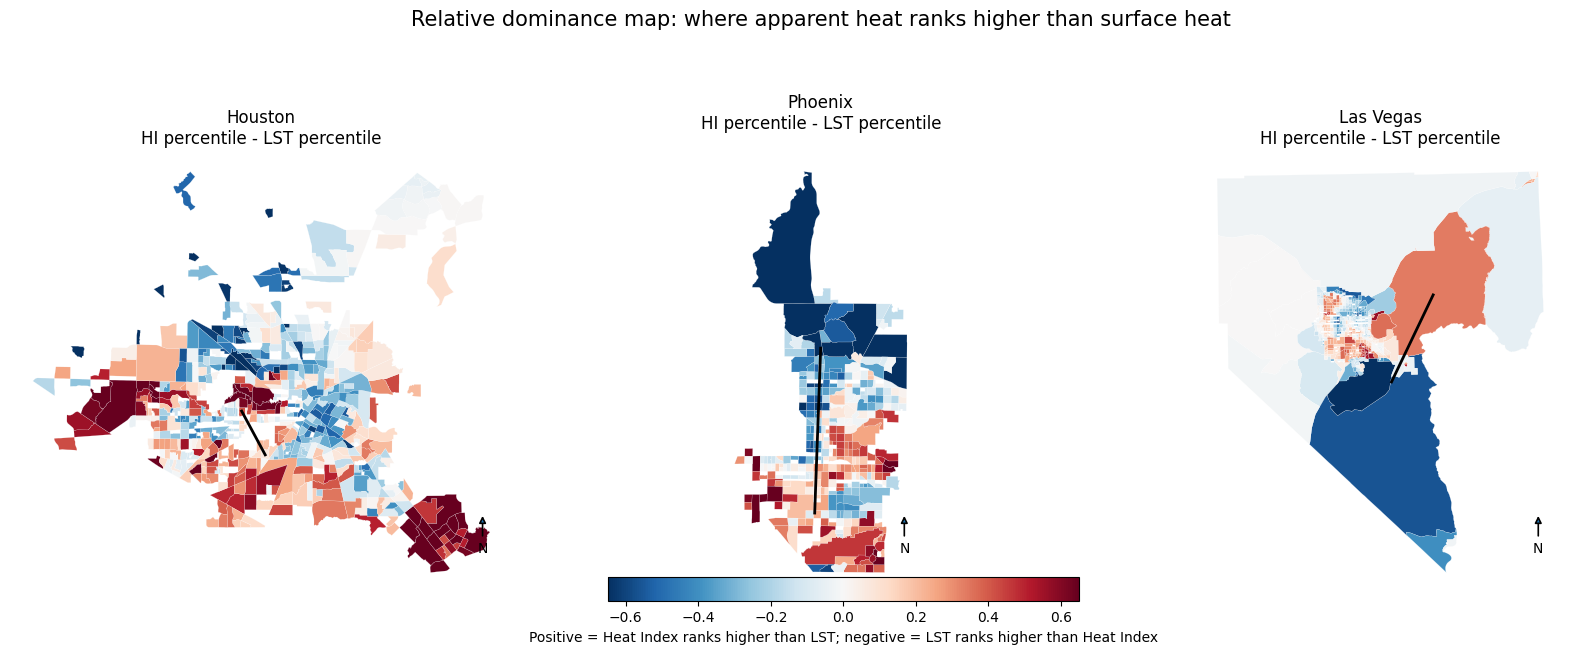

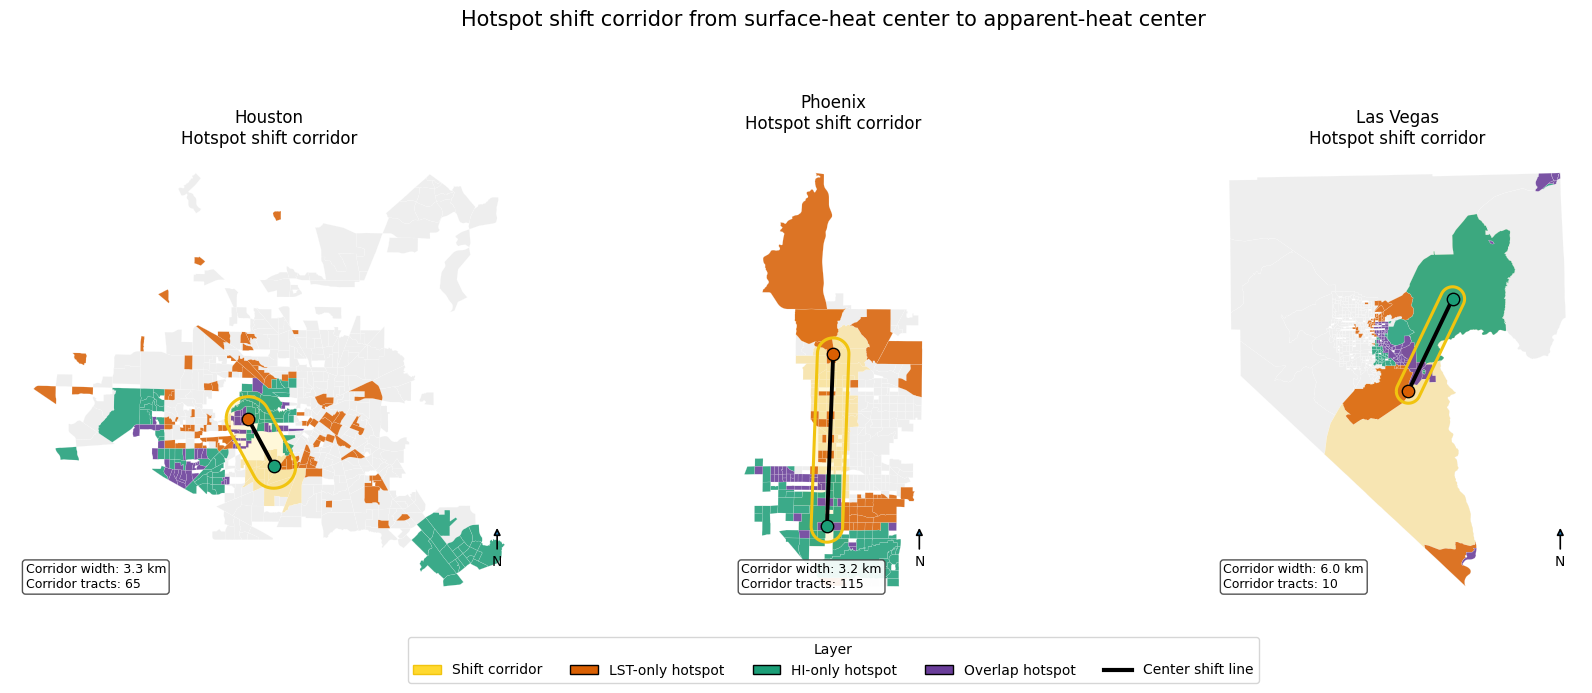

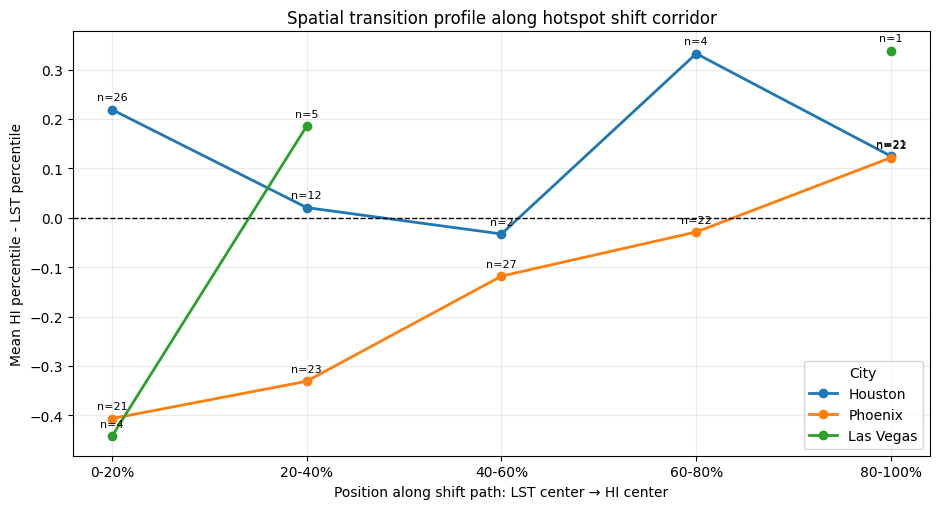


Interpretation notes:
- Houston: HI hotspot center shifts 8.2 km toward SE relative to LST hotspot center; Jaccard overlap = 0.22; corridor mean HI-LST percentile balance = 0.15.
- Phoenix: HI hotspot center shifts 35.2 km toward S relative to LST hotspot center; Jaccard overlap = 0.25; corridor mean HI-LST percentile balance = -0.15.
- Las Vegas: HI hotspot center shifts 50.9 km toward NE relative to LST hotspot center; Jaccard overlap = 0.47; corridor mean HI-LST percentile balance = -0.05.

Saved deeper hotspot shift outputs:
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/GIS_SHIFT_fig11B_hotspot_centroid_displacement_BOLD.png
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/GIS_SHIFT_fig11_hotspot_centroid_displacement.png
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/GIS_SHIFT_fig12_percentile_balance_maps.png
- outputs/pilot/alphaearth/paper_gis_hotspot_shift_figures/GIS_SHIFT_fig13_hotspot_shift_corridor_maps.png
- outputs/pilot/alphaearth/pap

In [55]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.geometry import Point, LineString
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# COMPLETE REPLACEMENT CELL
# POLISHED + DEEPER HOTSPOT SHIFT GIS FIGURES
#
# Outputs:
# 1. Stronger-color hotspot displacement map
# 2. HI-vs-LST percentile balance map
# 3. Hotspot shift corridor map
# 4. Shift-corridor profile figure
# ============================================================

PROJECT = Path("/Users/yufeizhou/Desktop/heat-exposure-compare")

ADV_GEOJSON = (
    PROJECT
    / "outputs"
    / "pilot"
    / "alphaearth"
    / "paper_gis_advanced_figures"
    / "three_city_GIS_ADVANCED.geojson"
)

OUTDIR = (
    PROJECT
    / "outputs"
    / "pilot"
    / "alphaearth"
    / "paper_gis_hotspot_shift_figures"
)
OUTDIR.mkdir(parents=True, exist_ok=True)

print("ADV_GEOJSON exists:", ADV_GEOJSON.exists())
print("OUTDIR:", OUTDIR)

if not ADV_GEOJSON.exists():
    raise FileNotFoundError("Cannot find three_city_GIS_ADVANCED.geojson. Run the advanced GIS cell first.")

gdf = gpd.read_file(ADV_GEOJSON)

city_order = ["houston", "phoenix", "las_vegas"]
city_display = {
    "houston": "Houston",
    "phoenix": "Phoenix",
    "las_vegas": "Las Vegas",
}

gdf["city"] = gdf["city"].astype(str).str.strip()
gdf = gdf[gdf["city"].isin(city_order)].copy()

for col in ["lst_c", "hi_c"]:
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")

def as_bool(x):
    if isinstance(x, bool):
        return x
    s = str(x).strip().lower()
    return s in ["true", "1", "yes", "t"]

if "priority_flag" in gdf.columns:
    gdf["priority_flag_bool"] = gdf["priority_flag"].map(as_bool)
else:
    gdf["priority_flag_bool"] = False

print("\nInput rows by city:")
display(gdf["city"].value_counts().rename_axis("city").reset_index(name="n"))

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def to_city_projected(g):
    g = g.copy()
    try:
        utm = g.estimate_utm_crs()
        if utm is not None:
            return g.to_crs(utm)
    except Exception:
        pass
    return g

def area_weighted_centroid(g):
    g = g.copy()
    areas = g.geometry.area.values
    centroids = g.geometry.centroid

    if len(g) == 0:
        return None

    if np.nansum(areas) == 0:
        x = centroids.x.mean()
        y = centroids.y.mean()
    else:
        x = np.average(centroids.x, weights=areas)
        y = np.average(centroids.y, weights=areas)

    return Point(x, y)

def compass_from_dxdy(dx, dy):
    angle = (np.degrees(np.arctan2(dx, dy)) + 360) % 360
    labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    idx = int((angle + 22.5) // 45) % 8
    return labels[idx], angle

def clean_map_axis(ax):
    ax.set_axis_off()
    ax.set_aspect("equal")

def add_north_arrow(ax, x=0.94, y=0.10):
    ax.annotate(
        "N",
        xy=(x, y + 0.08),
        xytext=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=10,
        arrowprops=dict(arrowstyle="-|>", lw=1.2),
    )

def add_city_label_box(ax, text):
    ax.text(
        0.03,
        0.035,
        text,
        transform=ax.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="#444444",
            alpha=0.92,
            boxstyle="round,pad=0.25"
        )
    )

# Stronger colors
COL_BASE = "#eeeeee"
COL_BORDER = "#ffffff"
COL_LST = "#d95f02"       # strong orange
COL_HI = "#1b9e77"        # strong green
COL_OVERLAP = "#6a3d9a"   # strong purple
COL_ARROW = "#111111"
COL_CORRIDOR = "#ffd92f"

# ------------------------------------------------------------
# Build city-level hotspot shift objects
# ------------------------------------------------------------
summary_rows = []
point_layers = []
line_layers = []
corridor_layers = []
shift_table_layers = []
profile_rows = []
plot_data = {}

for city in city_order:
    gg = gdf[gdf["city"] == city].copy()
    gg_proj = to_city_projected(gg)

    q75_lst = gg_proj["lst_c"].quantile(0.75)
    q75_hi = gg_proj["hi_c"].quantile(0.75)

    gg_proj["lst_hot_q75"] = gg_proj["lst_c"] >= q75_lst
    gg_proj["hi_hot_q75"] = gg_proj["hi_c"] >= q75_hi

    # Percentile balance: easier to explain than z-score
    gg_proj["lst_pct_city"] = gg_proj["lst_c"].rank(pct=True)
    gg_proj["hi_pct_city"] = gg_proj["hi_c"].rank(pct=True)
    gg_proj["hi_minus_lst_pct"] = gg_proj["hi_pct_city"] - gg_proj["lst_pct_city"]

    gg_proj["percentile_balance_class"] = pd.cut(
        gg_proj["hi_minus_lst_pct"],
        bins=[-1.01, -0.40, -0.20, 0.20, 0.40, 1.01],
        labels=[
            "Strong LST-dominant",
            "Moderate LST-dominant",
            "Balanced",
            "Moderate HI-dominant",
            "Strong HI-dominant",
        ],
        include_lowest=True
    )

    lst_hot = gg_proj[gg_proj["lst_hot_q75"]].copy()
    hi_hot = gg_proj[gg_proj["hi_hot_q75"]].copy()
    both_hot = gg_proj[gg_proj["lst_hot_q75"] & gg_proj["hi_hot_q75"]].copy()
    lst_only = gg_proj[gg_proj["lst_hot_q75"] & ~gg_proj["hi_hot_q75"]].copy()
    hi_only = gg_proj[~gg_proj["lst_hot_q75"] & gg_proj["hi_hot_q75"]].copy()

    lst_center = area_weighted_centroid(lst_hot)
    hi_center = area_weighted_centroid(hi_hot)

    if lst_center is None or hi_center is None:
        raise ValueError(f"{city}: cannot compute LST/HI hotspot centers.")

    dx = hi_center.x - lst_center.x
    dy = hi_center.y - lst_center.y
    distance_km = np.sqrt(dx**2 + dy**2) / 1000
    direction_label, direction_deg = compass_from_dxdy(dx, dy)

    union_n = int((gg_proj["lst_hot_q75"] | gg_proj["hi_hot_q75"]).sum())
    both_n = int((gg_proj["lst_hot_q75"] & gg_proj["hi_hot_q75"]).sum())
    jaccard = both_n / union_n if union_n > 0 else np.nan

    # Shift line and corridor
    shift_line = LineString([lst_center, hi_center])

    minx, miny, maxx, maxy = gg_proj.total_bounds
    diag_m = np.sqrt((maxx - minx) ** 2 + (maxy - miny) ** 2)
    corridor_width_m = max(1500, min(6000, diag_m * 0.035))
    corridor_geom = shift_line.buffer(corridor_width_m)

    centroids = gg_proj.geometry.centroid
    if shift_line.length > 0:
        gg_proj["corridor_position_0_to_1"] = [
            min(1, max(0, shift_line.project(pt) / shift_line.length))
            for pt in centroids
        ]
    else:
        gg_proj["corridor_position_0_to_1"] = np.nan

    gg_proj["distance_to_shift_line_km"] = [
        pt.distance(shift_line) / 1000
        for pt in centroids
    ]

    gg_proj["in_shift_corridor"] = gg_proj.geometry.intersects(corridor_geom)

    corridor_tracts = gg_proj[gg_proj["in_shift_corridor"]].copy()

    if len(corridor_tracts) > 0:
        bins = np.linspace(0, 1, 6)
        labels = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
        corridor_tracts["shift_path_bin"] = pd.cut(
            corridor_tracts["corridor_position_0_to_1"],
            bins=bins,
            labels=labels,
            include_lowest=True
        )

        profile = (
            corridor_tracts
            .groupby("shift_path_bin", observed=False)
            .agg(
                n=("GEOID", "count"),
                mean_hi_minus_lst_pct=("hi_minus_lst_pct", "mean"),
                median_hi_minus_lst_pct=("hi_minus_lst_pct", "median"),
                priority_pct=("priority_flag_bool", "mean"),
                mean_lst_c=("lst_c", "mean"),
                mean_hi_c=("hi_c", "mean")
            )
            .reset_index()
        )
        profile["city"] = city
        profile["priority_pct"] = profile["priority_pct"] * 100
        profile_rows.append(profile)

    summary_rows.append({
        "city": city,
        "n_tracts": len(gg_proj),
        "lst_hot_n": len(lst_hot),
        "hi_hot_n": len(hi_hot),
        "both_hot_n": both_n,
        "lst_only_n": len(lst_only),
        "hi_only_n": len(hi_only),
        "hotspot_union_n": union_n,
        "hotspot_jaccard_overlap": jaccard,
        "lst_hot_q75_threshold": q75_lst,
        "hi_hot_q75_threshold": q75_hi,
        "centroid_shift_distance_km": distance_km,
        "centroid_shift_direction": direction_label,
        "centroid_shift_direction_degrees_from_north": direction_deg,
        "corridor_width_km": corridor_width_m / 1000,
        "corridor_tract_n": len(corridor_tracts),
        "corridor_priority_pct": 100 * corridor_tracts["priority_flag_bool"].mean()
            if len(corridor_tracts) > 0 else np.nan,
        "corridor_mean_hi_minus_lst_pct": corridor_tracts["hi_minus_lst_pct"].mean()
            if len(corridor_tracts) > 0 else np.nan,
        "city_pct_strong_HI_dominant": 100 * (gg_proj["percentile_balance_class"].astype(str) == "Strong HI-dominant").mean(),
        "city_pct_strong_LST_dominant": 100 * (gg_proj["percentile_balance_class"].astype(str) == "Strong LST-dominant").mean(),
    })

    pts = gpd.GeoDataFrame(
        [
            {"city": city, "center_type": "LST hotspot center", "geometry": lst_center},
            {"city": city, "center_type": "HI hotspot center", "geometry": hi_center},
        ],
        geometry="geometry",
        crs=gg_proj.crs
    ).to_crs("EPSG:4326")

    line = gpd.GeoDataFrame(
        [
            {
                "city": city,
                "shift_type": "LST center to HI center",
                "distance_km": distance_km,
                "direction": direction_label,
                "geometry": shift_line
            }
        ],
        geometry="geometry",
        crs=gg_proj.crs
    ).to_crs("EPSG:4326")

    corridor = gpd.GeoDataFrame(
        [
            {
                "city": city,
                "corridor_width_km": corridor_width_m / 1000,
                "geometry": corridor_geom
            }
        ],
        geometry="geometry",
        crs=gg_proj.crs
    ).to_crs("EPSG:4326")

    point_layers.append(pts)
    line_layers.append(line)
    corridor_layers.append(corridor)

    shift_table_layers.append(gg_proj.to_crs("EPSG:4326"))

    plot_data[city] = {
        "g": gg_proj,
        "lst_hot": lst_hot,
        "hi_hot": hi_hot,
        "both_hot": both_hot,
        "lst_only": lst_only,
        "hi_only": hi_only,
        "lst_center": lst_center,
        "hi_center": hi_center,
        "shift_line": shift_line,
        "corridor_geom": corridor_geom,
        "distance_km": distance_km,
        "direction_label": direction_label,
        "jaccard": jaccard,
        "corridor_width_km": corridor_width_m / 1000,
    }

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTDIR / "hotspot_shift_deeper_summary.csv", index=False)

if len(profile_rows) > 0:
    corridor_profile = pd.concat(profile_rows, ignore_index=True)
else:
    corridor_profile = pd.DataFrame()

corridor_profile.to_csv(OUTDIR / "hotspot_shift_corridor_profile.csv", index=False)

points_all = gpd.GeoDataFrame(
    pd.concat(point_layers, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)
lines_all = gpd.GeoDataFrame(
    pd.concat(line_layers, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)
corridors_all = gpd.GeoDataFrame(
    pd.concat(corridor_layers, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)
shift_table_all = gpd.GeoDataFrame(
    pd.concat(shift_table_layers, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326"
)

points_all.to_file(OUTDIR / "hotspot_centroid_points_BOLD.geojson", driver="GeoJSON")
lines_all.to_file(OUTDIR / "hotspot_centroid_shift_lines_BOLD.geojson", driver="GeoJSON")
corridors_all.to_file(OUTDIR / "hotspot_shift_corridors.geojson", driver="GeoJSON")
shift_table_all.to_file(OUTDIR / "hotspot_shift_deeper_tracts.geojson", driver="GeoJSON")

gpkg_path = OUTDIR / "hotspot_shift_deeper_GIS_READY.gpkg"
points_all.to_file(gpkg_path, layer="centroid_points", driver="GPKG")
lines_all.to_file(gpkg_path, layer="shift_lines", driver="GPKG")
corridors_all.to_file(gpkg_path, layer="shift_corridors", driver="GPKG")
shift_table_all.to_file(gpkg_path, layer="tracts_with_shift_metrics", driver="GPKG")

print("\nDeeper hotspot shift summary:")
display(summary.round(3))

# ============================================================
# FIGURE 11B: stronger hotspot displacement map
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6.8))

for ax, city in zip(axes, city_order):
    d = plot_data[city]
    gg = d["g"]

    gg.plot(ax=ax, color=COL_BASE, edgecolor=COL_BORDER, linewidth=0.13)

    if len(d["lst_only"]) > 0:
        d["lst_only"].plot(ax=ax, color=COL_LST, alpha=0.82, edgecolor="white", linewidth=0.14)

    if len(d["hi_only"]) > 0:
        d["hi_only"].plot(ax=ax, color=COL_HI, alpha=0.82, edgecolor="white", linewidth=0.14)

    if len(d["both_hot"]) > 0:
        d["both_hot"].plot(ax=ax, color=COL_OVERLAP, alpha=0.90, edgecolor="white", linewidth=0.14)

    lst_center = d["lst_center"]
    hi_center = d["hi_center"]

    ax.scatter(
        lst_center.x,
        lst_center.y,
        s=95,
        color=COL_LST,
        edgecolor="black",
        linewidth=1.1,
        zorder=8
    )
    ax.scatter(
        hi_center.x,
        hi_center.y,
        s=95,
        color=COL_HI,
        edgecolor="black",
        linewidth=1.1,
        zorder=8
    )

    ax.annotate(
        "",
        xy=(hi_center.x, hi_center.y),
        xytext=(lst_center.x, lst_center.y),
        arrowprops=dict(
            arrowstyle="->",
            lw=3.0,
            color=COL_ARROW,
            mutation_scale=18
        ),
        zorder=9,
    )

    ax.text(lst_center.x, lst_center.y, "  LST", fontsize=8, weight="bold", zorder=10)
    ax.text(hi_center.x, hi_center.y, "  HI", fontsize=8, weight="bold", zorder=10)

    label_text = (
        f"Shift: {d['distance_km']:.1f} km {d['direction_label']}\n"
        f"Hotspot overlap: {d['jaccard']:.2f}"
    )
    add_city_label_box(ax, label_text)

    ax.set_title(f"{city_display[city]}\nHotspot center shift", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=COL_LST, edgecolor="black", label="LST-only hotspot"),
    Patch(facecolor=COL_HI, edgecolor="black", label="HI-only hotspot"),
    Patch(facecolor=COL_OVERLAP, edgecolor="black", label="Overlap hotspot"),
    Line2D([0], [0], color=COL_ARROW, lw=3, label="Arrow: LST center → HI center"),
]

fig.legend(
    handles=legend_handles,
    title="Layer",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Spatial displacement between surface-heat and apparent-heat hotspot centers",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig11b = OUTDIR / "GIS_SHIFT_fig11B_hotspot_centroid_displacement_BOLD.png"
fig.savefig(fig11b, dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 12: percentile balance map
# Positive = HI rank higher than LST rank within same city
# ============================================================
vmax = 0.65

fig, axes = plt.subplots(1, 3, figsize=(18, 6.8))

for ax, city in zip(axes, city_order):
    gg = plot_data[city]["g"].copy()

    gg.plot(
        ax=ax,
        column="hi_minus_lst_pct",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        edgecolor="white",
        linewidth=0.12,
        legend=False
    )

    line = gpd.GeoDataFrame(
        [{"geometry": plot_data[city]["shift_line"]}],
        geometry="geometry",
        crs=gg.crs
    )
    line.plot(ax=ax, color="black", linewidth=2.0)

    ax.set_title(f"{city_display[city]}\nHI percentile - LST percentile", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045, pad=0.08)
cbar.set_label(
    "Positive = Heat Index ranks higher than LST; negative = LST ranks higher than Heat Index"
)

fig.suptitle(
    "Relative dominance map: where apparent heat ranks higher than surface heat",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.10, 1, 0.93])

fig12 = OUTDIR / "GIS_SHIFT_fig12_percentile_balance_maps.png"
fig.savefig(fig12, dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 13: shift corridor map
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6.8))

for ax, city in zip(axes, city_order):
    d = plot_data[city]
    gg = d["g"]

    gg.plot(ax=ax, color=COL_BASE, edgecolor="white", linewidth=0.11)

    corridor_gdf = gpd.GeoDataFrame(
        [{"geometry": d["corridor_geom"]}],
        geometry="geometry",
        crs=gg.crs
    )

    corridor_gdf.plot(ax=ax, color=COL_CORRIDOR, alpha=0.18, edgecolor=None)
    corridor_gdf.boundary.plot(ax=ax, color="#f1c40f", linewidth=2.2)

    corridor_tracts = gg[gg["in_shift_corridor"]].copy()

    if len(corridor_tracts) > 0:
        corridor_tracts.plot(
            ax=ax,
            color="#fee08b",
            alpha=0.60,
            edgecolor="white",
            linewidth=0.10
        )

    if len(d["lst_only"]) > 0:
        d["lst_only"].plot(ax=ax, color=COL_LST, alpha=0.85, edgecolor="white", linewidth=0.12)

    if len(d["hi_only"]) > 0:
        d["hi_only"].plot(ax=ax, color=COL_HI, alpha=0.85, edgecolor="white", linewidth=0.12)

    if len(d["both_hot"]) > 0:
        d["both_hot"].plot(ax=ax, color=COL_OVERLAP, alpha=0.88, edgecolor="white", linewidth=0.12)

    line = gpd.GeoDataFrame(
        [{"geometry": d["shift_line"]}],
        geometry="geometry",
        crs=gg.crs
    )
    line.plot(ax=ax, color="black", linewidth=2.8)

    ax.scatter(d["lst_center"].x, d["lst_center"].y, s=80, color=COL_LST, edgecolor="black", zorder=8)
    ax.scatter(d["hi_center"].x, d["hi_center"].y, s=80, color=COL_HI, edgecolor="black", zorder=8)

    label_text = (
        f"Corridor width: {d['corridor_width_km']:.1f} km\n"
        f"Corridor tracts: {len(corridor_tracts)}"
    )
    add_city_label_box(ax, label_text)

    ax.set_title(f"{city_display[city]}\nHotspot shift corridor", fontsize=12)
    add_north_arrow(ax)
    clean_map_axis(ax)

legend_handles = [
    Patch(facecolor=COL_CORRIDOR, edgecolor="#f1c40f", label="Shift corridor"),
    Patch(facecolor=COL_LST, edgecolor="black", label="LST-only hotspot"),
    Patch(facecolor=COL_HI, edgecolor="black", label="HI-only hotspot"),
    Patch(facecolor=COL_OVERLAP, edgecolor="black", label="Overlap hotspot"),
    Line2D([0], [0], color="black", lw=3, label="Center shift line"),
]

fig.legend(
    handles=legend_handles,
    title="Layer",
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Hotspot shift corridor from surface-heat center to apparent-heat center",
    fontsize=15,
    y=0.98
)

fig.tight_layout(rect=[0, 0.08, 1, 0.93])

fig13 = OUTDIR / "GIS_SHIFT_fig13_hotspot_shift_corridor_maps.png"
fig.savefig(fig13, dpi=400, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 14: shift-corridor spatial profile
# This summarizes how HI-vs-LST dominance changes along the
# LST-center-to-HI-center pathway.
# ============================================================
if len(corridor_profile) > 0:
    fig, ax = plt.subplots(figsize=(9.5, 5.2))

    bin_order = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]

    for city in city_order:
        sub = corridor_profile[corridor_profile["city"] == city].copy()
        sub["shift_path_bin"] = pd.Categorical(
            sub["shift_path_bin"].astype(str),
            categories=bin_order,
            ordered=True
        )
        sub = sub.sort_values("shift_path_bin")

        ax.plot(
            sub["shift_path_bin"].astype(str),
            sub["mean_hi_minus_lst_pct"],
            marker="o",
            linewidth=2,
            label=city_display[city]
        )

        for i, r in sub.reset_index(drop=True).iterrows():
            if pd.notna(r["n"]):
                ax.text(
                    i,
                    r["mean_hi_minus_lst_pct"] + 0.015,
                    f"n={int(r['n'])}",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel("Mean HI percentile - LST percentile")
    ax.set_xlabel("Position along shift path: LST center → HI center")
    ax.set_title("Spatial transition profile along hotspot shift corridor")
    ax.grid(alpha=0.25)
    ax.legend(title="City")

    fig.tight_layout()

    fig14 = OUTDIR / "GIS_SHIFT_fig14_shift_corridor_profile.png"
    fig.savefig(fig14, dpi=400, bbox_inches="tight")
    plt.show()
else:
    print("WARNING: corridor_profile is empty, so Figure 14 was skipped.")

# ------------------------------------------------------------
# Interpretation notes
# ------------------------------------------------------------
notes = []

for _, r in summary.iterrows():
    notes.append(
        f"{city_display[r['city']]}: HI hotspot center shifts {r['centroid_shift_distance_km']:.1f} km "
        f"toward {r['centroid_shift_direction']} relative to LST hotspot center; "
        f"Jaccard overlap = {r['hotspot_jaccard_overlap']:.2f}; "
        f"corridor mean HI-LST percentile balance = {r['corridor_mean_hi_minus_lst_pct']:.2f}."
    )

with open(OUTDIR / "hotspot_shift_deeper_interpretation_notes.txt", "w") as f:
    for note in notes:
        f.write("- " + note + "\n")

print("\nInterpretation notes:")
for note in notes:
    print("- " + note)

print("\nSaved deeper hotspot shift outputs:")
for p in sorted(OUTDIR.glob("*")):
    print("-", p.relative_to(PROJECT))

print("\nDONE: polished hotspot shift maps generated.")